In [1]:
!pip install git+https://github.com/fra31/auto-attack.git

  Cloning https://github.com/fra31/auto-attack.git to /tmp/pip-req-build-v0y8zn07
  Running command git clone --filter=blob:none --quiet https://github.com/fra31/auto-attack.git /tmp/pip-req-build-v0y8zn07
  Resolved https://github.com/fra31/auto-attack.git to commit a39220048b3c9f2cca9a4d3a54604793c68eca7e
  Preparing metadata (setup.py) ... done
  Created wheel for autoattack: filename=autoattack-0.1-py3-none-any.whl size=36228 sha256=ddec317015c0848674f4df90ed6ca6cd42d2b4afa99340a9601c849712bf64ba
  Stored in directory: /tmp/pip-ephem-wheel-cache-o0cl_ahe/wheels/b1/fb/ae/154d958c21cae288884bb0c84b5c65d338c71daf8782c7cd2a
Successfully built autoattack


In [2]:
!pip install mamba-ssm --no-build-isolation
!pip install torchvision tqdm datasets transformers scikit-learn
!pip install torchattacks -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.4/216.4 kB 4.5 MB/s eta 0:00:0000:01
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 MB 44.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 67.3 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.7/327.7 kB 20.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 71.9 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.5/74.5 MB 24.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29.3/29.3 MB 55.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.8/897.8 kB 45.0 MB/s eta 0:00:00
  Created wheel for mamba-ssm: filename=mamba_ssm-2.3.2.post1-cp312-cp312-linux_x86_64.whl size=322288410 sha256=7a67070c1e7e99c95abd1319623f044e8a1b3fb46f774bfdea949f0a4fc79638
  Stored in directory: /root/.cache/pip/wheels/da/67/03/99148d6eeaa4ec2855d71295ac83b

In [3]:
import os
os.environ['CUDA_LAUNCH_BLOCKING'] = "1"
import torch

In [4]:
import os
import random
from pathlib import Path
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
import gc

from datasets import load_dataset
from dataclasses import dataclass

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, Subset, random_split
from torchvision import datasets, transforms
import torchaudio
import torch.nn.functional as F
from typing import Optional, Union
import torchattacks

from transformers import AutoTokenizer
from mamba_ssm import Mamba

from sklearn.metrics import accuracy_score

def seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


seed_everything(42)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

device: cuda


 # Config датасета и параметров обучения

# Датасеты и DataLoader

In [5]:
@dataclass
class DatasetConfig:
    name: str
    input_type: str
    num_classes: int
    batch_size: int
    max_len: int | None=None
    vocab_size: int | None = None
    pad_token_id: int = 0
    checkpoint_path: str = "best_model.pt"
    continuous_input_dim: int = 1 

@dataclass
class TrainConfig:
    epochs: int = 7
    lr: float = 1e-3
    d_model: int = 128
    n_layers: int = 3
    dropout: float = 0.1
    patience: int = 2
    min_delta: float = 1e-3
    num_workers: int = 0
    use_subset: bool = False
    train_subset_size: int = 5000
    test_subset_size: int = 2000
    val_split: float = 0.2
    
    n_filters: int = 100
    filter_sizes: tuple = (3, 4, 5)
    
    nhead: int = 8
    dim_feedforward: int = 512

    delta_clip: bool = False

@dataclass
class AttackConfig:
    attack_type: str = "pgd"
    adv_steps: int = 3
    adv_lr: float = 1e-2
    adv_eps: float = 1e-1
    adv_alpha: float = 0.5
    patch_size: float = 0.3
    two_stage: bool = False
    sa_at_lambda: float = 0.0

DATASET_NAME = "imdb"
train_cfg = TrainConfig(epochs=7, lr=1e-3, d_model=128, n_layers=3, patience=2, num_workers=0)
atk_cfg = AttackConfig(attack_type="pgd")

In [6]:
class TextClassificationDataset(Dataset):
    def __init__(self, hf_split, tokenizer, text_col: str, label_col: str, max_len: int):
        self.data = hf_split
        self.tokenizer = tokenizer
        self.text_col = text_col
        self.label_col = label_col
        self.max_len = max_len

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        enc = self.tokenizer(
            item[self.text_col],
            padding="max_length",
            truncation=True,
            max_length=self.max_len,
            return_tensors="pt",
        )
        input_ids = enc["input_ids"].squeeze(0).long()
        label = torch.tensor(item[self.label_col], dtype=torch.long)
        return input_ids, label

class SpeechDataset(Dataset):
    def __init__(self, ds, label_map):
        self.ds = ds
        self.label_map = label_map

    def __len__(self): return len(self.ds)

    def __getitem__(self, idx):
        waveform, sample_rate, label, *_ = self.ds[idx]
        if waveform.size(1) > 16000: waveform = waveform[:, :16000]
        else: waveform = torch.nn.functional.pad(waveform, (0, 16000 - waveform.size(1)))
        
        seq = waveform.reshape(-1)[:16000].reshape(100, 160)
        return seq, torch.tensor(self.label_map[label])

def maybe_subset(dataset, size: int | None):
    if size is None or size >= len(dataset):
        return dataset
    return Subset(dataset, range(size))


DATA_ROOT = '/kaggle/working/data' if os.path.exists('/kaggle/working') else './data'
os.makedirs(DATA_ROOT, exist_ok=True)

def build_dataloaders(dataset_name: str, train_cfg: TrainConfig):
    dataset_name = dataset_name.lower()
    tokenizer = None

    if dataset_name == "mnist":
        transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.5,), (0.5,)),
            transforms.Lambda(lambda t: t.view(-1).reshape(49, 16))
        ])
        train_dataset = datasets.MNIST(root=DATA_ROOT, train=True, download=True, transform=transform)
        test_dataset = datasets.MNIST(root=DATA_ROOT, train=False, download=True, transform=transform)
        ds_cfg = DatasetConfig(
            name="mnist",
            input_type="continuous",
            num_classes=10,
            batch_size=128,
            max_len=49,
            continuous_input_dim=16,
            checkpoint_path="best_model_mnist.pt",
        )

    elif dataset_name == "smnist":
        transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.1307,), (0.3081,)),
            transforms.Lambda(lambda x: x.view(-1, 1))
        ])
        train_dataset = datasets.MNIST(root=DATA_ROOT, train=True, download=True, transform=transform)
        test_dataset = datasets.MNIST(root=DATA_ROOT, train=False, download=True, transform=transform)
        ds_cfg = DatasetConfig(
            name="smnist",
            input_type="continuous",
            num_classes=10,
            batch_size=128,
            max_len=784,
            checkpoint_path="best_model_smnist.pt",
        )

    elif dataset_name == "imdb":
        raw = load_dataset("imdb")
        tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
        train_dataset = TextClassificationDataset(raw["train"], tokenizer, "text", "label", max_len=256)
        test_dataset = TextClassificationDataset(raw["test"], tokenizer, "text", "label", max_len=256)
        ds_cfg = DatasetConfig(
            name="imdb",
            input_type="tokens",
            num_classes=2,
            batch_size=32,
            max_len=256,
            vocab_size=tokenizer.vocab_size,
            pad_token_id=tokenizer.pad_token_id or 0,
            checkpoint_path="best_model_imdb.pt",
        )

    elif dataset_name == "cifar10":
        transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
            transforms.Lambda(lambda t: t.reshape(-1).reshape(64, 48)), 
        ])
        train_dataset = datasets.CIFAR10(root=DATA_ROOT, train=True, download=True, transform=transform)
        test_dataset = datasets.CIFAR10(root=DATA_ROOT, train=False, download=True, transform=transform)
        ds_cfg = DatasetConfig(
            name="cifar10",
            input_type="continuous",
            num_classes=10,
            batch_size=32,
            max_len=64,            
            continuous_input_dim=48, 
            checkpoint_path="best_model_cifar10.pt",
        )

    elif dataset_name == "speech_commands":
        train_dataset = torchaudio.datasets.SPEECHCOMMANDS(root=DATA_ROOT, download=True, subset='training')
        test_dataset = torchaudio.datasets.SPEECHCOMMANDS(root=DATA_ROOT, download=True, subset='testing')

        sc_root = Path(DATA_ROOT) / "SpeechCommands" / "speech_commands_v0.02"
        labels = sorted([d.name for d in sc_root.iterdir()
                         if d.is_dir() and not d.name.startswith('_')])
        label_map = {l: i for i, l in enumerate(labels)}
            
        train_dataset = SpeechDataset(train_dataset, label_map)
        test_dataset = SpeechDataset(test_dataset, label_map)
        
        ds_cfg = DatasetConfig(
            name="speech_commands",
            input_type="continuous",
            num_classes=35,
            batch_size=64,
            max_len=100,          
            continuous_input_dim=160,   
            checkpoint_path="best_model_speech.pt",
        )

    elif dataset_name == "ag_news":
        raw = load_dataset("ag_news")
        tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
        train_dataset = TextClassificationDataset(raw["train"], tokenizer, "text", "label", max_len=128)
        test_dataset = TextClassificationDataset(raw["test"], tokenizer, "text", "label", max_len=128)
        ds_cfg = DatasetConfig(
            name="ag_news",
            input_type="tokens",
            num_classes=4,
            batch_size=64,
            max_len=128,
            vocab_size=tokenizer.vocab_size,
            pad_token_id=tokenizer.pad_token_id or 0,
            checkpoint_path="best_model_ag_news.pt",
        )

    else:
        raise ValueError(f"Unknown dataset_name={dataset_name}. Use: mnist, imdb, ag_news")

    if train_cfg.use_subset:
        train_dataset = maybe_subset(train_dataset, train_cfg.train_subset_size)
        test_dataset = maybe_subset(test_dataset, train_cfg.test_subset_size)

    val_size = int(len(train_dataset) * train_cfg.val_split)
    train_size = len(train_dataset) - val_size

    train_dataset, eval_dataset = random_split(
        train_dataset, 
        [train_size, val_size],
        generator=torch.Generator().manual_seed(42) 
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=ds_cfg.batch_size,
        shuffle=True,
        num_workers=train_cfg.num_workers,
        persistent_workers=False,
        pin_memory=torch.cuda.is_available(),
    )

    eval_loader = DataLoader(
        eval_dataset, 
        batch_size=ds_cfg.batch_size, 
        shuffle=False, 
        num_workers=train_cfg.num_workers,
        persistent_workers=False,
        pin_memory=torch.cuda.is_available()
    )
    
    test_loader = DataLoader(
        test_dataset,
        batch_size=ds_cfg.batch_size,
        shuffle=False,
        num_workers=train_cfg.num_workers,
        persistent_workers=False,
        pin_memory=torch.cuda.is_available(),
    )
    return train_loader, eval_loader, test_loader, ds_cfg, tokenizer


train_loader, eval_loader, test_loader, ds_cfg, tokenizer = build_dataloaders(DATASET_NAME, train_cfg)
print(ds_cfg)

README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

...

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

DatasetConfig(name='imdb', input_type='tokens', num_classes=2, batch_size=32, max_len=256, vocab_size=30522, pad_token_id=0, checkpoint_path='best_model_imdb.pt', continuous_input_dim=1)


# Универсальная Mamba-модель

In [7]:
class MambaBlock(nn.Module):
    def __init__(self, d_model: int, dropout: float = 0.1):
        super().__init__()
        self.ssm = Mamba(d_model=d_model)
        self.layer_norm = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        residual = x
        x = self.ssm(x)
        x = self.dropout(x)
        return self.layer_norm(x + residual)



In [8]:
class UniversalMambaClassifier(nn.Module):
    """
    Модифицированная Mamba с защитой:
    - use_gating_filter: отсекает резкие аномалии (Sliding Patch)
    - inference_noise_std: добавляет шум при инференсе, сбивая атаки
    """
    def __init__(
        self,
        input_type: str, 
        num_classes: int,
        d_model: int = 128, 
        n_layers: int = 3,
        dropout: float = 0.1,
        vocab_size: int | None = None,
        continuous_input_dim: int = 1,
        pad_token_id: int = 0,
        pooling: str = "mean",
        use_gating_filter: bool = True,
        inference_noise_std: float = 0.05
    ):
        super().__init__()
        self.input_type = input_type
        self.pooling = pooling
        self.pad_token_id = pad_token_id
        self.inference_noise_std = inference_noise_std
        self.use_gating_filter = use_gating_filter

        if input_type == "tokens":
            if vocab_size is None:
                raise ValueError("vocab_size is required for input_type='tokens'")
            self.input_layer = nn.Embedding(vocab_size, d_model, padding_idx=pad_token_id)
        elif input_type == "continuous":
            self.input_layer = nn.Linear(continuous_input_dim, d_model)
            
        if self.use_gating_filter:
            self.pre_filter = nn.Conv1d(d_model, d_model, kernel_size=3, padding=1, groups=d_model)

        self.blocks = nn.ModuleList([MambaBlock(d_model, dropout) for _ in range(n_layers)])
        self.norm = nn.LayerNorm(d_model)
        self.classifier = nn.Linear(d_model, num_classes)

    def _prepare_continuous(self, x):
        if x.dim() == 4:
            x = x.view(x.size(0), -1, 1)
        elif x.dim() == 2:
            x = x.unsqueeze(-1)
        return x.float()

    def get_embeddings(self, x):
        if self.input_type == "tokens":
            max_idx = x.max().item()
            if max_idx >= self.input_layer.num_embeddings:
                print(f"!!! ОШИБКА: Обнаружен токен {max_idx}, при vocab_size={self.input_layer.num_embeddings}")
            emb = self.input_layer(x.long())
        else:
            emb = self.input_layer(self._prepare_continuous(x))
            
        if not self.training and self.inference_noise_std > 0:
            noise = torch.randn_like(emb) * self.inference_noise_std
            emb = emb + noise
            
        return emb

    def _pool(self, x, input_ids=None):
        if self.pooling == "last":
            return x[:, -1]
        if self.input_type == "tokens" and input_ids is not None:
            mask = (input_ids != self.pad_token_id).unsqueeze(-1).float()
            return (x * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1.0)
        return x.mean(dim=1)

    def forward_from_embeddings(self, embeddings, input_ids=None, return_hidden=False):
        x = embeddings
        
        if self.use_gating_filter:
            x = x.transpose(1, 2)
            x = F.relu(self.pre_filter(x))
            x = x.transpose(1, 2)

        for block in self.blocks:
            x = block(x)
            
        hidden_states = self.norm(x)
        
        if return_hidden:
            return hidden_states

        return self.classifier(self._pool(hidden_states, input_ids=input_ids))

    def forward(self, x, return_hidden=False):
        input_ids = x if self.input_type == "tokens" else None
        embeddings = self.get_embeddings(x)
        return self.forward_from_embeddings(embeddings, input_ids=input_ids, return_hidden=return_hidden)

# CNN Модель

In [9]:
class UniversalCNNClassifier(nn.Module):
    def __init__(
        self,
        input_type: str,
        num_classes: int,
        d_model: int = 128,
        vocab_size: int | None = None,
        continuous_input_dim: int = 1,
        filter_sizes: tuple = (3, 4, 5),
        pad_token_id: int = 0,
        use_gating_filter: bool = True,
        inference_noise_std: float = 0.05
    ):
        super().__init__()
        self.input_type = input_type
        self.pad_token_id = pad_token_id
        self.inference_noise_std = inference_noise_std
        self.use_gating_filter = use_gating_filter

        if input_type == "tokens":
            self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=pad_token_id)
        else:
            self.embedding = nn.Linear(continuous_input_dim, d_model)

        if self.use_gating_filter:
            self.pre_filter = nn.Conv1d(d_model, d_model, kernel_size=3, padding=1, groups=d_model)

        self.convs = nn.ModuleList([
            nn.Conv1d(in_channels=d_model, out_channels=d_model, kernel_size=fs)
            for fs in filter_sizes
        ])
        self.classifier = nn.Linear(len(filter_sizes) * d_model, num_classes)
        self.dropout = nn.Dropout(0.1)

    def get_embeddings(self, x):
        if self.input_type == "tokens":
            emb = self.embedding(x.long())
        else:
            if x.dim() == 4: x = x.view(x.size(0), -1, 1)
            elif x.dim() == 2: x = x.unsqueeze(-1)
            emb = self.embedding(x.float())
            
        if not self.training and self.inference_noise_std > 0:
            emb = emb + torch.randn_like(emb) * self.inference_noise_std
        return emb

    def forward_from_embeddings(self, embeddings, input_ids=None):
        x = embeddings
        if self.use_gating_filter:
            x = x.transpose(1, 2)
            x = F.relu(self.pre_filter(x))
            x = x.transpose(1, 2)
            
        x = x.transpose(1, 2) 
        conved = []
        for conv in self.convs:
            c = torch.relu(conv(x))
            c = torch.max(c, dim=2)[0]
            conved.append(c)
        x = torch.cat(conved, dim=1)
        x = self.dropout(x)
        return self.classifier(x)

    def forward(self, x):
        return self.forward_from_embeddings(self.get_embeddings(x))


# Transformer

In [ ]:
class UniversalTransformerClassifier(nn.Module):
    def __init__(
        self,
        input_type: str,
        num_classes: int,
        d_model: int = 128,
        n_layers: int = 3,
        nhead: int = 8,
        dim_feedforward: int = 512,
        dropout: float = 0.1,
        vocab_size: int | None = None,
        continuous_input_dim: int = 1,
        pad_token_id: int = 0,
        pooling: str = "mean",
        use_gating_filter: bool = True,
        inference_noise_std: float = 0.05
    ):
        super().__init__()
        self.input_type = input_type
        self.pooling = pooling
        self.pad_token_id = pad_token_id
        self.inference_noise_std = inference_noise_std
        self.use_gating_filter = use_gating_filter

        if input_type == "tokens":
            self.input_layer = nn.Embedding(vocab_size, d_model, padding_idx=pad_token_id)
        else:
            self.input_layer = nn.Linear(continuous_input_dim, d_model)

        if self.use_gating_filter:
            self.pre_filter = nn.Conv1d(d_model, d_model, kernel_size=3, padding=1, groups=d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=dim_feedforward, 
            dropout=dropout, batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)

        self.max_pos = 1024
        self.pos_embedding = nn.Parameter(torch.zeros(1, self.max_pos, d_model))
        nn.init.trunc_normal_(self.pos_embedding, std=0.02)

        self.classifier = nn.Linear(d_model, num_classes)

    def get_embeddings(self, x):
        if self.input_type == "tokens":
            emb = self.input_layer(x.long())
        else:
            if x.dim() == 4: x = x.view(x.size(0), -1, 1)
            elif x.dim() == 2: x = x.unsqueeze(-1)
            emb = self.input_layer(x.float())
            
        if not self.training and self.inference_noise_std > 0:
            emb = emb + torch.randn_like(emb) * self.inference_noise_std
        return emb

    def forward_from_embeddings(self, embeddings, input_ids=None):
        x = embeddings
        if self.use_gating_filter:
            x = x.transpose(1, 2)
            x = F.relu(self.pre_filter(x))
            x = x.transpose(1, 2)

        seq_len = x.size(1)
        x = x + self.pos_embedding[:, :seq_len, :]

        src_key_padding_mask = (input_ids == self.pad_token_id) if (self.input_type == "tokens" and input_ids is not None) else None
        x = self.transformer(x, src_key_padding_mask=src_key_padding_mask)
        
        if self.pooling == "mean":
            mask = (~src_key_padding_mask).unsqueeze(-1).float() if src_key_padding_mask is not None else None
            x = (x * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1.0) if mask is not None else x.mean(dim=1)
        else:
            x = x[:, -1]
        return self.classifier(x)

    def forward(self, x):
        return self.forward_from_embeddings(self.get_embeddings(x), input_ids=x if self.input_type == "tokens" else None)

# Функция-интерфейс для создания моделей

In [ ]:
def build_model(ds_cfg: DatasetConfig, train_cfg: TrainConfig, model_type: str = "mamba", use_defense: bool = False):
    common_params = {
        "input_type": ds_cfg.input_type,
        "num_classes": ds_cfg.num_classes,
        "d_model": train_cfg.d_model,
        "vocab_size": ds_cfg.vocab_size,
        "pad_token_id": ds_cfg.pad_token_id,
        "use_gating_filter": use_defense,
        "inference_noise_std": 0.05 if use_defense else 0.0,
        "continuous_input_dim": getattr(ds_cfg, "continuous_input_dim", 1),
    }
    
    if model_type == "mamba":
        return UniversalMambaClassifier(**common_params, n_layers=train_cfg.n_layers)
    elif model_type == "transformer":
        return UniversalTransformerClassifier(**common_params, n_layers=train_cfg.n_layers, 
                                            nhead=train_cfg.nhead, dim_feedforward=train_cfg.dim_feedforward)
    elif model_type == "cnn":
        return UniversalCNNClassifier(**common_params, filter_sizes=train_cfg.filter_sizes)
    
    raise ValueError(f"Unknown model type: {model_type}")

# Условие раннего останова

In [ ]:
class EarlyStopping:
    def __init__(self, patience: int = 2, min_delta: float = 0.0, mode: str = "max"):
        self.patience = patience
        self.min_delta = min_delta
        self.mode = mode
        self.best_score = -np.inf if mode == "max" else np.inf
        self.counter = 0
        self.should_stop = False

    def is_improvement(self, score: float) -> bool:
        if self.mode == "max":
            return score > self.best_score + self.min_delta
        return score < self.best_score - self.min_delta

    def step(self, score: float) -> bool:
        if self.is_improvement(score):
            self.best_score = score
            self.counter = 0
            return True
        self.counter += 1
        if self.counter >= self.patience:
            self.should_stop = True
        return False


def save_checkpoint(path, model, optimizer, epoch, history, ds_cfg, train_cfg,
                    atk_cfg=None,
                    clean_test_acc=None, clean_test_loss=None,
                    adv_test_acc=None,  adv_test_loss=None,
                    training_time_sec=None, model_type=None):
    """
    Расширенный checkpoint

    Структура checkpoint['training_summary']:
        model_type           : str   — "mamba" / "cnn" / "transformer"
        dataset              : str   — имя датасета
        best_epoch           : int
        best_val_acc         : float
        final_train_loss     : float
        final_val_loss       : float
        final_val_acc        : float
        clean_test_acc/loss  : float | None   — результат evaluate() после обучения
        adv_test_acc/loss    : float | None   — результат evaluate_adversarial()
        robustness_gap       : float | None   — clean_test_acc - adv_test_acc
        training_time_sec    : float | None   — суммарное время обучения
        attack_config        : dict  | None   — параметры атаки при adversarial-обучении
        n_params             : int            — число параметров модели
    """
    import time as _time

    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

    robustness_gap = None
    if clean_test_acc is not None and adv_test_acc is not None:
        robustness_gap = round(clean_test_acc - adv_test_acc, 6)

    training_summary = {
        "model_type":         model_type,
        "dataset":            ds_cfg.name,
        "num_classes":        ds_cfg.num_classes,
        "best_epoch":         epoch,
        "best_val_acc":       float(max(history["val_acc"])) if history["val_acc"] else None,
        "final_train_loss":   float(history["train_loss"][-1]) if history["train_loss"] else None,
        "final_val_loss":     float(history["val_loss"][-1])   if history["val_loss"]   else None,
        "final_val_acc":      float(history["val_acc"][-1])    if history["val_acc"]    else None,
        "clean_test_acc":     float(clean_test_acc)  if clean_test_acc  is not None else None,
        "clean_test_loss":    float(clean_test_loss) if clean_test_loss is not None else None,
        "adv_test_acc":       float(adv_test_acc)    if adv_test_acc    is not None else None,
        "adv_test_loss":      float(adv_test_loss)   if adv_test_loss   is not None else None,
        "robustness_gap":     robustness_gap,
        "training_time_sec":  round(training_time_sec, 2) if training_time_sec is not None else None,
        "n_params":           n_params,
        "attack_config":      atk_cfg.__dict__ if atk_cfg is not None else None,
        "saved_at":           _time.strftime("%Y-%m-%d %H:%M:%S"),
    }

    torch.save({
        "model_state_dict":      model.state_dict(),
        "optimizer_state_dict":  optimizer.state_dict(),
        "epoch":                 epoch,
        "history":               history,
        "training_summary":      training_summary,
        "dataset_config":        ds_cfg.__dict__,
        "train_config":          train_cfg.__dict__,
    }, path)
    return training_summary


def load_best_model(path, model, device):
    checkpoint = torch.load(path, map_location=device)
    model.load_state_dict(checkpoint["model_state_dict"])
    return checkpoint


In [13]:
attacks = [a for a in dir(torchattacks) if a[0].isupper()]
print(attacks)

['APGD', 'APGDT', 'AutoAttack', 'BIM', 'CW', 'DIFGSM', 'DeepFool', 'EADEN', 'EADL1', 'EOTPGD', 'FAB', 'FFGSM', 'FGSM', 'GN', 'JSMA', 'Jitter', 'LGV', 'MIFGSM', 'MultiAttack', 'NIFGSM', 'OnePixel', 'PGD', 'PGDL2', 'PGDRS', 'PGDRSL2', 'PIFGSM', 'PIFGSMPP', 'Pixle', 'RFGSM', 'SINIFGSM', 'SPSA', 'SparseFool', 'Square', 'TIFGSM', 'TPGD', 'UPGD', 'VANILA', 'VMIFGSM', 'VNIFGSM']


# Attack Manager

In [ ]:
import torch
import torch.nn as nn
from autoattack import AutoAttack
import torchattacks

def _pgd_embedding(model, x, y, eps, alpha=None, steps=10):
    alpha = alpha if alpha is not None else max(eps / 4, 1e-3)
    x = x.detach()
    delta = torch.empty_like(x).uniform_(-eps, eps).requires_grad_(True)
    for _ in range(steps):
        logits = model(x + delta)
        loss = F.cross_entropy(logits, y)
        grad = torch.autograd.grad(loss, delta)[0]
        delta = (delta + alpha * grad.sign()).clamp(-eps, eps).detach().requires_grad_(True)
    return (x + delta).detach()


def get_adversarial_examples(model, images, labels, attack_type="pgd", eps=8/255, patch_size=0.3, steps=10):
    model.eval()
    is_emb = getattr(model, "is_embedding", False)

    if is_emb:
        emb_eps = eps

    if attack_type == "pgd":
        if is_emb:
            return _pgd_embedding(model, images, labels, eps=emb_eps, steps=steps)
        adversary = torchattacks.PGD(model, eps=eps, alpha=2/255, steps=steps)
        return adversary(images, labels)

    if attack_type == "r_fgsm":
        e = emb_eps if is_emb else eps
        adv = images.clone().detach() + torch.zeros_like(images).uniform_(-e, e)
        if not is_emb:
            adv = torch.clamp(adv, 0, 1)
        adv.requires_grad = True
        loss = F.cross_entropy(model(adv), labels)
        grad = torch.autograd.grad(loss, adv)[0]
        adv = adv.detach() + e * grad.sign()
        return adv if is_emb else torch.clamp(adv, 0, 1)

    if attack_type == "hispa":
        return apply_hispa_attack(model, images, labels, eps=(emb_eps if is_emb else eps))

    if attack_type in ("sliding_patch", "info_gap"):
        if is_emb:
            adv = images.clone()
            B, L, D = adv.shape
            frac = 0.35 if attack_type == "sliding_patch" else float(patch_size)
            p = max(1, int(L * frac))
            for i in range(B):
                s = torch.randint(0, max(1, L - p), (1,)).item()
                if attack_type == "sliding_patch":
                    adv[i, s:s+p, :] = torch.randn(p, D, device=adv.device) * images.std()
                else:
                    adv[i, s:s+p, :] = images.mean() + images.std()
            return adv.detach()
        adv = images.clone()
        B, C, Lseq = images.shape[0], images.shape[1], images.shape[2]
        frac = 0.35 if attack_type == "sliding_patch" else float(patch_size)
        p = max(1, int(Lseq * frac))
        for i in range(B):
            s = torch.randint(0, max(1, Lseq - p), (1,)).item()
            if attack_type == "sliding_patch":
                adv[i, :, s:s+p] = torch.randn_like(adv[i, :, s:s+p]) * 5.0
            else:
                adv[i, :, s:s+p] = 1.0 + torch.randn((C, p), device=images.device) * 0.5
        return torch.clamp(adv, 0, 1)

    if attack_type == "autoattack":
        adv = AutoAttack(model, norm='Linf', eps=eps, version='standard', verbose=False)
        return adv.run_standard_evaluation(images, labels, bs=images.size(0))
    if attack_type == "autoattack_seq":
        e = emb_eps if is_emb else eps
        candidates = [
            _pgd_embedding(model, images, labels, eps=e, steps=steps),
            _square_embedding(model, images, labels, eps=e, n_queries=8),
        ]
        best_adv = candidates[0].clone()
        with torch.no_grad():
            best_loss = F.cross_entropy(model(candidates[0]), labels, reduction='none')
            for cand in candidates[1:]:
                cand_loss = F.cross_entropy(model(cand), labels, reduction='none')
                mask = (cand_loss > best_loss)
                best_adv[mask] = cand[mask]
                best_loss[mask] = cand_loss[mask]
        return best_adv.detach()
    if attack_type == "cw":
        return torchattacks.CW(model, c=1, kappa=0, steps=100, lr=0.01)(images, labels)
    if attack_type == "gradient_free":
        return torchattacks.Square(model, eps=eps)(images, labels)

    raise ValueError(f"Атака '{attack_type}' не поддерживается.")


def apply_hispa_attack(model, x, y, eps=16/255, steps=10):
    is_emb = getattr(model, "is_embedding", False)
    delta = torch.zeros_like(x).uniform_(-eps, eps).requires_grad_(True)
    for _ in range(steps):
        loss = F.cross_entropy(model(x + delta), y)
        grad = torch.autograd.grad(loss, delta)[0]
        delta = torch.clamp(delta + (eps/steps) * grad.sign(), -eps, eps).detach().requires_grad_(True)
    adv = (x + delta).detach()
    return adv if is_emb else torch.clamp(adv, 0, 1)
    
def apply_custom_patch(images, patch_size=0.15, noise_level=1.0):
    """
    images: тензор [Batch, Channels, Seq_Len, 1] или [Batch, Channels, H, W]
    patch_size: доля последовательности/изображения, которую закроет патч (0.15 = 15%)
    """
    adv_images = images.clone()
    shape = images.shape
    device = images.device
    
    if len(shape) == 4:
        batch, channels, h, w = shape
        
        if w == 1:
            seq_len = h
            patch_len = int(seq_len * patch_size)
            start = torch.randint(0, seq_len - patch_len, (1,)).item()
            
            patch = torch.randn((batch, channels, patch_len, 1), device=device) * noise_level
            adv_images[:, :, start:start+patch_len, :] += patch
            
        else:
            p_h, p_w = int(h * patch_size), int(w * patch_size)
            top = torch.randint(0, h - p_h, (1,)).item()
            left = torch.randint(0, w - p_w, (1,)).item()
            
            patch = torch.randn((batch, channels, p_h, p_w), device=device) * noise_level
            adv_images[:, :, top:top+p_h, left:left+p_w] += patch

    return torch.clamp(adv_images, 0, 1)

def _square_embedding(model, x, y, eps, n_queries=8):
    """Упрощённая Square Attack для embedding space."""
    x = x.detach()
    best = (x + torch.zeros_like(x).uniform_(-eps, eps)).clamp(min=x-eps, max=x+eps)
    with torch.no_grad():
        best_loss = F.cross_entropy(model(best), y, reduction='none')
        for _ in range(n_queries):
            cand = (x + torch.zeros_like(x).uniform_(-eps, eps))
            cand_loss = F.cross_entropy(model(cand), y, reduction='none')
            improve = cand_loss > best_loss
            best[improve] = cand[improve]
            best_loss[improve] = cand_loss[improve]
    return best.detach()


# Функции для обучения и оценки

## Обычные функции

In [16]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0

    for x, y in tqdm(loader, desc="train", leave=False):
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

        preds = logits.argmax(dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)

    return total_loss / len(loader), correct / total


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for x, y in tqdm(loader, desc="eval", leave=False):
            x, y = x.to(device), y.to(device)

            logits = model(x)
            loss = criterion(logits, y)
            total_loss += loss.item()


            preds = logits.argmax(dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)
      
    avg_loss = total_loss / len(loader)
    accuracy = correct / total
    
    return avg_loss, accuracy

## Adversarial функции

In [ ]:

class EmbeddingModelWrapper(nn.Module):
    is_embedding = True
    def __init__(self, inner_model, input_ids):
        super().__init__()
        self.inner_model = inner_model
        self.input_ids = input_ids
    def forward(self, emb):
        return self.inner_model.forward_from_embeddings(emb, input_ids=self.input_ids)

def _has_return_hidden(model):
    """Проверяет наличие return_hidden (только Mamba)"""
    return (hasattr(model, 'forward_from_embeddings') and
            "return_hidden" in model.forward_from_embeddings.__code__.co_varnames)


def _pgd_hidden(model, hidden, input_ids, y, eps, steps=10):
    """
    PGD в hidden states
    атакует путь: hidden - _pool - classifier
    """
    alpha = max(eps / 4, 1e-4)
    delta = torch.zeros_like(hidden).uniform_(-eps, eps)
    delta.requires_grad_(True)
    for _ in range(steps):
        pooled = model._pool(hidden.detach() + delta, input_ids=input_ids)
        logits = model.classifier(pooled)
        loss   = F.cross_entropy(logits, y)
        grad   = torch.autograd.grad(loss, delta, create_graph=False)[0]
        with torch.no_grad():
            delta = (delta + alpha * grad.sign()).clamp(-eps, eps).detach()
        delta.requires_grad_(True)
    return delta.detach()

def generate_adv_delta(model, x, y, criterion, atk_cfg: AttackConfig):
    model.eval()
    model.zero_grad()

    if model.input_type == "tokens":
        clean_emb = model.get_embeddings(x).detach()
        if atk_cfg.two_stage:
            start_emb = clean_emb + torch.zeros_like(clean_emb).uniform_(
                -atk_cfg.adv_eps, atk_cfg.adv_eps)
        else:
            start_emb = clean_emb.clone()

        wrapper = EmbeddingModelWrapper(model, x)
        adv_embeddings = get_adversarial_examples(
            wrapper, start_emb, y,
            attack_type=atk_cfg.attack_type,
            eps=atk_cfg.adv_eps,
            patch_size=atk_cfg.patch_size,
            steps=atk_cfg.adv_steps
        )
        return (adv_embeddings - clean_emb).detach()

    else:
        clean_emb = model.get_embeddings(x).detach()
        if atk_cfg.two_stage:
            start_emb = clean_emb + torch.zeros_like(clean_emb).uniform_(
                -atk_cfg.adv_eps, atk_cfg.adv_eps)
        else:
            start_emb = clean_emb.clone()

        wrapper = EmbeddingModelWrapper(model, None)
        adv_embeddings = get_adversarial_examples(
            wrapper, start_emb, y,
            attack_type=atk_cfg.attack_type,
            eps=atk_cfg.adv_eps,
            patch_size=atk_cfg.patch_size,
            steps=atk_cfg.adv_steps
        )
        return (adv_embeddings - clean_emb).detach()

def train_one_epoch_adversarial(model, loader, optimizer, criterion, device,
                                atk_cfg: AttackConfig, epoch: int = 1):
    model.train()
    total_loss = 0.0
    correct    = 0
    total      = 0

    if epoch <= 2:
        current_attack = "r_fgsm"
    else:
        current_attack = random.choice(["pgd", "r_fgsm", "sliding_patch", "hispa"])

    original_attack     = atk_cfg.attack_type
    atk_cfg.attack_type = current_attack

    for x, y in tqdm(loader, desc=f"adv train ({current_attack})", leave=False):
        x, y      = x.to(device), y.to(device)
        input_ids  = x if model.input_type == "tokens" else None

        optimizer.zero_grad(set_to_none=True)

        clean_logits = model(x)
        clean_loss   = criterion(clean_logits, y)

        delta = generate_adv_delta(model, x, y, criterion, atk_cfg)

        model.train()
        embeddings = model.get_embeddings(x)
        adv_logits = model.forward_from_embeddings(embeddings + delta, input_ids=input_ids)
        adv_loss   = criterion(adv_logits, y)

        if atk_cfg.sa_at_lambda > 0 and hasattr(model, 'forward_from_embeddings') and "return_hidden" in model.forward_from_embeddings.__code__.co_varnames:
            with torch.no_grad():
                clean_hidden = model.forward_from_embeddings(
                    embeddings.detach(), input_ids=input_ids, return_hidden=True)
            adv_hidden = model.forward_from_embeddings(
                embeddings + delta, input_ids=input_ids, return_hidden=True)
            loss_reg = F.mse_loss(adv_hidden, clean_hidden.detach())
            loss = clean_loss + atk_cfg.adv_alpha * adv_loss + atk_cfg.sa_at_lambda * loss_reg
        else:
            loss = clean_loss + atk_cfg.adv_alpha * adv_loss

        loss.backward()
        optimizer.step()
        total_loss += loss.item()

        preds   = clean_logits.argmax(dim=1)
        correct += (preds == y).sum().item()
        total   += y.size(0)

    atk_cfg.attack_type = original_attack
    return total_loss / len(loader), correct / total

def evaluate_adversarial(model, loader, criterion, device, atk_cfg: AttackConfig):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    for x, y in tqdm(loader, desc=f"adv eval ({atk_cfg.attack_type})", leave=False):
        x, y = x.to(device), y.to(device)
        input_ids = x if model.input_type == "tokens" else None
        
        delta = generate_adv_delta(model, x, y, criterion, atk_cfg)

        with torch.no_grad():
            embeddings = model.get_embeddings(x)
            logits = model.forward_from_embeddings(embeddings + delta, input_ids=input_ids)
            loss = criterion(logits, y)
            total_loss += loss.item()
            preds = logits.argmax(dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)

    return total_loss / len(loader), correct / total

In [18]:
def stabilize_mamba_delta(model, clip_value=0.1):
    """Обрезает веса механизма Delta в Mamba для защиты от нестабильности"""
    with torch.no_grad():
        for name, param in model.named_parameters():
            if 'dt_proj' in name:
                param.clamp_(-clip_value, clip_value)


def train_model(model, train_loader, val_loader, ds_cfg, train_cfg, device,
                atk_cfg: Optional[AttackConfig] = None,
                checkpoint_path="best_model.pt",
                model_type: str = "mamba"):
    import time as _time

    adversarial = atk_cfg is not None
    model = model.to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=train_cfg.lr)
    criterion = nn.CrossEntropyLoss()
    early_stopping = EarlyStopping(patience=train_cfg.patience,
                                   min_delta=train_cfg.min_delta, mode="max")

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_path = Path(checkpoint_path)
    total_train_time = 0.0

    for epoch in range(1, train_cfg.epochs + 1):
        t0 = _time.time()
        if adversarial:
            train_loss, train_acc = train_one_epoch_adversarial(
                model, train_loader, optimizer, criterion, device, atk_cfg, epoch=epoch)
        else:
            train_loss, train_acc = train_one_epoch(
                model, train_loader, optimizer, criterion, device)

        epoch_time = _time.time() - t0
        total_train_time += epoch_time

        if isinstance(model, UniversalMambaClassifier) and train_cfg.delta_clip:
            stabilize_mamba_delta(model)

        val_loss, val_acc = evaluate(model, val_loader, criterion, device)

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        improved = early_stopping.step(val_acc)

        if improved:
            save_checkpoint(
                best_path, model, optimizer, epoch, history,
                ds_cfg, train_cfg,
                atk_cfg=atk_cfg,
                training_time_sec=total_train_time,
                model_type=model_type,
            )
            msg = f"saved best -> {best_path}"
        else:
            msg = f"no improvement ({early_stopping.counter}/{train_cfg.patience})"

        mode_name = f"ADV ({atk_cfg.attack_type})" if adversarial else "CLEAN"
        print(f"[{mode_name}] Epoch {epoch:02d}/{train_cfg.epochs} | "
              f"train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | "
              f"val_acc={val_acc:.4f} | {epoch_time:.1f}s | {msg}")

        if early_stopping.should_stop:
            print(f"Early stopping at epoch {epoch}. Best val_acc={early_stopping.best_score:.4f}")
            break

    checkpoint = load_best_model(best_path, model, device)
    print(f"Loaded best model from epoch {checkpoint['epoch']} "
          f"with val_acc={checkpoint[['training_summary']['best_val_acc']:.4f}")
    return history, checkpoint


---
# ПЛАН ЭКСПЕРИМЕНТОВ — Раздел 4.3

### Именование checkpoint-файлов
```
{arch}_{dataset}_{regime}.pt
```

## Вспомогательная функция: State Drift

In [ ]:
def compute_state_drift(model, loader, atk_cfg, device, n_batches=10):
    """State Drift. Только для Mamba"""
    criterion = nn.CrossEntropyLoss()
    model.eval()
    drifts = []

    for i, (x, y) in enumerate(loader):
        if i >= n_batches:
            break
        x, y = x.to(device), y.to(device)

        try:
            delta = generate_adv_delta(model, x, y, criterion, atk_cfg)

            with torch.no_grad():
                input_ids = x if model.input_type == "tokens" else None
                emb_clean = model.get_embeddings(x).detach()
                emb_adv   = (emb_clean + delta).detach()
                h_clean   = model.forward_from_embeddings(
                    emb_clean, input_ids=input_ids, return_hidden=True)
                h_adv     = model.forward_from_embeddings(
                    emb_adv, input_ids=input_ids, return_hidden=True)

            h_c = h_clean.reshape(h_clean.size(0), -1, h_clean.size(-1))
            h_a = h_adv.reshape(h_adv.size(0), -1, h_adv.size(-1))
            drift = (h_a - h_c).norm(dim=-1).mean().item()  
            drifts.append(drift)

        except Exception as e:
            print(f"state_drift: батч {i} пропущен ({type(e).__name__}: {e})")
            continue

    return float(np.mean(drifts)) if drifts else 0.0

---
## Датасет: `MNIST`
> MNIST: PGD, R-FGSM, CW, HiSPA

### ⚙️ SETUP — `mnist`

In [21]:
DATASET_NAME = "mnist"

gc.collect()
torch.cuda.empty_cache()

train_cfg = TrainConfig(
    epochs=7, lr=3e-3, d_model=128, n_layers=3,
    dropout=0.1, patience=2, min_delta=1e-3,
    num_workers=0, val_split=0.2
)

train_loader, eval_loader, test_loader, ds_cfg, tokenizer = build_dataloaders(
    DATASET_NAME, train_cfg)

_TRAIN_ATK_ADV = AttackConfig(attack_type="pgd", adv_eps=8/255, sa_at_lambda = 0.5, two_stage=False) 

print(f"Датасет:   {ds_cfg.name}")
print(f"Классов:   {ds_cfg.num_classes}")
print(f"Train:     {len(train_loader.dataset)} | "
      f"Val: {len(eval_loader.dataset)} | Test: {len(test_loader.dataset)}")
print(f"Device:    {device}")


100%|██████████| 9.91M/9.91M [00:00<00:00, 57.5MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.60MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 14.3MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.59MB/s]

Датасет:   mnist
Классов:   10
Train:     48000 | Val: 12000 | Test: 10000
Device:    cuda


### R1: Baseline — `mnist`

#### MAMBA — обучение

In [22]:
gc.collect(); torch.cuda.empty_cache()

train_cfg_mnist_baseline_mamba = TrainConfig(
    epochs=7, lr=1e-3, d_model=128, n_layers=3,
    dropout=0.1, patience=2, min_delta=1e-3,
    num_workers=0, val_split=0.2,
)

_mnist_baseline_mamba_model = build_model(ds_cfg, train_cfg_mnist_baseline_mamba, model_type="mamba", use_defense=False)
_mnist_baseline_mamba_hist, _mnist_baseline_mamba_ckpt = train_model(
    model=_mnist_baseline_mamba_model,
    train_loader=train_loader,
    val_loader=eval_loader,
    ds_cfg=ds_cfg,
    train_cfg=train_cfg_mnist_baseline_mamba,
    device=device,
    atk_cfg=None,
    checkpoint_path="mamba_mnist_baseline.pt",
    model_type="mamba",
)
print(f"\n✓ Обучение завершено: mamba_mnist_baseline.pt")
print(f"  best_val_acc = {_mnist_baseline_mamba_ckpt[['training_summary']['best_val_acc']:.4f}")

train:   0%|          | 0/375 [00:00<?, ?it/s]

eval:   0%|          | 0/94 [00:00<?, ?it/s]

[CLEAN] Epoch 01/7 | train_loss=0.6567 | val_loss=0.1373 | val_acc=0.9590 | 21.1s | saved best -> mamba_mnist_baseline.pt


train:   0%|          | 0/375 [00:00<?, ?it/s]

eval:   0%|          | 0/94 [00:00<?, ?it/s]

...

eval:   0%|          | 0/94 [00:00<?, ?it/s]

[CLEAN] Epoch 05/7 | train_loss=0.0359 | val_loss=0.0682 | val_acc=0.9781 | 20.5s | no improvement (1/2)


train:   0%|          | 0/375 [00:00<?, ?it/s]

eval:   0%|          | 0/94 [00:00<?, ?it/s]

[CLEAN] Epoch 06/7 | train_loss=0.0290 | val_loss=0.0532 | val_acc=0.9845 | 20.4s | no improvement (2/2)
Early stopping at epoch 6. Best val_acc=0.9845
Loaded best model from epoch 4 with val_acc=0.9845

✓ Обучение завершено: mamba_mnist_baseline.pt
  best_val_acc = 0.9845


#### MAMBA — тестирование по атакам

In [23]:
_criterion = nn.CrossEntropyLoss()
_results_mnist_baseline_mamba = {}

for _atk_name in ["pgd", "r_fgsm", "hispa"]:
    _test_atk = AttackConfig(attack_type=_atk_name, adv_eps=16/255,
                             patch_size=0.35 if 'patch' in _atk_name else 0.45)
    _, _adv_acc = evaluate_adversarial(
        _mnist_baseline_mamba_model, test_loader, _criterion, device, _test_atk)
    _results_mnist_baseline_mamba[_atk_name] = round(float(_adv_acc), 4)
    print(f'  {_atk_name:20s} adv_acc={_adv_acc:.4f}')

_, _clean_acc_mnist_baseline_mamba = evaluate(_mnist_baseline_mamba_model, test_loader, _criterion, device)
_results_mnist_baseline_mamba['clean'] = round(float(_clean_acc_mnist_baseline_mamba), 4)

_sd_mnist_baseline_mamba = None
try:
    _sd_mnist_baseline_mamba = compute_state_drift(_mnist_baseline_mamba_model, test_loader,
        AttackConfig(attack_type='pgd', adv_eps=8/255), device)
    _results_mnist_baseline_mamba['state_drift'] = round(float(_sd_mnist_baseline_mamba), 6)
    print(f'  state_drift          {_sd_mnist_baseline_mamba:.6f}')
except Exception as _e:
    print(f'  state_drift  N/A: {_e}')

_ckpt_mnist_baseline_mamba = torch.load('mamba_mnist_baseline.pt', map_location='cpu')
_ckpt_mnist_baseline_mamba['training_summary']['test_results'] = _results_mnist_baseline_mamba
_ckpt_mnist_baseline_mamba['training_summary']['clean_test_acc'] = _results_mnist_baseline_mamba['clean']
torch.save(_ckpt_mnist_baseline_mamba, 'mamba_mnist_baseline.pt')
print(f'  ✓ checkpoint обновлён → mamba_mnist_baseline.pt')
print(_results_mnist_baseline_mamba)

adv eval (pgd):   0%|          | 0/79 [00:00<?, ?it/s]

  pgd                  adv_acc=0.0332


adv eval (r_fgsm):   0%|          | 0/79 [00:00<?, ?it/s]

  r_fgsm               adv_acc=0.3690


adv eval (hispa):   0%|          | 0/79 [00:00<?, ?it/s]

  hispa                adv_acc=0.3496


eval:   0%|          | 0/79 [00:00<?, ?it/s]

  state_drift          5.233759
  ✓ checkpoint обновлён → mamba_mnist_baseline.pt
{'pgd': 0.0332, 'r_fgsm': 0.369, 'hispa': 0.3496, 'clean': 0.9842, 'state_drift': 5.233759}


In [ ]:
from IPython.display import FileLink
FileLink("mamba_mnist_baseline.pt")

Скачай файл, прежде чем закрывать сессию:


/kaggle/working/mamba_mnist_baseline.pt

#### TRANSFORMER — обучение

In [25]:
gc.collect(); torch.cuda.empty_cache()

train_cfg_mnist_baseline_transformer = TrainConfig(
    epochs=7, lr=1e-3, d_model=128, n_layers=3,
    nhead=8, dim_feedforward=512, dropout=0.1, patience=2, min_delta=1e-3,
    num_workers=0, val_split=0.2,
)

_mnist_baseline_transformer_model = build_model(ds_cfg, train_cfg_mnist_baseline_transformer, model_type="transformer", use_defense=False)
_mnist_baseline_transformer_hist, _mnist_baseline_transformer_ckpt = train_model(
    model=_mnist_baseline_transformer_model,
    train_loader=train_loader,
    val_loader=eval_loader,
    ds_cfg=ds_cfg,
    train_cfg=train_cfg_mnist_baseline_transformer,
    device=device,
    atk_cfg=None,
    checkpoint_path="transformer_mnist_baseline.pt",
    model_type="transformer",
)
print(f"\n✓ Обучение завершено: transformer_mnist_baseline.pt")
print(f"  best_val_acc = {_mnist_baseline_transformer_ckpt[['training_summary']['best_val_acc']:.4f}")

train:   0%|          | 0/375 [00:00<?, ?it/s]

eval:   0%|          | 0/94 [00:00<?, ?it/s]

[CLEAN] Epoch 01/7 | train_loss=1.2278 | val_loss=0.9036 | val_acc=0.6834 | 19.7s | saved best -> transformer_mnist_baseline.pt


train:   0%|          | 0/375 [00:00<?, ?it/s]

eval:   0%|          | 0/94 [00:00<?, ?it/s]

...

eval:   0%|          | 0/94 [00:00<?, ?it/s]

[CLEAN] Epoch 06/7 | train_loss=0.6008 | val_loss=0.5963 | val_acc=0.7924 | 20.0s | saved best -> transformer_mnist_baseline.pt


train:   0%|          | 0/375 [00:00<?, ?it/s]

eval:   0%|          | 0/94 [00:00<?, ?it/s]

[CLEAN] Epoch 07/7 | train_loss=0.5601 | val_loss=0.6021 | val_acc=0.7947 | 20.4s | saved best -> transformer_mnist_baseline.pt
Loaded best model from epoch 7 with val_acc=0.7947

✓ Обучение завершено: transformer_mnist_baseline.pt
  best_val_acc = 0.7947


#### TRANSFORMER — тестирование по атакам

In [26]:
_criterion = nn.CrossEntropyLoss()
_results_mnist_baseline_transformer = {}

for _atk_name in ["pgd", "r_fgsm", "hispa"]:
    _test_atk = AttackConfig(attack_type=_atk_name, adv_eps=8/255,
                             patch_size=0.35 if 'patch' in _atk_name else 0.45)
    _, _adv_acc = evaluate_adversarial(
        _mnist_baseline_transformer_model, test_loader, _criterion, device, _test_atk)
    _results_mnist_baseline_transformer[_atk_name] = round(float(_adv_acc), 4)
    print(f'  {_atk_name:20s} adv_acc={_adv_acc:.4f}')

_, _clean_acc_mnist_baseline_transformer = evaluate(_mnist_baseline_transformer_model, test_loader, _criterion, device)
_results_mnist_baseline_transformer['clean'] = round(float(_clean_acc_mnist_baseline_transformer), 4)

_sd_mnist_baseline_transformer = None

_ckpt_mnist_baseline_transformer = torch.load('transformer_mnist_baseline.pt', map_location='cpu')
_ckpt_mnist_baseline_transformer['training_summary']['test_results'] = _results_mnist_baseline_transformer
_ckpt_mnist_baseline_transformer['training_summary']['clean_test_acc'] = _results_mnist_baseline_transformer['clean']
torch.save(_ckpt_mnist_baseline_transformer, 'transformer_mnist_baseline.pt')
print(f'  ✓ checkpoint обновлён → transformer_mnist_baseline.pt')
print(_results_mnist_baseline_transformer)

adv eval (pgd):   0%|          | 0/79 [00:00<?, ?it/s]

  pgd                  adv_acc=0.0577


adv eval (r_fgsm):   0%|          | 0/79 [00:00<?, ?it/s]

  r_fgsm               adv_acc=0.1332


adv eval (hispa):   0%|          | 0/79 [00:00<?, ?it/s]

  hispa                adv_acc=0.1846


eval:   0%|          | 0/79 [00:00<?, ?it/s]

  ✓ checkpoint обновлён → transformer_mnist_baseline.pt
{'pgd': 0.0577, 'r_fgsm': 0.1332, 'hispa': 0.1846, 'clean': 0.8009}


In [ ]:
from IPython.display import FileLink
FileLink("transformer_mnist_baseline.pt")

Скачай файл, прежде чем закрывать сессию:


/kaggle/working/transformer_mnist_baseline.pt

#### CNN — обучение

In [28]:
gc.collect(); torch.cuda.empty_cache()

train_cfg_mnist_baseline_cnn = TrainConfig(
    epochs=7, lr=1e-3, d_model=128, n_layers=3,
    n_filters=100, dropout=0.1, patience=2, min_delta=1e-3,
    num_workers=0, val_split=0.2,
)

_mnist_baseline_cnn_model = build_model(ds_cfg, train_cfg_mnist_baseline_cnn, model_type="cnn", use_defense=False)
_mnist_baseline_cnn_hist, _mnist_baseline_cnn_ckpt = train_model(
    model=_mnist_baseline_cnn_model,
    train_loader=train_loader,
    val_loader=eval_loader,
    ds_cfg=ds_cfg,
    train_cfg=train_cfg_mnist_baseline_cnn,
    device=device,
    atk_cfg=None,
    checkpoint_path="cnn_mnist_baseline.pt",
    model_type="cnn",
)
print(f"\n✓ Обучение завершено: cnn_mnist_baseline.pt")
print(f"  best_val_acc = {_mnist_baseline_cnn_ckpt[['training_summary']['best_val_acc']:.4f}")

train:   0%|          | 0/375 [00:00<?, ?it/s]

eval:   0%|          | 0/94 [00:00<?, ?it/s]

[CLEAN] Epoch 01/7 | train_loss=0.9362 | val_loss=0.4893 | val_acc=0.8493 | 14.1s | saved best -> cnn_mnist_baseline.pt


train:   0%|          | 0/375 [00:00<?, ?it/s]

eval:   0%|          | 0/94 [00:00<?, ?it/s]

...

eval:   0%|          | 0/94 [00:00<?, ?it/s]

[CLEAN] Epoch 06/7 | train_loss=0.2395 | val_loss=0.2241 | val_acc=0.9291 | 13.7s | saved best -> cnn_mnist_baseline.pt


train:   0%|          | 0/375 [00:00<?, ?it/s]

eval:   0%|          | 0/94 [00:00<?, ?it/s]

[CLEAN] Epoch 07/7 | train_loss=0.2229 | val_loss=0.2194 | val_acc=0.9308 | 13.5s | saved best -> cnn_mnist_baseline.pt
Loaded best model from epoch 7 with val_acc=0.9308

✓ Обучение завершено: cnn_mnist_baseline.pt
  best_val_acc = 0.9308


#### CNN — тестирование по атакам

In [29]:
_criterion = nn.CrossEntropyLoss()
_results_mnist_baseline_cnn = {}

for _atk_name in ["pgd", "r_fgsm", "hispa"]:
    _test_atk = AttackConfig(attack_type=_atk_name, adv_eps=8/255,
                             patch_size=0.35 if 'patch' in _atk_name else 0.45)
    _, _adv_acc = evaluate_adversarial(
        _mnist_baseline_cnn_model, test_loader, _criterion, device, _test_atk)
    _results_mnist_baseline_cnn[_atk_name] = round(float(_adv_acc), 4)
    print(f'  {_atk_name:20s} adv_acc={_adv_acc:.4f}')

_, _clean_acc_mnist_baseline_cnn = evaluate(_mnist_baseline_cnn_model, test_loader, _criterion, device)
_results_mnist_baseline_cnn['clean'] = round(float(_clean_acc_mnist_baseline_cnn), 4)

_sd_mnist_baseline_cnn = None

_ckpt_mnist_baseline_cnn = torch.load('cnn_mnist_baseline.pt', map_location='cpu')
_ckpt_mnist_baseline_cnn['training_summary']['test_results'] = _results_mnist_baseline_cnn
_ckpt_mnist_baseline_cnn['training_summary']['clean_test_acc'] = _results_mnist_baseline_cnn['clean']
torch.save(_ckpt_mnist_baseline_cnn, 'cnn_mnist_baseline.pt')
print(f'  ✓ checkpoint обновлён → cnn_mnist_baseline.pt')
print(_results_mnist_baseline_cnn)

adv eval (pgd):   0%|          | 0/79 [00:00<?, ?it/s]

  pgd                  adv_acc=0.5384


adv eval (r_fgsm):   0%|          | 0/79 [00:00<?, ?it/s]

  r_fgsm               adv_acc=0.5879


adv eval (hispa):   0%|          | 0/79 [00:00<?, ?it/s]

  hispa                adv_acc=0.6893


eval:   0%|          | 0/79 [00:00<?, ?it/s]

  ✓ checkpoint обновлён → cnn_mnist_baseline.pt
{'pgd': 0.5384, 'r_fgsm': 0.5879, 'hispa': 0.6893, 'clean': 0.9387}


In [ ]:
from IPython.display import FileLink
FileLink("cnn_mnist_baseline.pt")

Скачай файл, прежде чем закрывать сессию:


/kaggle/working/cnn_mnist_baseline.pt

### R2: Input Defense — `mnist`

#### MAMBA — обучение

In [32]:
gc.collect(); torch.cuda.empty_cache()

train_cfg_mnist_input_mamba = TrainConfig(
    epochs=7, lr=1e-3, d_model=128, n_layers=3,
    dropout=0.1, patience=2, min_delta=1e-3,
    num_workers=0, val_split=0.2,
    delta_clip=True
)

_mnist_input_mamba_model = build_model(ds_cfg, train_cfg_mnist_input_mamba, model_type="mamba", use_defense=True)
_mnist_input_mamba_hist, _mnist_input_mamba_ckpt = train_model(
    model=_mnist_input_mamba_model,
    train_loader=train_loader,
    val_loader=eval_loader,
    ds_cfg=ds_cfg,
    train_cfg=train_cfg_mnist_input_mamba,
    device=device,
    atk_cfg=None,
    checkpoint_path="mamba_mnist_input.pt",
    model_type="mamba",
)
print(f"\n✓ Обучение завершено: mamba_mnist_input.pt")
print(f"  best_val_acc = {_mnist_input_mamba_ckpt[['training_summary']['best_val_acc']:.4f}")

train:   0%|          | 0/375 [00:00<?, ?it/s]

eval:   0%|          | 0/94 [00:00<?, ?it/s]

[CLEAN] Epoch 01/7 | train_loss=0.7300 | val_loss=2.5369 | val_acc=0.1784 | 21.2s | saved best -> mamba_mnist_input.pt


train:   0%|          | 0/375 [00:00<?, ?it/s]

eval:   0%|          | 0/94 [00:00<?, ?it/s]

...

eval:   0%|          | 0/94 [00:00<?, ?it/s]

[CLEAN] Epoch 06/7 | train_loss=0.0367 | val_loss=0.0529 | val_acc=0.9844 | 25.4s | saved best -> mamba_mnist_input.pt


train:   0%|          | 0/375 [00:00<?, ?it/s]

eval:   0%|          | 0/94 [00:00<?, ?it/s]

[CLEAN] Epoch 07/7 | train_loss=0.0295 | val_loss=0.0504 | val_acc=0.9850 | 23.4s | no improvement (1/2)
Loaded best model from epoch 6 with val_acc=0.9844

✓ Обучение завершено: mamba_mnist_input.pt
  best_val_acc = 0.9844


#### MAMBA — тестирование по атакам

In [33]:
_criterion = nn.CrossEntropyLoss()
_results_mnist_input_mamba = {}

for _atk_name in ["pgd", "r_fgsm", "hispa"]:
    _test_atk = AttackConfig(attack_type=_atk_name, adv_eps=8/255,
                             patch_size=0.35 if 'patch' in _atk_name else 0.45)
    _, _adv_acc = evaluate_adversarial(
        _mnist_input_mamba_model, test_loader, _criterion, device, _test_atk)
    _results_mnist_input_mamba[_atk_name] = round(float(_adv_acc), 4)
    print(f'  {_atk_name:20s} adv_acc={_adv_acc:.4f}')

_, _clean_acc_mnist_input_mamba = evaluate(_mnist_input_mamba_model, test_loader, _criterion, device)
_results_mnist_input_mamba['clean'] = round(float(_clean_acc_mnist_input_mamba), 4)

_sd_mnist_input_mamba = None
try:
    _sd_mnist_input_mamba = compute_state_drift(_mnist_input_mamba_model, test_loader,
        AttackConfig(attack_type='pgd', adv_eps=8/255), device)
    _results_mnist_input_mamba['state_drift'] = round(float(_sd_mnist_input_mamba), 6)
    print(f'  state_drift          {_sd_mnist_input_mamba:.6f}')
except Exception as _e:
    print(f'  state_drift  N/A: {_e}')

_ckpt_mnist_input_mamba = torch.load('mamba_mnist_input.pt', map_location='cpu')
_ckpt_mnist_input_mamba['training_summary']['test_results'] = _results_mnist_input_mamba
_ckpt_mnist_input_mamba['training_summary']['clean_test_acc'] = _results_mnist_input_mamba['clean']
torch.save(_ckpt_mnist_input_mamba, 'mamba_mnist_input.pt')
print(f'  ✓ checkpoint обновлён → mamba_mnist_input.pt')
print(_results_mnist_input_mamba)

adv eval (pgd):   0%|          | 0/79 [00:00<?, ?it/s]

  pgd                  adv_acc=0.6693


adv eval (r_fgsm):   0%|          | 0/79 [00:00<?, ?it/s]

  r_fgsm               adv_acc=0.7670


adv eval (hispa):   0%|          | 0/79 [00:00<?, ?it/s]

  hispa                adv_acc=0.8284


eval:   0%|          | 0/79 [00:00<?, ?it/s]

  state_drift          5.038629
  ✓ checkpoint обновлён → mamba_mnist_input.pt
{'pgd': 0.6693, 'r_fgsm': 0.767, 'hispa': 0.8284, 'clean': 0.9837, 'state_drift': 5.038629}


In [ ]:
from IPython.display import FileLink
FileLink("mamba_mnist_input.pt")

Скачай файл, прежде чем закрывать сессию:


/kaggle/working/mamba_mnist_input.pt

#### TRANSFORMER — обучение

In [35]:
gc.collect(); torch.cuda.empty_cache()

train_cfg_mnist_input_transformer = TrainConfig(
    epochs=7, lr=1e-3, d_model=128, n_layers=3,
    nhead=8, dim_feedforward=512, dropout=0.1, patience=2, min_delta=1e-3,
    num_workers=0, val_split=0.2,
    delta_clip=True
)

_mnist_input_transformer_model = build_model(ds_cfg, train_cfg_mnist_input_transformer, model_type="transformer", use_defense=True)
_mnist_input_transformer_hist, _mnist_input_transformer_ckpt = train_model(
    model=_mnist_input_transformer_model,
    train_loader=train_loader,
    val_loader=eval_loader,
    ds_cfg=ds_cfg,
    train_cfg=train_cfg_mnist_input_transformer,
    device=device,
    atk_cfg=None,
    checkpoint_path="transformer_mnist_input.pt",
    model_type="transformer",
)
print(f"\n✓ Обучение завершено: transformer_mnist_input.pt")
print(f"  best_val_acc = {_mnist_input_transformer_ckpt[['training_summary']['best_val_acc']:.4f}")

train:   0%|          | 0/375 [00:00<?, ?it/s]

eval:   0%|          | 0/94 [00:00<?, ?it/s]

[CLEAN] Epoch 01/7 | train_loss=1.0202 | val_loss=0.4775 | val_acc=0.8403 | 24.5s | saved best -> transformer_mnist_input.pt


train:   0%|          | 0/375 [00:00<?, ?it/s]

eval:   0%|          | 0/94 [00:00<?, ?it/s]

...

eval:   0%|          | 0/94 [00:00<?, ?it/s]

[CLEAN] Epoch 06/7 | train_loss=0.1669 | val_loss=0.1889 | val_acc=0.9396 | 23.7s | saved best -> transformer_mnist_input.pt


train:   0%|          | 0/375 [00:00<?, ?it/s]

eval:   0%|          | 0/94 [00:00<?, ?it/s]

[CLEAN] Epoch 07/7 | train_loss=0.1561 | val_loss=0.1911 | val_acc=0.9396 | 23.1s | no improvement (1/2)
Loaded best model from epoch 6 with val_acc=0.9396

✓ Обучение завершено: transformer_mnist_input.pt
  best_val_acc = 0.9396


#### TRANSFORMER — тестирование по атакам

In [36]:
_criterion = nn.CrossEntropyLoss()
_results_mnist_input_transformer = {}

for _atk_name in ["pgd", "r_fgsm", "hispa"]:
    _test_atk = AttackConfig(attack_type=_atk_name, adv_eps=8/255,
                             patch_size=0.35 if 'patch' in _atk_name else 0.45)
    _, _adv_acc = evaluate_adversarial(
        _mnist_input_transformer_model, test_loader, _criterion, device, _test_atk)
    _results_mnist_input_transformer[_atk_name] = round(float(_adv_acc), 4)
    print(f'  {_atk_name:20s} adv_acc={_adv_acc:.4f}')

_, _clean_acc_mnist_input_transformer = evaluate(_mnist_input_transformer_model, test_loader, _criterion, device)
_results_mnist_input_transformer['clean'] = round(float(_clean_acc_mnist_input_transformer), 4)

_sd_mnist_input_transformer = None

_ckpt_mnist_input_transformer = torch.load('transformer_mnist_input.pt', map_location='cpu')
_ckpt_mnist_input_transformer['training_summary']['test_results'] = _results_mnist_input_transformer
_ckpt_mnist_input_transformer['training_summary']['clean_test_acc'] = _results_mnist_input_transformer['clean']
torch.save(_ckpt_mnist_input_transformer, 'transformer_mnist_input.pt')
print(f'  ✓ checkpoint обновлён → transformer_mnist_input.pt')
print(_results_mnist_input_transformer)

adv eval (pgd):   0%|          | 0/79 [00:00<?, ?it/s]

  pgd                  adv_acc=0.1465


adv eval (r_fgsm):   0%|          | 0/79 [00:00<?, ?it/s]

  r_fgsm               adv_acc=0.3205


adv eval (hispa):   0%|          | 0/79 [00:00<?, ?it/s]

  hispa                adv_acc=0.3931


eval:   0%|          | 0/79 [00:00<?, ?it/s]

  ✓ checkpoint обновлён → transformer_mnist_input.pt
{'pgd': 0.1465, 'r_fgsm': 0.3205, 'hispa': 0.3931, 'clean': 0.9436}


In [ ]:
from IPython.display import FileLink
FileLink("transformer_mnist_input.pt")


Скачай файл, прежде чем закрывать сессию:


/kaggle/working/transformer_mnist_input.pt

#### CNN — обучение

In [38]:
gc.collect(); torch.cuda.empty_cache()

train_cfg_mnist_input_cnn = TrainConfig(
    epochs=7, lr=1e-3, d_model=128, n_layers=3,
    n_filters=100, dropout=0.1, patience=2, min_delta=1e-3,
    num_workers=0, val_split=0.2,
    delta_clip=True
)

_mnist_input_cnn_model = build_model(ds_cfg, train_cfg_mnist_input_cnn, model_type="cnn", use_defense=True)
_mnist_input_cnn_hist, _mnist_input_cnn_ckpt = train_model(
    model=_mnist_input_cnn_model,
    train_loader=train_loader,
    val_loader=eval_loader,
    ds_cfg=ds_cfg,
    train_cfg=train_cfg_mnist_input_cnn,
    device=device,
    atk_cfg=None,
    checkpoint_path="cnn_mnist_input.pt",
    model_type="cnn",
)
print(f"\n✓ Обучение завершено: cnn_mnist_input.pt")
print(f"  best_val_acc = {_mnist_input_cnn_ckpt[['training_summary']['best_val_acc']:.4f}")

train:   0%|          | 0/375 [00:00<?, ?it/s]

eval:   0%|          | 0/94 [00:00<?, ?it/s]

[CLEAN] Epoch 01/7 | train_loss=0.8233 | val_loss=0.3333 | val_acc=0.8974 | 15.2s | saved best -> cnn_mnist_input.pt


train:   0%|          | 0/375 [00:00<?, ?it/s]

eval:   0%|          | 0/94 [00:00<?, ?it/s]

...

eval:   0%|          | 0/94 [00:00<?, ?it/s]

[CLEAN] Epoch 06/7 | train_loss=0.1272 | val_loss=0.1365 | val_acc=0.9573 | 14.8s | no improvement (1/2)


train:   0%|          | 0/375 [00:00<?, ?it/s]

eval:   0%|          | 0/94 [00:00<?, ?it/s]

[CLEAN] Epoch 07/7 | train_loss=0.1120 | val_loss=0.1390 | val_acc=0.9570 | 15.0s | no improvement (2/2)
Early stopping at epoch 7. Best val_acc=0.9565
Loaded best model from epoch 5 with val_acc=0.9565

✓ Обучение завершено: cnn_mnist_input.pt
  best_val_acc = 0.9565


#### CNN — тестирование по атакам

In [39]:
_criterion = nn.CrossEntropyLoss()
_results_mnist_input_cnn = {}

for _atk_name in ["pgd", "r_fgsm", "hispa"]:
    _test_atk = AttackConfig(attack_type=_atk_name, adv_eps=8/255,
                             patch_size=0.35 if 'patch' in _atk_name else 0.45)
    _, _adv_acc = evaluate_adversarial(
        _mnist_input_cnn_model, test_loader, _criterion, device, _test_atk)
    _results_mnist_input_cnn[_atk_name] = round(float(_adv_acc), 4)
    print(f'  {_atk_name:20s} adv_acc={_adv_acc:.4f}')

_, _clean_acc_mnist_input_cnn = evaluate(_mnist_input_cnn_model, test_loader, _criterion, device)
_results_mnist_input_cnn['clean'] = round(float(_clean_acc_mnist_input_cnn), 4)

_sd_mnist_input_cnn = None

_ckpt_mnist_input_cnn = torch.load('cnn_mnist_input.pt', map_location='cpu')
_ckpt_mnist_input_cnn['training_summary']['test_results'] = _results_mnist_input_cnn
_ckpt_mnist_input_cnn['training_summary']['clean_test_acc'] = _results_mnist_input_cnn['clean']
torch.save(_ckpt_mnist_input_cnn, 'cnn_mnist_input.pt')
print(f'  ✓ checkpoint обновлён → cnn_mnist_input.pt')
print(_results_mnist_input_cnn)

adv eval (pgd):   0%|          | 0/79 [00:00<?, ?it/s]

  pgd                  adv_acc=0.8163


adv eval (r_fgsm):   0%|          | 0/79 [00:00<?, ?it/s]

  r_fgsm               adv_acc=0.8252


adv eval (hispa):   0%|          | 0/79 [00:00<?, ?it/s]

  hispa                adv_acc=0.8697


eval:   0%|          | 0/79 [00:00<?, ?it/s]

  ✓ checkpoint обновлён → cnn_mnist_input.pt
{'pgd': 0.8163, 'r_fgsm': 0.8252, 'hispa': 0.8697, 'clean': 0.9596}


In [ ]:
from IPython.display import FileLink
FileLink("cnn_mnist_input.pt")

Скачай файл, прежде чем закрывать сессию:


/kaggle/working/cnn_mnist_input.pt

### R3: Training Defense — `mnist`

#### MAMBA — обучение

In [42]:
gc.collect(); torch.cuda.empty_cache()

train_cfg_mnist_training_mamba = TrainConfig(
    epochs=7, lr=1e-3, d_model=128, n_layers=3,
    dropout=0.1, patience=2, min_delta=1e-3,
    num_workers=0, val_split=0.2,
)

_mnist_training_mamba_model = build_model(ds_cfg, train_cfg_mnist_training_mamba, model_type="mamba")
_mnist_training_mamba_hist, _mnist_training_mamba_ckpt = train_model(
    model=_mnist_training_mamba_model,
    train_loader=train_loader,
    val_loader=eval_loader,
    ds_cfg=ds_cfg,
    train_cfg=train_cfg_mnist_training_mamba,
    device=device,
    atk_cfg=_TRAIN_ATK_ADV,
    checkpoint_path="mamba_mnist_training.pt",
    model_type="mamba",
)
print(f"\n✓ Обучение завершено: mamba_mnist_training.pt")
print(f"  best_val_acc = {_mnist_training_mamba_ckpt[['training_summary']['best_val_acc']:.4f}")

adv train (pgd):   0%|          | 0/375 [00:00<?, ?it/s]

eval:   0%|          | 0/94 [00:00<?, ?it/s]

[ADV (pgd)] Epoch 01/7 | train_loss=1.2791 | val_loss=0.1259 | val_acc=0.9624 | 154.9s | saved best -> mamba_mnist_training.pt


adv train (pgd):   0%|          | 0/375 [00:00<?, ?it/s]

eval:   0%|          | 0/94 [00:00<?, ?it/s]

...

eval:   0%|          | 0/94 [00:00<?, ?it/s]

[ADV (pgd)] Epoch 05/7 | train_loss=0.1306 | val_loss=0.0411 | val_acc=0.9868 | 154.2s | no improvement (1/2)


adv train (sliding_patch):   0%|          | 0/375 [00:00<?, ?it/s]

eval:   0%|          | 0/94 [00:00<?, ?it/s]

[ADV (pgd)] Epoch 06/7 | train_loss=0.3864 | val_loss=0.0493 | val_acc=0.9858 | 53.9s | no improvement (2/2)
Early stopping at epoch 6. Best val_acc=0.9861
Loaded best model from epoch 4 with val_acc=0.9861

✓ Обучение завершено: mamba_mnist_training.pt
  best_val_acc = 0.9861


#### MAMBA — тестирование по атакам

In [43]:
_criterion = nn.CrossEntropyLoss()
_results_mnist_training_mamba = {}

for _atk_name in ["pgd", "r_fgsm", "hispa"]:
    _test_atk = AttackConfig(attack_type=_atk_name, adv_eps=8/255,
                             patch_size=0.35 if 'patch' in _atk_name else 0.45)
    _, _adv_acc = evaluate_adversarial(
        _mnist_training_mamba_model, test_loader, _criterion, device, _test_atk)
    _results_mnist_training_mamba[_atk_name] = round(float(_adv_acc), 4)
    print(f'  {_atk_name:20s} adv_acc={_adv_acc:.4f}')

_, _clean_acc_mnist_training_mamba = evaluate(_mnist_training_mamba_model, test_loader, _criterion, device)
_results_mnist_training_mamba['clean'] = round(float(_clean_acc_mnist_training_mamba), 4)

_sd_mnist_training_mamba = None
try:
    _sd_mnist_training_mamba = compute_state_drift(_mnist_training_mamba_model, test_loader,
        AttackConfig(attack_type='pgd', adv_eps=8/255), device)
    _results_mnist_training_mamba['state_drift'] = round(float(_sd_mnist_training_mamba), 6)
    print(f'  state_drift          {_sd_mnist_training_mamba:.6f}')
except Exception as _e:
    print(f'  state_drift  N/A: {_e}')

_ckpt_mnist_training_mamba = torch.load('mamba_mnist_training.pt', map_location='cpu')
_ckpt_mnist_training_mamba['training_summary']['test_results'] = _results_mnist_training_mamba
_ckpt_mnist_training_mamba['training_summary']['clean_test_acc'] = _results_mnist_training_mamba['clean']
torch.save(_ckpt_mnist_training_mamba, 'mamba_mnist_training.pt')
print(f'  ✓ checkpoint обновлён → mamba_mnist_training.pt')
print(_results_mnist_training_mamba)

adv eval (pgd):   0%|          | 0/79 [00:00<?, ?it/s]

  pgd                  adv_acc=0.9740


adv eval (r_fgsm):   0%|          | 0/79 [00:00<?, ?it/s]

  r_fgsm               adv_acc=0.9743


adv eval (hispa):   0%|          | 0/79 [00:00<?, ?it/s]

  hispa                adv_acc=0.9787


eval:   0%|          | 0/79 [00:00<?, ?it/s]

  state_drift          0.567889
  ✓ checkpoint обновлён → mamba_mnist_training.pt
{'pgd': 0.974, 'r_fgsm': 0.9743, 'hispa': 0.9787, 'clean': 0.9861, 'state_drift': 0.567889}


In [ ]:
from IPython.display import FileLink
FileLink("mamba_mnist_training.pt")

Скачай файл, прежде чем закрывать сессию:


/kaggle/working/mamba_mnist_training.pt

#### TRANSFORMER — обучение

In [45]:
gc.collect(); torch.cuda.empty_cache()

train_cfg_mnist_training_transformer = TrainConfig(
    epochs=7, lr=1e-3, d_model=128, n_layers=3,
    nhead=8, dim_feedforward=512, dropout=0.1, patience=2, min_delta=1e-3,
    num_workers=0, val_split=0.2,
)

_mnist_training_transformer_model = build_model(ds_cfg, train_cfg_mnist_training_transformer, model_type="transformer")
_mnist_training_transformer_hist, _mnist_training_transformer_ckpt = train_model(
    model=_mnist_training_transformer_model,
    train_loader=train_loader,
    val_loader=eval_loader,
    ds_cfg=ds_cfg,
    train_cfg=train_cfg_mnist_training_transformer,
    device=device,
    atk_cfg=_TRAIN_ATK_ADV,
    checkpoint_path="transformer_mnist_training.pt",
    model_type="transformer",
)
print(f"\n✓ Обучение завершено: transformer_mnist_training.pt")
print(f"  best_val_acc = {_mnist_training_transformer_ckpt['training_summary']['best_val_acc']:.4f}")

adv train (pgd):   0%|          | 0/375 [00:00<?, ?it/s]

eval:   0%|          | 0/94 [00:00<?, ?it/s]

[ADV (pgd)] Epoch 01/7 | train_loss=2.3253 | val_loss=1.0364 | val_acc=0.6309 | 99.0s | saved best -> transformer_mnist_training.pt


adv train (pgd):   0%|          | 0/375 [00:00<?, ?it/s]

eval:   0%|          | 0/94 [00:00<?, ?it/s]

...

eval:   0%|          | 0/94 [00:00<?, ?it/s]

[ADV (pgd)] Epoch 06/7 | train_loss=1.1106 | val_loss=0.6064 | val_acc=0.7863 | 99.1s | saved best -> transformer_mnist_training.pt


adv train (sliding_patch):   0%|          | 0/375 [00:00<?, ?it/s]

eval:   0%|          | 0/94 [00:00<?, ?it/s]

[ADV (pgd)] Epoch 07/7 | train_loss=1.2879 | val_loss=0.5881 | val_acc=0.7924 | 34.9s | saved best -> transformer_mnist_training.pt
Loaded best model from epoch 7 with val_acc=0.7924

✓ Обучение завершено: transformer_mnist_training.pt
  best_val_acc = 0.7924


#### TRANSFORMER — тестирование по атакам

In [46]:
_criterion = nn.CrossEntropyLoss()
_results_mnist_training_transformer = {}

for _atk_name in ["pgd", "r_fgsm", "hispa"]:
    _test_atk = AttackConfig(attack_type=_atk_name, adv_eps=8/255,
                             patch_size=0.35 if 'patch' in _atk_name else 0.45)
    _, _adv_acc = evaluate_adversarial(
        _mnist_training_transformer_model, test_loader, _criterion, device, _test_atk)
    _results_mnist_training_transformer[_atk_name] = round(float(_adv_acc), 4)
    print(f'  {_atk_name:20s} adv_acc={_adv_acc:.4f}')

_, _clean_acc_mnist_training_transformer = evaluate(_mnist_training_transformer_model, test_loader, _criterion, device)
_results_mnist_training_transformer['clean'] = round(float(_clean_acc_mnist_training_transformer), 4)

_sd_mnist_training_transformer = None

_ckpt_mnist_training_transformer = torch.load('transformer_mnist_training.pt', map_location='cpu')
_ckpt_mnist_training_transformer['training_summary']['test_results'] = _results_mnist_training_transformer
_ckpt_mnist_training_transformer['training_summary']['clean_test_acc'] = _results_mnist_training_transformer['clean']
torch.save(_ckpt_mnist_training_transformer, 'transformer_mnist_training.pt')
print(f'  ✓ checkpoint обновлён → transformer_mnist_training.pt')
print(_results_mnist_training_transformer)

adv eval (pgd):   0%|          | 0/79 [00:00<?, ?it/s]

  pgd                  adv_acc=0.5857


adv eval (r_fgsm):   0%|          | 0/79 [00:00<?, ?it/s]

  r_fgsm               adv_acc=0.6012


adv eval (hispa):   0%|          | 0/79 [00:00<?, ?it/s]

  hispa                adv_acc=0.6477


eval:   0%|          | 0/79 [00:00<?, ?it/s]

  ✓ checkpoint обновлён → transformer_mnist_training.pt
{'pgd': 0.5857, 'r_fgsm': 0.6012, 'hispa': 0.6477, 'clean': 0.7923}


In [ ]:
from IPython.display import FileLink
FileLink("transformer_mnist_training.pt")

Скачай файл, прежде чем закрывать сессию:


/kaggle/working/transformer_mnist_training.pt

#### CNN — обучение

In [48]:
gc.collect(); torch.cuda.empty_cache()

train_cfg_mnist_training_cnn = TrainConfig(
    epochs=7, lr=1e-3, d_model=128, n_layers=3,
    n_filters=100, dropout=0.1, patience=2, min_delta=1e-3,
    num_workers=0, val_split=0.2,
)

_mnist_training_cnn_model = build_model(ds_cfg, train_cfg_mnist_training_cnn, model_type="cnn")
_mnist_training_cnn_hist, _mnist_training_cnn_ckpt = train_model(
    model=_mnist_training_cnn_model,
    train_loader=train_loader,
    val_loader=eval_loader,
    ds_cfg=ds_cfg,
    train_cfg=train_cfg_mnist_training_cnn,
    device=device,
    atk_cfg=_TRAIN_ATK_ADV,
    checkpoint_path="cnn_mnist_training.pt",
    model_type="cnn",
)
print(f"\n✓ Обучение завершено: cnn_mnist_training.pt")
print(f"  best_val_acc = {_mnist_training_cnn_ckpt[['training_summary']['best_val_acc']:.4f}")

adv train (pgd):   0%|          | 0/375 [00:00<?, ?it/s]

eval:   0%|          | 0/94 [00:00<?, ?it/s]

[ADV (pgd)] Epoch 01/7 | train_loss=1.6708 | val_loss=0.5012 | val_acc=0.8496 | 29.9s | saved best -> cnn_mnist_training.pt


adv train (pgd):   0%|          | 0/375 [00:00<?, ?it/s]

eval:   0%|          | 0/94 [00:00<?, ?it/s]

...

eval:   0%|          | 0/94 [00:00<?, ?it/s]

[ADV (pgd)] Epoch 04/7 | train_loss=1.2360 | val_loss=0.3959 | val_acc=0.8721 | 25.3s | no improvement (1/2)


adv train (sliding_patch):   0%|          | 0/375 [00:00<?, ?it/s]

eval:   0%|          | 0/94 [00:00<?, ?it/s]

[ADV (pgd)] Epoch 05/7 | train_loss=1.2601 | val_loss=0.3497 | val_acc=0.8868 | 25.1s | no improvement (2/2)
Early stopping at epoch 5. Best val_acc=0.8982
Loaded best model from epoch 3 with val_acc=0.8982

✓ Обучение завершено: cnn_mnist_training.pt
  best_val_acc = 0.8982


#### CNN — тестирование по атакам

In [49]:
_criterion = nn.CrossEntropyLoss()
_results_mnist_training_cnn = {}

for _atk_name in ["pgd", "r_fgsm", "hispa"]:
    _test_atk = AttackConfig(attack_type=_atk_name, adv_eps=8/255,
                             patch_size=0.35 if 'patch' in _atk_name else 0.45)
    _, _adv_acc = evaluate_adversarial(
        _mnist_training_cnn_model, test_loader, _criterion, device, _test_atk)
    _results_mnist_training_cnn[_atk_name] = round(float(_adv_acc), 4)
    print(f'  {_atk_name:20s} adv_acc={_adv_acc:.4f}')

_, _clean_acc_mnist_training_cnn = evaluate(_mnist_training_cnn_model, test_loader, _criterion, device)
_results_mnist_training_cnn['clean'] = round(float(_clean_acc_mnist_training_cnn), 4)

_sd_mnist_training_cnn = None

_ckpt_mnist_training_cnn = torch.load('cnn_mnist_training.pt', map_location='cpu')
_ckpt_mnist_training_cnn['training_summary']['test_results'] = _results_mnist_training_cnn
_ckpt_mnist_training_cnn['training_summary']['clean_test_acc'] = _results_mnist_training_cnn['clean']
torch.save(_ckpt_mnist_training_cnn, 'cnn_mnist_training.pt')
print(f'  ✓ checkpoint обновлён → cnn_mnist_training.pt')
print(_results_mnist_training_cnn)

adv eval (pgd):   0%|          | 0/79 [00:00<?, ?it/s]

  pgd                  adv_acc=0.7774


adv eval (r_fgsm):   0%|          | 0/79 [00:00<?, ?it/s]

  r_fgsm               adv_acc=0.7854


adv eval (hispa):   0%|          | 0/79 [00:00<?, ?it/s]

  hispa                adv_acc=0.8186


eval:   0%|          | 0/79 [00:00<?, ?it/s]

  ✓ checkpoint обновлён → cnn_mnist_training.pt
{'pgd': 0.7774, 'r_fgsm': 0.7854, 'hispa': 0.8186, 'clean': 0.9052}


In [ ]:
from IPython.display import FileLink
FileLink("cnn_mnist_training.pt")

Скачай файл, прежде чем закрывать сессию:


/kaggle/working/cnn_mnist_training.pt

### R4: Full Defense — `mnist`

#### MAMBA — обучение

In [52]:
gc.collect(); torch.cuda.empty_cache()

train_cfg_mnist_full_mamba = TrainConfig(
    epochs=7, lr=1e-3, d_model=128, n_layers=3,
    dropout=0.1, patience=2, min_delta=1e-3,
    num_workers=0, val_split=0.2,
    delta_clip=True
)

_mnist_full_mamba_model = build_model(ds_cfg, train_cfg_mnist_full_mamba, model_type="mamba", use_defense=True)
_mnist_full_mamba_hist, _mnist_full_mamba_ckpt = train_model(
    model=_mnist_full_mamba_model,
    train_loader=train_loader,
    val_loader=eval_loader,
    ds_cfg=ds_cfg,
    train_cfg=train_cfg_mnist_full_mamba,
    device=device,
    atk_cfg=_TRAIN_ATK_ADV,
    checkpoint_path="mamba_mnist_full.pt",
    model_type="mamba",
)
print(f"\n✓ Обучение завершено: mamba_mnist_full.pt")
print(f"  best_val_acc = {_mnist_full_mamba_ckpt['training_summary']['best_val_acc']:.4f}")

adv train (pgd):   0%|          | 0/375 [00:00<?, ?it/s]

eval:   0%|          | 0/94 [00:00<?, ?it/s]

[ADV (pgd)] Epoch 01/7 | train_loss=1.4116 | val_loss=2.4508 | val_acc=0.1385 | 158.3s | saved best -> mamba_mnist_full.pt


adv train (pgd):   0%|          | 0/375 [00:00<?, ?it/s]

eval:   0%|          | 0/94 [00:00<?, ?it/s]

...

eval:   0%|          | 0/94 [00:00<?, ?it/s]

[ADV (pgd)] Epoch 05/7 | train_loss=0.4684 | val_loss=0.0453 | val_acc=0.9867 | 55.9s | no improvement (1/2)


adv train (hispa):   0%|          | 0/375 [00:00<?, ?it/s]

eval:   0%|          | 0/94 [00:00<?, ?it/s]

[ADV (pgd)] Epoch 06/7 | train_loss=0.1343 | val_loss=0.0415 | val_acc=0.9873 | 157.5s | no improvement (2/2)
Early stopping at epoch 6. Best val_acc=0.9872
Loaded best model from epoch 4 with val_acc=0.9872

✓ Обучение завершено: mamba_mnist_full.pt
  best_val_acc = 0.9872


#### MAMBA — тестирование по атакам

In [53]:
_criterion = nn.CrossEntropyLoss()
_results_mnist_full_mamba = {}

for _atk_name in ["pgd", "r_fgsm", "hispa"]:
    _test_atk = AttackConfig(attack_type=_atk_name, adv_eps=8/255,
                             patch_size=0.35 if 'patch' in _atk_name else 0.45)
    _, _adv_acc = evaluate_adversarial(
        _mnist_full_mamba_model, test_loader, _criterion, device, _test_atk)
    _results_mnist_full_mamba[_atk_name] = round(float(_adv_acc), 4)
    print(f'  {_atk_name:20s} adv_acc={_adv_acc:.4f}')

_, _clean_acc_mnist_full_mamba = evaluate(_mnist_full_mamba_model, test_loader, _criterion, device)
_results_mnist_full_mamba['clean'] = round(float(_clean_acc_mnist_full_mamba), 4)

_sd_mnist_full_mamba = None
try:
    _sd_mnist_full_mamba = compute_state_drift(_mnist_full_mamba_model, test_loader,
        AttackConfig(attack_type='pgd', adv_eps=8/255), device)
    _results_mnist_full_mamba['state_drift'] = round(float(_sd_mnist_full_mamba), 6)
    print(f'  state_drift          {_sd_mnist_full_mamba:.6f}')
except Exception as _e:
    print(f'  state_drift  N/A: {_e}')

_ckpt_mnist_full_mamba = torch.load('mamba_mnist_full.pt', map_location='cpu')
_ckpt_mnist_full_mamba['training_summary']['test_results'] = _results_mnist_full_mamba
_ckpt_mnist_full_mamba['training_summary']['clean_test_acc'] = _results_mnist_full_mamba['clean']
torch.save(_ckpt_mnist_full_mamba, 'mamba_mnist_full.pt')
print(f'  ✓ checkpoint обновлён → mamba_mnist_full.pt')
print(_results_mnist_full_mamba)

adv eval (pgd):   0%|          | 0/79 [00:00<?, ?it/s]

  pgd                  adv_acc=0.9710


adv eval (r_fgsm):   0%|          | 0/79 [00:00<?, ?it/s]

  r_fgsm               adv_acc=0.9711


adv eval (hispa):   0%|          | 0/79 [00:00<?, ?it/s]

  hispa                adv_acc=0.9759


eval:   0%|          | 0/79 [00:00<?, ?it/s]

  state_drift          0.689164
  ✓ checkpoint обновлён → mamba_mnist_full.pt
{'pgd': 0.971, 'r_fgsm': 0.9711, 'hispa': 0.9759, 'clean': 0.9861, 'state_drift': 0.689164}


In [ ]:
from IPython.display import FileLink
FileLink("mamba_mnist_full.pt")

Скачай файл, прежде чем закрывать сессию:


/kaggle/working/mamba_mnist_full.pt

#### TRANSFORMER — обучение

In [55]:
gc.collect(); torch.cuda.empty_cache()

train_cfg_mnist_full_transformer = TrainConfig(
    epochs=7, lr=1e-3, d_model=128, n_layers=3,
    nhead=8, dim_feedforward=512, dropout=0.1, patience=2, min_delta=1e-3,
    num_workers=0, val_split=0.2,
    delta_clip=True
)

_mnist_full_transformer_model = build_model(ds_cfg, train_cfg_mnist_full_transformer, model_type="transformer", use_defense=True)
_mnist_full_transformer_hist, _mnist_full_transformer_ckpt = train_model(
    model=_mnist_full_transformer_model,
    train_loader=train_loader,
    val_loader=eval_loader,
    ds_cfg=ds_cfg,
    train_cfg=train_cfg_mnist_full_transformer,
    device=device,
    atk_cfg=_TRAIN_ATK_ADV,
    checkpoint_path="transformer_mnist_full.pt",
    model_type="transformer",
)
print(f"\n✓ Обучение завершено: transformer_mnist_full.pt")
print(f"  best_val_acc = {_mnist_full_transformer_ckpt[['training_summary']['best_val_acc']:.4f}")

adv train (pgd):   0%|          | 0/375 [00:00<?, ?it/s]

eval:   0%|          | 0/94 [00:00<?, ?it/s]

[ADV (pgd)] Epoch 01/7 | train_loss=1.7987 | val_loss=0.4295 | val_acc=0.8528 | 102.6s | saved best -> transformer_mnist_full.pt


adv train (pgd):   0%|          | 0/375 [00:00<?, ?it/s]

eval:   0%|          | 0/94 [00:00<?, ?it/s]

...

eval:   0%|          | 0/94 [00:00<?, ?it/s]

[ADV (pgd)] Epoch 06/7 | train_loss=0.2706 | val_loss=0.1215 | val_acc=0.9606 | 105.1s | saved best -> transformer_mnist_full.pt


adv train (pgd):   0%|          | 0/375 [00:00<?, ?it/s]

eval:   0%|          | 0/94 [00:00<?, ?it/s]

[ADV (pgd)] Epoch 07/7 | train_loss=0.2376 | val_loss=0.1211 | val_acc=0.9600 | 103.0s | no improvement (1/2)
Loaded best model from epoch 6 with val_acc=0.9606

✓ Обучение завершено: transformer_mnist_full.pt
  best_val_acc = 0.9606


#### TRANSFORMER — тестирование по атакам

In [56]:
_criterion = nn.CrossEntropyLoss()
_results_mnist_full_transformer = {}

for _atk_name in ["pgd", "r_fgsm", "hispa"]:
    _test_atk = AttackConfig(attack_type=_atk_name, adv_eps=8/255,
                             patch_size=0.35 if 'patch' in _atk_name else 0.45)
    _, _adv_acc = evaluate_adversarial(
        _mnist_full_transformer_model, test_loader, _criterion, device, _test_atk)
    _results_mnist_full_transformer[_atk_name] = round(float(_adv_acc), 4)
    print(f'  {_atk_name:20s} adv_acc={_adv_acc:.4f}')

_, _clean_acc_mnist_full_transformer = evaluate(_mnist_full_transformer_model, test_loader, _criterion, device)
_results_mnist_full_transformer['clean'] = round(float(_clean_acc_mnist_full_transformer), 4)

_sd_mnist_full_transformer = None

_ckpt_mnist_full_transformer = torch.load('transformer_mnist_full.pt', map_location='cpu')
_ckpt_mnist_full_transformer['training_summary']['test_results'] = _results_mnist_full_transformer
_ckpt_mnist_full_transformer['training_summary']['clean_test_acc'] = _results_mnist_full_transformer['clean']
torch.save(_ckpt_mnist_full_transformer, 'transformer_mnist_full.pt')
print(f'  ✓ checkpoint обновлён → transformer_mnist_full.pt')
print(_results_mnist_full_transformer)

adv eval (pgd):   0%|          | 0/79 [00:00<?, ?it/s]

  pgd                  adv_acc=0.8961


adv eval (r_fgsm):   0%|          | 0/79 [00:00<?, ?it/s]

  r_fgsm               adv_acc=0.8992


adv eval (hispa):   0%|          | 0/79 [00:00<?, ?it/s]

  hispa                adv_acc=0.9197


eval:   0%|          | 0/79 [00:00<?, ?it/s]

  ✓ checkpoint обновлён → transformer_mnist_full.pt
{'pgd': 0.8961, 'r_fgsm': 0.8992, 'hispa': 0.9197, 'clean': 0.961}


In [ ]:
from IPython.display import FileLink
FileLink("transformer_mnist_full.pt")

Скачай файл, прежде чем закрывать сессию:


/kaggle/working/transformer_mnist_full.pt

#### CNN — обучение

In [59]:
gc.collect(); torch.cuda.empty_cache()

train_cfg_mnist_full_cnn = TrainConfig(
    epochs=7, lr=1e-3, d_model=128, n_layers=3,
    n_filters=100, dropout=0.1, patience=2, min_delta=1e-3,
    num_workers=0, val_split=0.2,
    delta_clip=True
)

_mnist_full_cnn_model = build_model(ds_cfg, train_cfg_mnist_full_cnn, model_type="cnn", use_defense=True)
_mnist_full_cnn_hist, _mnist_full_cnn_ckpt = train_model(
    model=_mnist_full_cnn_model,
    train_loader=train_loader,
    val_loader=eval_loader,
    ds_cfg=ds_cfg,
    train_cfg=train_cfg_mnist_full_cnn,
    device=device,
    atk_cfg=_TRAIN_ATK_ADV,
    checkpoint_path="cnn_mnist_full.pt",
    model_type="cnn",
)
print(f"\n✓ Обучение завершено: cnn_mnist_full.pt")
print(f"  best_val_acc = {_mnist_full_cnn_ckpt['training_summary']['best_val_acc']:.4f}")

adv train (pgd):   0%|          | 0/375 [00:00<?, ?it/s]

eval:   0%|          | 0/94 [00:00<?, ?it/s]

[ADV (pgd)] Epoch 01/7 | train_loss=1.3809 | val_loss=0.3114 | val_acc=0.9064 | 31.2s | saved best -> cnn_mnist_full.pt


adv train (pgd):   0%|          | 0/375 [00:00<?, ?it/s]

eval:   0%|          | 0/94 [00:00<?, ?it/s]

...

eval:   0%|          | 0/94 [00:00<?, ?it/s]

[ADV (pgd)] Epoch 06/7 | train_loss=0.4434 | val_loss=0.1341 | val_acc=0.9598 | 25.5s | saved best -> cnn_mnist_full.pt


adv train (pgd):   0%|          | 0/375 [00:00<?, ?it/s]

eval:   0%|          | 0/94 [00:00<?, ?it/s]

[ADV (pgd)] Epoch 07/7 | train_loss=0.2443 | val_loss=0.1199 | val_acc=0.9637 | 32.1s | saved best -> cnn_mnist_full.pt
Loaded best model from epoch 7 with val_acc=0.9637

✓ Обучение завершено: cnn_mnist_full.pt
  best_val_acc = 0.9637


#### CNN — тестирование по атакам

In [60]:
_criterion = nn.CrossEntropyLoss()
_results_mnist_full_cnn = {}

for _atk_name in ["pgd", "r_fgsm", "hispa"]:
    _test_atk = AttackConfig(attack_type=_atk_name, adv_eps=8/255,
                             patch_size=0.35 if 'patch' in _atk_name else 0.45)
    _, _adv_acc = evaluate_adversarial(
        _mnist_full_cnn_model, test_loader, _criterion, device, _test_atk)
    _results_mnist_full_cnn[_atk_name] = round(float(_adv_acc), 4)
    print(f'  {_atk_name:20s} adv_acc={_adv_acc:.4f}')

_, _clean_acc_mnist_full_cnn = evaluate(_mnist_full_cnn_model, test_loader, _criterion, device)
_results_mnist_full_cnn['clean'] = round(float(_clean_acc_mnist_full_cnn), 4)

_sd_mnist_full_cnn = None

_ckpt_mnist_full_cnn = torch.load('cnn_mnist_full.pt', map_location='cpu')
_ckpt_mnist_full_cnn['training_summary']['test_results'] = _results_mnist_full_cnn
_ckpt_mnist_full_cnn['training_summary']['clean_test_acc'] = _results_mnist_full_cnn['clean']
torch.save(_ckpt_mnist_full_cnn, 'cnn_mnist_full.pt')
print(f'  ✓ checkpoint обновлён → cnn_mnist_full.pt')
print(_results_mnist_full_cnn)

adv eval (pgd):   0%|          | 0/79 [00:00<?, ?it/s]

  pgd                  adv_acc=0.9207


adv eval (r_fgsm):   0%|          | 0/79 [00:00<?, ?it/s]

  r_fgsm               adv_acc=0.9227


adv eval (hispa):   0%|          | 0/79 [00:00<?, ?it/s]

  hispa                adv_acc=0.9350


eval:   0%|          | 0/79 [00:00<?, ?it/s]

  ✓ checkpoint обновлён → cnn_mnist_full.pt
{'pgd': 0.9207, 'r_fgsm': 0.9227, 'hispa': 0.935, 'clean': 0.966}


In [ ]:
from IPython.display import FileLink
FileLink("cnn_mnist_full.pt")

Скачай файл, прежде чем закрывать сессию:


/kaggle/working/cnn_mnist_full.pt

---
## Датасет: `SMNIST`
> sMNIST: PGD, AA, CW, HiSPA, Sliding Patch

### ⚙️ SETUP — `smnist`

In [21]:

DATASET_NAME = "smnist"
gc.collect()
torch.cuda.empty_cache()

train_cfg = TrainConfig(
    epochs=7, lr=1e-3, d_model=128, n_layers=3,
    dropout=0.1, patience=2, min_delta=1e-3,
    num_workers=0, val_split=0.2
)

train_loader, eval_loader, test_loader, ds_cfg, tokenizer = build_dataloaders(
    DATASET_NAME, train_cfg)

_TRAIN_ATK_ADV = AttackConfig(attack_type="pgd", adv_eps=8/255, sa_at_lambda = 0.5, two_stage=False)

print(f"Датасет:   {ds_cfg.name}")
print(f"Классов:   {ds_cfg.num_classes}")
print(f"Train:     {len(train_loader.dataset)} | "
      f"Val: {len(eval_loader.dataset)} | Test: {len(test_loader.dataset)}")
print(f"Device:    {device}")


100%|██████████| 9.91M/9.91M [00:00<00:00, 43.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.16MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 9.72MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.29MB/s]

Датасет:   smnist
Классов:   10
Train:     48000 | Val: 12000 | Test: 10000
Device:    cuda


### R1: Baseline — `smnist`

#### MAMBA — обучение

In [63]:
gc.collect(); torch.cuda.empty_cache()

train_cfg_smnist_baseline_mamba = TrainConfig(
    epochs=7, lr=1e-3, d_model=128, n_layers=3,
    dropout=0.1, patience=2, min_delta=1e-3,
    num_workers=0, val_split=0.2,
)

_smnist_baseline_mamba_model = build_model(ds_cfg, train_cfg_smnist_baseline_mamba, model_type="mamba", use_defense=False)
_smnist_baseline_mamba_hist, _smnist_baseline_mamba_ckpt = train_model(
    model=_smnist_baseline_mamba_model,
    train_loader=train_loader,
    val_loader=eval_loader,
    ds_cfg=ds_cfg,
    train_cfg=train_cfg_smnist_baseline_mamba,
    device=device,
    atk_cfg=None,
    checkpoint_path="mamba_smnist_baseline.pt",
    model_type="mamba",
)
print(f"\n✓ Обучение завершено: mamba_smnist_baseline.pt")
print(f"  best_val_acc = {_smnist_baseline_mamba_ckpt['training_summary']['best_val_acc']:.4f}")

train:   0%|          | 0/375 [00:00<?, ?it/s]

eval:   0%|          | 0/94 [00:00<?, ?it/s]

[CLEAN] Epoch 01/7 | train_loss=0.8154 | val_loss=0.2510 | val_acc=0.9179 | 151.3s | saved best -> mamba_smnist_baseline.pt


train:   0%|          | 0/375 [00:00<?, ?it/s]

eval:   0%|          | 0/94 [00:00<?, ?it/s]

...

eval:   0%|          | 0/94 [00:00<?, ?it/s]

[CLEAN] Epoch 06/7 | train_loss=0.0755 | val_loss=0.0758 | val_acc=0.9762 | 150.7s | saved best -> mamba_smnist_baseline.pt


train:   0%|          | 0/375 [00:00<?, ?it/s]

eval:   0%|          | 0/94 [00:00<?, ?it/s]

[CLEAN] Epoch 07/7 | train_loss=0.0636 | val_loss=0.0724 | val_acc=0.9767 | 151.3s | no improvement (1/2)
Loaded best model from epoch 6 with val_acc=0.9762

✓ Обучение завершено: mamba_smnist_baseline.pt
  best_val_acc = 0.9762


#### MAMBA — тестирование по атакам

In [74]:
_criterion = nn.CrossEntropyLoss()
_results_smnist_baseline_mamba = {}

for _atk_name in ["autoattack_seq","pgd", "hispa", "sliding_patch"]:
    _test_atk = AttackConfig(attack_type=_atk_name, adv_eps=8/255,
                             patch_size=0.35 if 'patch' in _atk_name else 0.45)
    _, _adv_acc = evaluate_adversarial(
        _smnist_baseline_mamba_model, test_loader, _criterion, device, _test_atk)
    _results_smnist_baseline_mamba[_atk_name] = round(float(_adv_acc), 4)
    print(f'  {_atk_name:20s} adv_acc={_adv_acc:.4f}')

_, _clean_acc_smnist_baseline_mamba = evaluate(_smnist_baseline_mamba_model, test_loader, _criterion, device)
_results_smnist_baseline_mamba['clean'] = round(float(_clean_acc_smnist_baseline_mamba), 4)

_sd_smnist_baseline_mamba = None
try:
    _sd_smnist_baseline_mamba = compute_state_drift(_smnist_baseline_mamba_model, test_loader,
        AttackConfig(attack_type='pgd', adv_eps=8/255), device)
    _results_smnist_baseline_mamba['state_drift'] = round(float(_sd_smnist_baseline_mamba), 6)
    print(f'  state_drift          {_sd_smnist_baseline_mamba:.6f}')
except Exception as _e:
    print(f'  state_drift  N/A: {_e}')

_ckpt_smnist_baseline_mamba = torch.load('mamba_smnist_baseline.pt', map_location='cpu')
_ckpt_smnist_baseline_mamba['training_summary']['test_results'] = _results_smnist_baseline_mamba
_ckpt_smnist_baseline_mamba['training_summary']['clean_test_acc'] = _results_smnist_baseline_mamba['clean']
torch.save(_ckpt_smnist_baseline_mamba, 'mamba_smnist_baseline.pt')
print(f'  ✓ checkpoint обновлён → mamba_smnist_baseline.pt')
print(_results_smnist_baseline_mamba)

adv eval (autoattack_seq):   0%|          | 0/79 [00:00<?, ?it/s]

  autoattack_seq       adv_acc=0.6427


adv eval (pgd):   0%|          | 0/79 [00:00<?, ?it/s]

  pgd                  adv_acc=0.6425


adv eval (hispa):   0%|          | 0/79 [00:00<?, ?it/s]

  hispa                adv_acc=0.8038


adv eval (sliding_patch):   0%|          | 0/79 [00:00<?, ?it/s]

  sliding_patch        adv_acc=0.5571


eval:   0%|          | 0/79 [00:00<?, ?it/s]

  state_drift          5.402681
  ✓ checkpoint обновлён → mamba_smnist_baseline.pt
{'autoattack_seq': 0.6427, 'pgd': 0.6425, 'hispa': 0.8038, 'sliding_patch': 0.5571, 'clean': 0.978, 'state_drift': 5.402681}


In [ ]:
from IPython.display import FileLink
FileLink("mamba_smnist_baseline.pt")

Скачай файл, прежде чем закрывать сессию:


/kaggle/working/mamba_smnist_baseline.pt

In [79]:
gc.collect(); torch.cuda.empty_cache()

train_cfg_smnist_baseline_transformer = TrainConfig(
    epochs=7, lr=1e-3, d_model=128, n_layers=3,
    nhead=8, dim_feedforward=512, dropout=0.1, patience=2, min_delta=1e-3,
    num_workers=0, val_split=0.2,
)

_smnist_baseline_transformer_model = build_model(ds_cfg, train_cfg_smnist_baseline_transformer, model_type="transformer", use_defense=False)
_smnist_baseline_transformer_hist, _smnist_baseline_transformer_ckpt = train_model(
    model=_smnist_baseline_transformer_model,
    train_loader=train_loader,
    val_loader=eval_loader,
    ds_cfg=ds_cfg,
    train_cfg=train_cfg_smnist_baseline_transformer,
    device=device,
    atk_cfg=None,
    checkpoint_path="transformer_smnist_baseline.pt",
    model_type="transformer",
)
print(f"\n✓ Обучение завершено: transformer_smnist_baseline.pt")
print(f"  best_val_acc = {_smnist_baseline_transformer_ckpt[['training_summary']['best_val_acc']:.4f}")

train:   0%|          | 0/375 [00:00<?, ?it/s]

eval:   0%|          | 0/94 [00:00<?, ?it/s]

[CLEAN] Epoch 01/7 | train_loss=1.8175 | val_loss=1.6831 | val_acc=0.4434 | 329.8s | saved best -> transformer_smnist_baseline.pt


train:   0%|          | 0/375 [00:00<?, ?it/s]

eval:   0%|          | 0/94 [00:00<?, ?it/s]

...

eval:   0%|          | 0/94 [00:00<?, ?it/s]

[CLEAN] Epoch 06/7 | train_loss=0.2885 | val_loss=0.2478 | val_acc=0.9233 | 326.4s | saved best -> transformer_smnist_baseline.pt


train:   0%|          | 0/375 [00:00<?, ?it/s]

eval:   0%|          | 0/94 [00:00<?, ?it/s]

[CLEAN] Epoch 07/7 | train_loss=0.2430 | val_loss=0.2469 | val_acc=0.9194 | 326.4s | no improvement (1/2)
Loaded best model from epoch 6 with val_acc=0.9233

✓ Обучение завершено: transformer_smnist_baseline.pt
  best_val_acc = 0.9233


#### TRANSFORMER — обучение

#### TRANSFORMER — тестирование по атакам

In [ ]:
_criterion = nn.CrossEntropyLoss()
_results_smnist_baseline_transformer = {}

for _atk_name in ["pgd", "autoattack_seq", "hispa", "sliding_patch"]:
    _test_atk = AttackConfig(attack_type=_atk_name, adv_eps=8/255,
                             patch_size=0.35 if 'patch' in _atk_name else 0.45)
    _, _adv_acc = evaluate_adversarial(
        _smnist_baseline_transformer_model, test_loader, _criterion, device, _test_atk)
    _results_smnist_baseline_transformer[_atk_name] = round(float(_adv_acc), 4)
    print(f'  {_atk_name:20s} adv_acc={_adv_acc:.4f}')

_, _clean_acc_smnist_baseline_transformer = evaluate(_smnist_baseline_transformer_model, test_loader, _criterion, device)
_results_smnist_baseline_transformer['clean'] = round(float(_clean_acc_smnist_baseline_transformer), 4)

_sd_smnist_baseline_transformer = None

_ckpt_smnist_baseline_transformer = torch.load('transformer_smnist_baseline.pt', map_location='cpu')
_ckpt_smnist_baseline_transformer['training_summary']['test_results'] = _results_smnist_baseline_transformer
_ckpt_smnist_baseline_transformer['training_summary']['clean_test_acc'] = _results_smnist_baseline_transformer['clean']
torch.save(_ckpt_smnist_baseline_transformer, 'transformer_smnist_baseline.pt')
print(f'  ✓ checkpoint обновлён → transformer_smnist_baseline.pt')
print(_results_smnist_baseline_transformer)

adv eval (pgd):   0%|          | 0/79 [00:00<?, ?it/s]

In [ ]:
from IPython.display import FileLink
FileLink("transformer_smnist_baseline.pt")

#### CNN — обучение

In [ ]:
gc.collect(); torch.cuda.empty_cache()

train_cfg_smnist_baseline_cnn = TrainConfig(
    epochs=7, lr=1e-3, d_model=128, n_layers=3,
    n_filters=100, dropout=0.1, patience=2, min_delta=1e-3,
    num_workers=0, val_split=0.2,
)

_smnist_baseline_cnn_model = build_model(ds_cfg, train_cfg_smnist_baseline_cnn, model_type="cnn", use_defense=False)
_smnist_baseline_cnn_hist, _smnist_baseline_cnn_ckpt = train_model(
    model=_smnist_baseline_cnn_model,
    train_loader=train_loader,
    val_loader=eval_loader,
    ds_cfg=ds_cfg,
    train_cfg=train_cfg_smnist_baseline_cnn,
    device=device,
    atk_cfg=None,
    checkpoint_path="cnn_smnist_baseline.pt",
    model_type="cnn",
)
print(f"\n✓ Обучение завершено: cnn_smnist_baseline.pt")
print(f"  best_val_acc = {_smnist_baseline_cnn_ckpt['training_summary']['best_val_acc']:.4f}")

#### CNN — тестирование по атакам

In [ ]:
_criterion = nn.CrossEntropyLoss()
_results_smnist_baseline_cnn = {}

for _atk_name in ["pgd", "autoattack_seq", "hispa", "sliding_patch"]:
    _test_atk = AttackConfig(attack_type=_atk_name, adv_eps=8/255,
                             patch_size=0.35 if 'patch' in _atk_name else 0.45)
    _, _adv_acc = evaluate_adversarial(
        _smnist_baseline_cnn_model, test_loader, _criterion, device, _test_atk)
    _results_smnist_baseline_cnn[_atk_name] = round(float(_adv_acc), 4)
    print(f'  {_atk_name:20s} adv_acc={_adv_acc:.4f}')

_, _clean_acc_smnist_baseline_cnn = evaluate(_smnist_baseline_cnn_model, test_loader, _criterion, device)
_results_smnist_baseline_cnn['clean'] = round(float(_clean_acc_smnist_baseline_cnn), 4)

_sd_smnist_baseline_cnn = None

_ckpt_smnist_baseline_cnn = torch.load('cnn_smnist_baseline.pt', map_location='cpu')
_ckpt_smnist_baseline_cnn['training_summary']['test_results'] = _results_smnist_baseline_cnn
_ckpt_smnist_baseline_cnn['training_summary']['clean_test_acc'] = _results_smnist_baseline_cnn['clean']
torch.save(_ckpt_smnist_baseline_cnn, 'cnn_smnist_baseline.pt')
print(f'  ✓ checkpoint обновлён → cnn_smnist_baseline.pt')
print(_results_smnist_baseline_cnn)

In [ ]:
from IPython.display import FileLink
FileLink("cnn_smnist_baseline.pt")

### R2: Input Defense — `smnist`

#### MAMBA — обучение

In [ ]:
gc.collect(); torch.cuda.empty_cache()

train_cfg_smnist_input_mamba = TrainConfig(
    epochs=7, lr=1e-3, d_model=128, n_layers=3,
    dropout=0.1, patience=2, min_delta=1e-3,
    num_workers=0, val_split=0.2,
    delta_clip=True
)

_smnist_input_mamba_model = build_model(ds_cfg, train_cfg_smnist_input_mamba, model_type="mamba", use_defense=True)
_smnist_input_mamba_hist, _smnist_input_mamba_ckpt = train_model(
    model=_smnist_input_mamba_model,
    train_loader=train_loader,
    val_loader=eval_loader,
    ds_cfg=ds_cfg,
    train_cfg=train_cfg_smnist_input_mamba,
    device=device,
    atk_cfg=None,
    checkpoint_path="mamba_smnist_input.pt",
    model_type="mamba",
)
print(f"\n✓ Обучение завершено: mamba_smnist_input.pt")
print(f"  best_val_acc = {_smnist_input_mamba_ckpt['training_summary']['best_val_acc']:.4f}")

#### MAMBA — тестирование по атакам

In [ ]:
_criterion = nn.CrossEntropyLoss()
_results_smnist_input_mamba = {}

for _atk_name in ["pgd", "autoattack_seq", "hispa", "sliding_patch"]:
    _test_atk = AttackConfig(attack_type=_atk_name, adv_eps=8/255,
                             patch_size=0.35 if 'patch' in _atk_name else 0.45)
    _, _adv_acc = evaluate_adversarial(
        _smnist_input_mamba_model, test_loader, _criterion, device, _test_atk)
    _results_smnist_input_mamba[_atk_name] = round(float(_adv_acc), 4)
    print(f'  {_atk_name:20s} adv_acc={_adv_acc:.4f}')

_, _clean_acc_smnist_input_mamba = evaluate(_smnist_input_mamba_model, test_loader, _criterion, device)
_results_smnist_input_mamba['clean'] = round(float(_clean_acc_smnist_input_mamba), 4)

_sd_smnist_input_mamba = None
try:
    _sd_smnist_input_mamba = compute_state_drift(_smnist_input_mamba_model, test_loader,
        AttackConfig(attack_type='pgd', adv_eps=8/255), device)
    _results_smnist_input_mamba['state_drift'] = round(float(_sd_smnist_input_mamba), 6)
    print(f'  state_drift          {_sd_smnist_input_mamba:.6f}')
except Exception as _e:
    print(f'  state_drift  N/A: {_e}')

_ckpt_smnist_input_mamba = torch.load('mamba_smnist_input.pt', map_location='cpu')
_ckpt_smnist_input_mamba['training_summary']['test_results'] = _results_smnist_input_mamba
_ckpt_smnist_input_mamba['training_summary']['clean_test_acc'] = _results_smnist_input_mamba['clean']
torch.save(_ckpt_smnist_input_mamba, 'mamba_smnist_input.pt')
print(f'  ✓ checkpoint обновлён → mamba_smnist_input.pt')
print(_results_smnist_input_mamba)

In [ ]:
from IPython.display import FileLink
FileLink("mamba_smnist_input.pt")

#### TRANSFORMER — обучение

In [ ]:
gc.collect(); torch.cuda.empty_cache()

train_cfg_smnist_input_transformer = TrainConfig(
    epochs=7, lr=1e-3, d_model=128, n_layers=3,
    nhead=8, dim_feedforward=512, dropout=0.1, patience=2, min_delta=1e-3,
    num_workers=0, val_split=0.2,
    delta_clip=True
)

_smnist_input_transformer_model = build_model(ds_cfg, train_cfg_smnist_input_transformer, model_type="transformer", use_defense=True)
_smnist_input_transformer_hist, _smnist_input_transformer_ckpt = train_model(
    model=_smnist_input_transformer_model,
    train_loader=train_loader,
    val_loader=eval_loader,
    ds_cfg=ds_cfg,
    train_cfg=train_cfg_smnist_input_transformer,
    device=device,
    atk_cfg=None,
    checkpoint_path="transformer_smnist_input.pt",
    model_type="transformer",
)
print(f"\n✓ Обучение завершено: transformer_smnist_input.pt")
print(f"  best_val_acc = {_smnist_input_transformer_ckpt['training_summary']['best_val_acc']:.4f}")

#### TRANSFORMER — тестирование по атакам

In [ ]:
_criterion = nn.CrossEntropyLoss()
_results_smnist_input_transformer = {}

for _atk_name in ["pgd", "autoattack_seq", "hispa", "sliding_patch"]:
    _test_atk = AttackConfig(attack_type=_atk_name, adv_eps=8/255,
                             patch_size=0.35 if 'patch' in _atk_name else 0.45)
    _, _adv_acc = evaluate_adversarial(
        _smnist_input_transformer_model, test_loader, _criterion, device, _test_atk)
    _results_smnist_input_transformer[_atk_name] = round(float(_adv_acc), 4)
    print(f'  {_atk_name:20s} adv_acc={_adv_acc:.4f}')

_, _clean_acc_smnist_input_transformer = evaluate(_smnist_input_transformer_model, test_loader, _criterion, device)
_results_smnist_input_transformer['clean'] = round(float(_clean_acc_smnist_input_transformer), 4)

_sd_smnist_input_transformer = None

_ckpt_smnist_input_transformer = torch.load('transformer_smnist_input.pt', map_location='cpu')
_ckpt_smnist_input_transformer['training_summary']['test_results'] = _results_smnist_input_transformer
_ckpt_smnist_input_transformer['training_summary']['clean_test_acc'] = _results_smnist_input_transformer['clean']
torch.save(_ckpt_smnist_input_transformer, 'transformer_smnist_input.pt')
print(f'  ✓ checkpoint обновлён → transformer_smnist_input.pt')
print(_results_smnist_input_transformer)

In [ ]:
from IPython.display import FileLink
FileLink("transformer_smnist_input.pt")

#### CNN — обучение

In [ ]:
gc.collect(); torch.cuda.empty_cache()

train_cfg_smnist_input_cnn = TrainConfig(
    epochs=7, lr=1e-3, d_model=128, n_layers=3,
    n_filters=100, dropout=0.1, patience=2, min_delta=1e-3,
    num_workers=0, val_split=0.2,
    delta_clip=True
)

_smnist_input_cnn_model = build_model(ds_cfg, train_cfg_smnist_input_cnn, model_type="cnn", use_defense=True)
_smnist_input_cnn_hist, _smnist_input_cnn_ckpt = train_model(
    model=_smnist_input_cnn_model,
    train_loader=train_loader,
    val_loader=eval_loader,
    ds_cfg=ds_cfg,
    train_cfg=train_cfg_smnist_input_cnn,
    device=device,
    atk_cfg=None,
    checkpoint_path="cnn_smnist_input.pt",
    model_type="cnn",
)
print(f"\n✓ Обучение завершено: cnn_smnist_input.pt")
print(f"  best_val_acc = {_smnist_input_cnn_ckpt['training_summary']['best_val_acc']:.4f}")

#### CNN — тестирование по атакам

In [ ]:
_criterion = nn.CrossEntropyLoss()
_results_smnist_input_cnn = {}

for _atk_name in ["pgd", "autoattack_seq", "hispa", "sliding_patch"]:
    _test_atk = AttackConfig(attack_type=_atk_name, adv_eps=8/255,
                             patch_size=0.35 if 'patch' in _atk_name else 0.45)
    _, _adv_acc = evaluate_adversarial(
        _smnist_input_cnn_model, test_loader, _criterion, device, _test_atk)
    _results_smnist_input_cnn[_atk_name] = round(float(_adv_acc), 4)
    print(f'  {_atk_name:20s} adv_acc={_adv_acc:.4f}')

_, _clean_acc_smnist_input_cnn = evaluate(_smnist_input_cnn_model, test_loader, _criterion, device)
_results_smnist_input_cnn['clean'] = round(float(_clean_acc_smnist_input_cnn), 4)

_sd_smnist_input_cnn = None

_ckpt_smnist_input_cnn = torch.load('cnn_smnist_input.pt', map_location='cpu')
_ckpt_smnist_input_cnn['training_summary']['test_results'] = _results_smnist_input_cnn
_ckpt_smnist_input_cnn['training_summary']['clean_test_acc'] = _results_smnist_input_cnn['clean']
torch.save(_ckpt_smnist_input_cnn, 'cnn_smnist_input.pt')
print(f'  ✓ checkpoint обновлён → cnn_smnist_input.pt')
print(_results_smnist_input_cnn)

In [ ]:
from IPython.display import FileLink
FileLink("cnn_smnist_input.pt")


### R3: Training Defense — `smnist`

#### MAMBA — обучение

In [ ]:
gc.collect(); torch.cuda.empty_cache()

train_cfg_smnist_training_mamba = TrainConfig(
    epochs=7, lr=1e-3, d_model=128, n_layers=3,
    dropout=0.1, patience=2, min_delta=1e-3,
    num_workers=0, val_split=0.2,
)

_smnist_training_mamba_model = build_model(ds_cfg, train_cfg_smnist_training_mamba, model_type="mamba")
_smnist_training_mamba_hist, _smnist_training_mamba_ckpt = train_model(
    model=_smnist_training_mamba_model,
    train_loader=train_loader,
    val_loader=eval_loader,
    ds_cfg=ds_cfg,
    train_cfg=train_cfg_smnist_training_mamba,
    device=device,
    atk_cfg=_TRAIN_ATK_ADV,
    checkpoint_path="mamba_smnist_training.pt",
    model_type="mamba",
)
print(f"\n✓ Обучение завершено: mamba_smnist_training.pt")
print(f"  best_val_acc = {_smnist_training_mamba_ckpt[['training_summary']['best_val_acc']:.4f}")

#### MAMBA — тестирование по атакам

In [ ]:
_criterion = nn.CrossEntropyLoss()
_results_smnist_training_mamba = {}

for _atk_name in ["pgd", "autoattack_seq", "hispa", "sliding_patch"]:
    _test_atk = AttackConfig(attack_type=_atk_name, adv_eps=8/255,
                             patch_size=0.35 if 'patch' in _atk_name else 0.45)
    _, _adv_acc = evaluate_adversarial(
        _smnist_training_mamba_model, test_loader, _criterion, device, _test_atk)
    _results_smnist_training_mamba[_atk_name] = round(float(_adv_acc), 4)
    print(f'  {_atk_name:20s} adv_acc={_adv_acc:.4f}')

_, _clean_acc_smnist_training_mamba = evaluate(_smnist_training_mamba_model, test_loader, _criterion, device)
_results_smnist_training_mamba['clean'] = round(float(_clean_acc_smnist_training_mamba), 4)

_sd_smnist_training_mamba = None
try:
    _sd_smnist_training_mamba = compute_state_drift(_smnist_training_mamba_model, test_loader,
        AttackConfig(attack_type='pgd', adv_eps=8/255), device)
    _results_smnist_training_mamba['state_drift'] = round(float(_sd_smnist_training_mamba), 6)
    print(f'  state_drift          {_sd_smnist_training_mamba:.6f}')
except Exception as _e:
    print(f'  state_drift  N/A: {_e}')

_ckpt_smnist_training_mamba = torch.load('mamba_smnist_training.pt', map_location='cpu')
_ckpt_smnist_training_mamba['training_summary']['test_results'] = _results_smnist_training_mamba
_ckpt_smnist_training_mamba['training_summary']['clean_test_acc'] = _results_smnist_training_mamba['clean']
torch.save(_ckpt_smnist_training_mamba, 'mamba_smnist_training.pt')
print(f'  ✓ checkpoint обновлён → mamba_smnist_training.pt')
print(_results_smnist_training_mamba)

In [ ]:
from IPython.display import FileLink
FileLink("mamba_smnist_training.pt")


#### TRANSFORMER — обучение

In [ ]:
gc.collect(); torch.cuda.empty_cache()

train_cfg_smnist_training_transformer = TrainConfig(
    epochs=7, lr=1e-3, d_model=128, n_layers=3,
    nhead=8, dim_feedforward=512, dropout=0.1, patience=2, min_delta=1e-3,
    num_workers=0, val_split=0.2,
)

_smnist_training_transformer_model = build_model(ds_cfg, train_cfg_smnist_training_transformer, model_type="transformer")
_smnist_training_transformer_hist, _smnist_training_transformer_ckpt = train_model(
    model=_smnist_training_transformer_model,
    train_loader=train_loader,
    val_loader=eval_loader,
    ds_cfg=ds_cfg,
    train_cfg=train_cfg_smnist_training_transformer,
    device=device,
    atk_cfg=_TRAIN_ATK_ADV,
    checkpoint_path="transformer_smnist_training.pt",
    model_type="transformer",
)
print(f"\n✓ Обучение завершено: transformer_smnist_training.pt")
print(f"  best_val_acc = {_smnist_training_transformer_ckpt[['training_summary']['best_val_acc']:.4f}")

#### TRANSFORMER — тестирование по атакам

In [ ]:
_criterion = nn.CrossEntropyLoss()
_results_smnist_training_transformer = {}

for _atk_name in ["pgd", "autoattack_seq", "hispa", "sliding_patch"]:
    _test_atk = AttackConfig(attack_type=_atk_name, adv_eps=8/255,
                             patch_size=0.35 if 'patch' in _atk_name else 0.45)
    _, _adv_acc = evaluate_adversarial(
        _smnist_training_transformer_model, test_loader, _criterion, device, _test_atk)
    _results_smnist_training_transformer[_atk_name] = round(float(_adv_acc), 4)
    print(f'  {_atk_name:20s} adv_acc={_adv_acc:.4f}')

_, _clean_acc_smnist_training_transformer = evaluate(_smnist_training_transformer_model, test_loader, _criterion, device)
_results_smnist_training_transformer['clean'] = round(float(_clean_acc_smnist_training_transformer), 4)

_sd_smnist_training_transformer = None

_ckpt_smnist_training_transformer = torch.load('transformer_smnist_training.pt', map_location='cpu')
_ckpt_smnist_training_transformer['training_summary']['test_results'] = _results_smnist_training_transformer
_ckpt_smnist_training_transformer['training_summary']['clean_test_acc'] = _results_smnist_training_transformer['clean']
torch.save(_ckpt_smnist_training_transformer, 'transformer_smnist_training.pt')
print(f'  ✓ checkpoint обновлён → transformer_smnist_training.pt')
print(_results_smnist_training_transformer)

In [ ]:
from IPython.display import FileLink
FileLink("transformer_smnist_training.pt")


#### CNN — обучение

In [ ]:
gc.collect(); torch.cuda.empty_cache()

train_cfg_smnist_training_cnn = TrainConfig(
    epochs=7, lr=1e-3, d_model=128, n_layers=3,
    n_filters=100, dropout=0.1, patience=2, min_delta=1e-3,
    num_workers=0, val_split=0.2,
)

_smnist_training_cnn_model = build_model(ds_cfg, train_cfg_smnist_training_cnn, model_type="cnn")
_smnist_training_cnn_hist, _smnist_training_cnn_ckpt = train_model(
    model=_smnist_training_cnn_model,
    train_loader=train_loader,
    val_loader=eval_loader,
    ds_cfg=ds_cfg,
    train_cfg=train_cfg_smnist_training_cnn,
    device=device,
    atk_cfg=_TRAIN_ATK_ADV,
    checkpoint_path="cnn_smnist_training.pt",
    model_type="cnn",
)
print(f"\n✓ Обучение завершено: cnn_smnist_training.pt")
print(f"  best_val_acc = {_smnist_training_cnn_ckpt[['training_summary']['best_val_acc']:.4f}")

#### CNN — тестирование по атакам

In [ ]:
_criterion = nn.CrossEntropyLoss()
_results_smnist_training_cnn = {}

for _atk_name in ["pgd", "autoattack_seq", "hispa", "sliding_patch"]:
    _test_atk = AttackConfig(attack_type=_atk_name, adv_eps=8/255,
                             patch_size=0.35 if 'patch' in _atk_name else 0.45)
    _, _adv_acc = evaluate_adversarial(
        _smnist_training_cnn_model, test_loader, _criterion, device, _test_atk)
    _results_smnist_training_cnn[_atk_name] = round(float(_adv_acc), 4)
    print(f'  {_atk_name:20s} adv_acc={_adv_acc:.4f}')

_, _clean_acc_smnist_training_cnn = evaluate(_smnist_training_cnn_model, test_loader, _criterion, device)
_results_smnist_training_cnn['clean'] = round(float(_clean_acc_smnist_training_cnn), 4)

_sd_smnist_training_cnn = None

_ckpt_smnist_training_cnn = torch.load('cnn_smnist_training.pt', map_location='cpu')
_ckpt_smnist_training_cnn['training_summary']['test_results'] = _results_smnist_training_cnn
_ckpt_smnist_training_cnn['training_summary']['clean_test_acc'] = _results_smnist_training_cnn['clean']
torch.save(_ckpt_smnist_training_cnn, 'cnn_smnist_training.pt')
print(f'  ✓ checkpoint обновлён → cnn_smnist_training.pt')
print(_results_smnist_training_cnn)

In [ ]:
from IPython.display import FileLink
FileLink("cnn_smnist_training.pt")


### R4: Full Defense — `smnist`

In [26]:
_TRAIN_ATK_ADV = AttackConfig(attack_type="r_fgsm",adv_steps=3, adv_eps=8/255, sa_at_lambda = 0.5, two_stage=False)

#### MAMBA — обучение

In [27]:
gc.collect(); torch.cuda.empty_cache()

train_cfg_smnist_full_mamba = TrainConfig(
    epochs=7, lr=1e-3, d_model=128, n_layers=3,
    dropout=0.1, patience=2, min_delta=1e-3,
    num_workers=0, val_split=0.2,
    delta_clip=True
)

_smnist_full_mamba_model = build_model(ds_cfg, train_cfg_smnist_full_mamba, model_type="mamba", use_defense=True)
_smnist_full_mamba_hist, _smnist_full_mamba_ckpt = train_model(
    model=_smnist_full_mamba_model,
    train_loader=train_loader,
    val_loader=eval_loader,
    ds_cfg=ds_cfg,
    train_cfg=train_cfg_smnist_full_mamba,
    device=device,
    atk_cfg=_TRAIN_ATK_ADV,
    checkpoint_path="mamba_smnist_full.pt",
    model_type="mamba",
)
print(f"\n✓ Обучение завершено: mamba_smnist_full.pt")
print(f"  best_val_acc = {_smnist_full_mamba_ckpt[['training_summary']['best_val_acc']:.4f}")

adv train (r_fgsm):   0%|          | 0/375 [00:00<?, ?it/s]

eval:   0%|          | 0/94 [00:00<?, ?it/s]

[ADV (r_fgsm)] Epoch 01/7 | train_loss=1.5474 | val_loss=4.9315 | val_acc=0.1068 | 610.2s | saved best -> mamba_smnist_full.pt


adv train (r_fgsm):   0%|          | 0/375 [00:00<?, ?it/s]

eval:   0%|          | 0/94 [00:00<?, ?it/s]

...

eval:   0%|          | 0/94 [00:00<?, ?it/s]

[ADV (r_fgsm)] Epoch 06/7 | train_loss=0.4866 | val_loss=0.2549 | val_acc=0.9221 | 631.3s | saved best -> mamba_smnist_full.pt


adv train (r_fgsm):   0%|          | 0/375 [00:00<?, ?it/s]

eval:   0%|          | 0/94 [00:00<?, ?it/s]

[ADV (r_fgsm)] Epoch 07/7 | train_loss=0.3974 | val_loss=0.2053 | val_acc=0.9335 | 633.4s | saved best -> mamba_smnist_full.pt
Loaded best model from epoch 7 with val_acc=0.9335

✓ Обучение завершено: mamba_smnist_full.pt
  best_val_acc = 0.9335


#### MAMBA — тестирование по атакам

In [28]:
_criterion = nn.CrossEntropyLoss()
_results_smnist_full_mamba = {}

for _atk_name in ["pgd", "autoattack_seq", "hispa", "sliding_patch"]:
    _test_atk = AttackConfig(attack_type=_atk_name, adv_eps=8/255,
                             patch_size=0.35 if 'patch' in _atk_name else 0.45)
    _, _adv_acc = evaluate_adversarial(
        _smnist_full_mamba_model, test_loader, _criterion, device, _test_atk)
    _results_smnist_full_mamba[_atk_name] = round(float(_adv_acc), 4)
    print(f'  {_atk_name:20s} adv_acc={_adv_acc:.4f}')

_, _clean_acc_smnist_full_mamba = evaluate(_smnist_full_mamba_model, test_loader, _criterion, device)
_results_smnist_full_mamba['clean'] = round(float(_clean_acc_smnist_full_mamba), 4)

_sd_smnist_full_mamba = None
try:
    _sd_smnist_full_mamba = compute_state_drift(_smnist_full_mamba_model, test_loader,
        AttackConfig(attack_type='pgd', adv_eps=8/255), device)
    _results_smnist_full_mamba['state_drift'] = round(float(_sd_smnist_full_mamba), 6)
    print(f'  state_drift          {_sd_smnist_full_mamba:.6f}')
except Exception as _e:
    print(f'  state_drift  N/A: {_e}')

_ckpt_smnist_full_mamba = torch.load('mamba_smnist_full.pt', map_location='cpu')
_ckpt_smnist_full_mamba['training_summary']['test_results'] = _results_smnist_full_mamba
_ckpt_smnist_full_mamba['training_summary']['clean_test_acc'] = _results_smnist_full_mamba['clean']
torch.save(_ckpt_smnist_full_mamba, 'mamba_smnist_full.pt')
print(f'  ✓ checkpoint обновлён → mamba_smnist_full.pt')
print(_results_smnist_full_mamba)

adv eval (pgd):   0%|          | 0/79 [00:00<?, ?it/s]

  pgd                  adv_acc=0.9216


adv eval (autoattack_seq):   0%|          | 0/79 [00:00<?, ?it/s]

  autoattack_seq       adv_acc=0.9219


adv eval (hispa):   0%|          | 0/79 [00:00<?, ?it/s]

  hispa                adv_acc=0.9170


adv eval (sliding_patch):   0%|          | 0/79 [00:00<?, ?it/s]

  sliding_patch        adv_acc=0.6122


eval:   0%|          | 0/79 [00:00<?, ?it/s]

  state_drift          0.285616
  ✓ checkpoint обновлён → mamba_smnist_full.pt
{'pgd': 0.9216, 'autoattack_seq': 0.9219, 'hispa': 0.917, 'sliding_patch': 0.6122, 'clean': 0.9382, 'state_drift': 0.285616}


In [29]:
from IPython.display import FileLink
FileLink("mamba_smnist_full.pt")


Скачай файл, прежде чем закрывать сессию:


/kaggle/working/mamba_smnist_full.pt

#### TRANSFORMER — обучение

In [ ]:
adv_steps=3

In [31]:
gc.collect(); torch.cuda.empty_cache()

train_cfg_smnist_full_transformer = TrainConfig(
    epochs=7, lr=1e-3, d_model=128, n_layers=3,
    nhead=8, dim_feedforward=512, dropout=0.1, patience=2, min_delta=1e-3,
    num_workers=0, val_split=0.2,
    delta_clip=True
)

_smnist_full_transformer_model = build_model(ds_cfg, train_cfg_smnist_full_transformer, model_type="transformer", use_defense=True)
_smnist_full_transformer_hist, _smnist_full_transformer_ckpt = train_model(
    model=_smnist_full_transformer_model,
    train_loader=train_loader,
    val_loader=eval_loader,
    ds_cfg=ds_cfg,
    train_cfg=train_cfg_smnist_full_transformer,
    device=device,
    atk_cfg=_TRAIN_ATK_ADV,
    checkpoint_path="transformer_smnist_full.pt",
    model_type="transformer",
)
print(f"\n✓ Обучение завершено: transformer_smnist_full.pt")
print(f"  best_val_acc = {_smnist_full_transformer_ckpt[['training_summary']['best_val_acc']:.4f}")

adv train (r_fgsm):   0%|          | 0/375 [00:00<?, ?it/s]

eval:   0%|          | 0/94 [00:00<?, ?it/s]

[ADV (r_fgsm)] Epoch 01/7 | train_loss=2.0273 | val_loss=0.4573 | val_acc=0.8508 | 919.0s | saved best -> transformer_smnist_full.pt


adv train (r_fgsm):   0%|          | 0/375 [00:00<?, ?it/s]

eval:   0%|          | 0/94 [00:00<?, ?it/s]

...

adv train (pgd):   0%|          | 0/375 [00:00<?, ?it/s]

eval:   0%|          | 0/94 [00:00<?, ?it/s]

[ADV (r_fgsm)] Epoch 05/7 | train_loss=0.2013 | val_loss=0.1264 | val_acc=0.9597 | 1448.6s | saved best -> transformer_smnist_full.pt


adv train (hispa):   0%|          | 0/375 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [32]:
_smnist_full_transformer_model = build_model(ds_cfg, train_cfg_smnist_full_transformer, 
                                              model_type="transformer", use_defense=True)
ckpt = torch.load('transformer_smnist_full.pt', map_location=device)
_smnist_full_transformer_model.load_state_dict(ckpt['model_state_dict'])
_smnist_full_transformer_model = _smnist_full_transformer_model.to(device)
print(f"Loaded epoch {ckpt['epoch']}, val_acc={ckpt['training_summary']['best_val_acc']:.4f}")

Loaded epoch 5, val_acc=0.9597


#### TRANSFORMER — тестирование по атакам

In [35]:
_criterion = nn.CrossEntropyLoss()
_results_smnist_full_transformer = {}

for _atk_name in ["pgd", "autoattack_seq", "hispa", "sliding_patch"]:
    _test_atk = AttackConfig(attack_type=_atk_name, adv_eps=8/255,
                             patch_size=0.35 if 'patch' in _atk_name else 0.45)
    _, _adv_acc = evaluate_adversarial(
        _smnist_full_transformer_model, test_loader, _criterion, device, _test_atk)
    _results_smnist_full_transformer[_atk_name] = round(float(_adv_acc), 4)
    print(f'  {_atk_name:20s} adv_acc={_adv_acc:.4f}')

_, _clean_acc_smnist_full_transformer = evaluate(_smnist_full_transformer_model, test_loader, _criterion, device)
_results_smnist_full_transformer['clean'] = round(float(_clean_acc_smnist_full_transformer), 4)

_sd_smnist_full_transformer = None

_ckpt_smnist_full_transformer = torch.load('transformer_smnist_full.pt', map_location='cpu')
_ckpt_smnist_full_transformer['training_summary']['test_results'] = _results_smnist_full_transformer
_ckpt_smnist_full_transformer['training_summary']['clean_test_acc'] = _results_smnist_full_transformer['clean']
torch.save(_ckpt_smnist_full_transformer, 'transformer_smnist_full.pt')
print(f'  ✓ checkpoint обновлён → transformer_smnist_full.pt')
print(_results_smnist_full_transformer)

adv eval (pgd):   0%|          | 0/79 [00:00<?, ?it/s]

  pgd                  adv_acc=0.9448


adv eval (autoattack_seq):   0%|          | 0/79 [00:00<?, ?it/s]

  autoattack_seq       adv_acc=0.9444


adv eval (hispa):   0%|          | 0/79 [00:00<?, ?it/s]

  hispa                adv_acc=0.9364


adv eval (sliding_patch):   0%|          | 0/79 [00:00<?, ?it/s]

  sliding_patch        adv_acc=0.5397


eval:   0%|          | 0/79 [00:00<?, ?it/s]

  ✓ checkpoint обновлён → transformer_smnist_full.pt
{'pgd': 0.9448, 'autoattack_seq': 0.9444, 'hispa': 0.9364, 'sliding_patch': 0.5397, 'clean': 0.9679}


In [36]:
from IPython.display import FileLink
FileLink("transformer_smnist_full.pt")


Скачай файл, прежде чем закрывать сессию:


/kaggle/working/transformer_smnist_full.pt

#### CNN — обучение

In [ ]:
gc.collect(); torch.cuda.empty_cache()

train_cfg_smnist_full_cnn = TrainConfig(
    epochs=7, lr=1e-3, d_model=128, n_layers=3,
    n_filters=100, dropout=0.1, patience=2, min_delta=1e-3,
    num_workers=0, val_split=0.2,
    delta_clip=True
)

_smnist_full_cnn_model = build_model(ds_cfg, train_cfg_smnist_full_cnn, model_type="cnn", use_defense=True)
_smnist_full_cnn_hist, _smnist_full_cnn_ckpt = train_model(
    model=_smnist_full_cnn_model,
    train_loader=train_loader,
    val_loader=eval_loader,
    ds_cfg=ds_cfg,
    train_cfg=train_cfg_smnist_full_cnn,
    device=device,
    atk_cfg=_TRAIN_ATK_ADV,
    checkpoint_path="cnn_smnist_full.pt",
    model_type="cnn",
)
print(f"\n✓ Обучение завершено: cnn_smnist_full.pt")
print(f"  best_val_acc = {_smnist_full_cnn_ckpt[['training_summary']['best_val_acc']:.4f}")

#### CNN — тестирование по атакам

In [ ]:
_criterion = nn.CrossEntropyLoss()
_results_smnist_full_cnn = {}

for _atk_name in ["pgd", "autoattack_seq", "hispa", "sliding_patch"]:
    _test_atk = AttackConfig(attack_type=_atk_name, adv_eps=8/255,
                             patch_size=0.35 if 'patch' in _atk_name else 0.45)
    _, _adv_acc = evaluate_adversarial(
        _smnist_full_cnn_model, test_loader, _criterion, device, _test_atk)
    _results_smnist_full_cnn[_atk_name] = round(float(_adv_acc), 4)
    print(f'  {_atk_name:20s} adv_acc={_adv_acc:.4f}')

_, _clean_acc_smnist_full_cnn = evaluate(_smnist_full_cnn_model, test_loader, _criterion, device)
_results_smnist_full_cnn['clean'] = round(float(_clean_acc_smnist_full_cnn), 4)

_sd_smnist_full_cnn = None

_ckpt_smnist_full_cnn = torch.load('cnn_smnist_full.pt', map_location='cpu')
_ckpt_smnist_full_cnn['training_summary']['test_results'] = _results_smnist_full_cnn
_ckpt_smnist_full_cnn['training_summary']['clean_test_acc'] = _results_smnist_full_cnn['clean']
torch.save(_ckpt_smnist_full_cnn, 'cnn_smnist_full.pt')
print(f'  ✓ checkpoint обновлён → cnn_smnist_full.pt')
print(_results_smnist_full_cnn)

In [ ]:
from IPython.display import FileLink
FileLink("cnn_smnist_full.pt")


---
## Датасет: `CIFAR10`
> CIFAR-10: PGD, R-FGSM, AA, CW, HiSPA

### ⚙️ SETUP — `cifar10`

In [46]:

DATASET_NAME = "cifar10"

gc.collect()
torch.cuda.empty_cache()

train_cfg = TrainConfig(
    epochs=7, lr=1e-3, d_model=128, n_layers=3,
    dropout=0.1, patience=2, min_delta=1e-3,
    num_workers=0, val_split=0.2
)

train_loader, eval_loader, test_loader, ds_cfg, tokenizer = build_dataloaders(
    DATASET_NAME, train_cfg)

_TRAIN_ATK_ADV = AttackConfig(attack_type="pgd", adv_eps=8/255, sa_at_lambda = 0.5, two_stage=False)

print(f"Датасет:   {ds_cfg.name}")
print(f"Классов:   {ds_cfg.num_classes}")
print(f"Train:     {len(train_loader.dataset)} | "
      f"Val: {len(eval_loader.dataset)} | Test: {len(test_loader.dataset)}")
print(f"Device:    {device}")


Датасет:   cifar10
Классов:   10
Train:     40000 | Val: 10000 | Test: 10000
Device:    cuda


### R1: Baseline — `cifar10`

#### MAMBA — обучение

In [ ]:
gc.collect(); torch.cuda.empty_cache()

train_cfg_cifar10_baseline_mamba = TrainConfig(
    epochs=7, lr=1e-3, d_model=128, n_layers=3,
    dropout=0.1, patience=2, min_delta=1e-3,
    num_workers=0, val_split=0.2,
)

_cifar10_baseline_mamba_model = build_model(ds_cfg, train_cfg_cifar10_baseline_mamba, model_type="mamba")
_cifar10_baseline_mamba_hist, _cifar10_baseline_mamba_ckpt = train_model(
    model=_cifar10_baseline_mamba_model,
    train_loader=train_loader,
    val_loader=eval_loader,
    ds_cfg=ds_cfg,
    train_cfg=train_cfg_cifar10_baseline_mamba,
    device=device,
    atk_cfg=None,
    checkpoint_path="mamba_cifar10_baseline.pt",
    model_type="mamba",
)
print(f"\n✓ Обучение завершено: mamba_cifar10_baseline.pt")
print(f"  best_val_acc = {_cifar10_baseline_mamba_ckpt[['training_summary']['best_val_acc']:.4f}")

#### MAMBA — тестирование по атакам

In [ ]:
_criterion = nn.CrossEntropyLoss()
_results_cifar10_baseline_mamba = {}

for _atk_name in ["pgd", "r_fgsm", "autoattack", "cw", "hispa"]:
    _test_atk = AttackConfig(attack_type=_atk_name, adv_eps=8/255,
                             patch_size=0.35 if 'patch' in _atk_name else 0.45)
    _, _adv_acc = evaluate_adversarial(
        _cifar10_baseline_mamba_model, test_loader, _criterion, device, _test_atk)
    _results_cifar10_baseline_mamba[_atk_name] = round(float(_adv_acc), 4)
    print(f'  {_atk_name:20s} adv_acc={_adv_acc:.4f}')

_, _clean_acc_cifar10_baseline_mamba = evaluate(_cifar10_baseline_mamba_model, test_loader, _criterion, device)
_results_cifar10_baseline_mamba['clean'] = round(float(_clean_acc_cifar10_baseline_mamba), 4)

_sd_cifar10_baseline_mamba = None
try:
    _sd_cifar10_baseline_mamba = compute_state_drift(_cifar10_baseline_mamba_model, test_loader,
        AttackConfig(attack_type='pgd', adv_eps=8/255), device)
    _results_cifar10_baseline_mamba['state_drift'] = round(float(_sd_cifar10_baseline_mamba), 6)
    print(f'  state_drift          {_sd_cifar10_baseline_mamba:.6f}')
except Exception as _e:
    print(f'  state_drift  N/A: {_e}')

_ckpt_cifar10_baseline_mamba = torch.load('mamba_cifar10_baseline.pt', map_location='cpu')
_ckpt_cifar10_baseline_mamba['training_summary']['test_results'] = _results_cifar10_baseline_mamba
_ckpt_cifar10_baseline_mamba['training_summary']['clean_test_acc'] = _results_cifar10_baseline_mamba['clean']
torch.save(_ckpt_cifar10_baseline_mamba, 'mamba_cifar10_baseline.pt')
print(f'  ✓ checkpoint обновлён → mamba_cifar10_baseline.pt')
print(_results_cifar10_baseline_mamba)

In [ ]:
from IPython.display import FileLink
FileLink("mamba_cifar10_baseline.pt")


#### TRANSFORMER — обучение

In [ ]:
gc.collect(); torch.cuda.empty_cache()

train_cfg_cifar10_baseline_transformer = TrainConfig(
    epochs=7, lr=1e-3, d_model=128, n_layers=3,
    nhead=8, dim_feedforward=512, dropout=0.1, patience=2, min_delta=1e-3,
    num_workers=0, val_split=0.2,
)

_cifar10_baseline_transformer_model = build_model(ds_cfg, train_cfg_cifar10_baseline_transformer, model_type="transformer")
_cifar10_baseline_transformer_hist, _cifar10_baseline_transformer_ckpt = train_model(
    model=_cifar10_baseline_transformer_model,
    train_loader=train_loader,
    val_loader=eval_loader,
    ds_cfg=ds_cfg,
    train_cfg=train_cfg_cifar10_baseline_transformer,
    device=device,
    atk_cfg=None,
    checkpoint_path="transformer_cifar10_baseline.pt",
    model_type="transformer",
)
print(f"\n✓ Обучение завершено: transformer_cifar10_baseline.pt")
print(f"  best_val_acc = {_cifar10_baseline_transformer_ckpt[['training_summary']['best_val_acc']:.4f}")

#### TRANSFORMER — тестирование по атакам

In [ ]:
_criterion = nn.CrossEntropyLoss()
_results_cifar10_baseline_transformer = {}

for _atk_name in ["pgd", "r_fgsm", "autoattack", "cw", "hispa"]:
    _test_atk = AttackConfig(attack_type=_atk_name, adv_eps=8/255,
                             patch_size=0.35 if 'patch' in _atk_name else 0.45)
    _, _adv_acc = evaluate_adversarial(
        _cifar10_baseline_transformer_model, test_loader, _criterion, device, _test_atk)
    _results_cifar10_baseline_transformer[_atk_name] = round(float(_adv_acc), 4)
    print(f'  {_atk_name:20s} adv_acc={_adv_acc:.4f}')

_, _clean_acc_cifar10_baseline_transformer = evaluate(_cifar10_baseline_transformer_model, test_loader, _criterion, device)
_results_cifar10_baseline_transformer['clean'] = round(float(_clean_acc_cifar10_baseline_transformer), 4)

_sd_cifar10_baseline_transformer = None

_ckpt_cifar10_baseline_transformer = torch.load('transformer_cifar10_baseline.pt', map_location='cpu')
_ckpt_cifar10_baseline_transformer['training_summary']['test_results'] = _results_cifar10_baseline_transformer
_ckpt_cifar10_baseline_transformer['training_summary']['clean_test_acc'] = _results_cifar10_baseline_transformer['clean']
torch.save(_ckpt_cifar10_baseline_transformer, 'transformer_cifar10_baseline.pt')
print(f'  ✓ checkpoint обновлён → transformer_cifar10_baseline.pt')
print(_results_cifar10_baseline_transformer)

In [ ]:
from IPython.display import FileLink
FileLink("transformer_cifar10_baseline.pt")


#### CNN — обучение

In [ ]:
gc.collect(); torch.cuda.empty_cache()

train_cfg_cifar10_baseline_cnn = TrainConfig(
    epochs=7, lr=1e-3, d_model=128, n_layers=3,
    n_filters=100, dropout=0.1, patience=2, min_delta=1e-3,
    num_workers=0, val_split=0.2,
)

_cifar10_baseline_cnn_model = build_model(ds_cfg, train_cfg_cifar10_baseline_cnn, model_type="cnn")
_cifar10_baseline_cnn_hist, _cifar10_baseline_cnn_ckpt = train_model(
    model=_cifar10_baseline_cnn_model,
    train_loader=train_loader,
    val_loader=eval_loader,
    ds_cfg=ds_cfg,
    train_cfg=train_cfg_cifar10_baseline_cnn,
    device=device,
    atk_cfg=None,
    checkpoint_path="cnn_cifar10_baseline.pt",
    model_type="cnn",
)
print(f"\n✓ Обучение завершено: cnn_cifar10_baseline.pt")
print(f"  best_val_acc = {_cifar10_baseline_cnn_ckpt[['training_summary']['best_val_acc']:.4f}")

#### CNN — тестирование по атакам

In [ ]:
_criterion = nn.CrossEntropyLoss()
_results_cifar10_baseline_cnn = {}

for _atk_name in ["pgd", "r_fgsm", "autoattack", "cw", "hispa"]:
    _test_atk = AttackConfig(attack_type=_atk_name, adv_eps=8/255,
                             patch_size=0.35 if 'patch' in _atk_name else 0.45)
    _, _adv_acc = evaluate_adversarial(
        _cifar10_baseline_cnn_model, test_loader, _criterion, device, _test_atk)
    _results_cifar10_baseline_cnn[_atk_name] = round(float(_adv_acc), 4)
    print(f'  {_atk_name:20s} adv_acc={_adv_acc:.4f}')

_, _clean_acc_cifar10_baseline_cnn = evaluate(_cifar10_baseline_cnn_model, test_loader, _criterion, device)
_results_cifar10_baseline_cnn['clean'] = round(float(_clean_acc_cifar10_baseline_cnn), 4)

_sd_cifar10_baseline_cnn = None

_ckpt_cifar10_baseline_cnn = torch.load('cnn_cifar10_baseline.pt', map_location='cpu')
_ckpt_cifar10_baseline_cnn['training_summary']['test_results'] = _results_cifar10_baseline_cnn
_ckpt_cifar10_baseline_cnn['training_summary']['clean_test_acc'] = _results_cifar10_baseline_cnn['clean']
torch.save(_ckpt_cifar10_baseline_cnn, 'cnn_cifar10_baseline.pt')
print(f'  ✓ checkpoint обновлён → cnn_cifar10_baseline.pt')
print(_results_cifar10_baseline_cnn)

In [ ]:
from IPython.display import FileLink
FileLink("cnn_cifar10_baseline.pt")


### R2: Input Defense — `cifar10`

#### MAMBA — обучение

In [47]:
gc.collect(); torch.cuda.empty_cache()

train_cfg_cifar10_input_mamba = TrainConfig(
    epochs=7, lr=1e-3, d_model=128, n_layers=3,
    dropout=0.1, patience=2, min_delta=1e-3,
    num_workers=0, val_split=0.2,
    delta_clip=True
)

_cifar10_input_mamba_model = build_model(ds_cfg, train_cfg_cifar10_input_mamba, model_type="mamba", use_defense=True)
_cifar10_input_mamba_hist, _cifar10_input_mamba_ckpt = train_model(
    model=_cifar10_input_mamba_model,
    train_loader=train_loader,
    val_loader=eval_loader,
    ds_cfg=ds_cfg,
    train_cfg=train_cfg_cifar10_input_mamba,
    device=device,
    atk_cfg=None,
    checkpoint_path="mamba_cifar10_input.pt",
    model_type="mamba",
)
print(f"\n✓ Обучение завершено: mamba_cifar10_input.pt")
print(f"  best_val_acc = {_cifar10_input_mamba_ckpt[['training_summary']['best_val_acc']:.4f}")

train:   0%|          | 0/1250 [00:00<?, ?it/s]

eval:   0%|          | 0/313 [00:00<?, ?it/s]

[CLEAN] Epoch 01/7 | train_loss=1.6799 | val_loss=2.1361 | val_acc=0.2358 | 37.3s | saved best -> mamba_cifar10_input.pt


train:   0%|          | 0/1250 [00:00<?, ?it/s]

eval:   0%|          | 0/313 [00:00<?, ?it/s]

...

eval:   0%|          | 0/313 [00:00<?, ?it/s]

[CLEAN] Epoch 06/7 | train_loss=0.8162 | val_loss=1.2560 | val_acc=0.5853 | 37.3s | saved best -> mamba_cifar10_input.pt


train:   0%|          | 0/1250 [00:00<?, ?it/s]

eval:   0%|          | 0/313 [00:00<?, ?it/s]

[CLEAN] Epoch 07/7 | train_loss=0.7008 | val_loss=1.3202 | val_acc=0.5768 | 37.5s | no improvement (1/2)
Loaded best model from epoch 6 with val_acc=0.5853

✓ Обучение завершено: mamba_cifar10_input.pt
  best_val_acc = 0.5853


#### MAMBA — тестирование по атакам

In [48]:
_criterion = nn.CrossEntropyLoss()
_results_cifar10_input_mamba = {}

for _atk_name in ["pgd", "r_fgsm", "autoattack_seq", "cw", "hispa"]:
    _test_atk = AttackConfig(attack_type=_atk_name, adv_eps=8/255,
                             patch_size=0.35 if 'patch' in _atk_name else 0.45)
    _, _adv_acc = evaluate_adversarial(
        _cifar10_input_mamba_model, test_loader, _criterion, device, _test_atk)
    _results_cifar10_input_mamba[_atk_name] = round(float(_adv_acc), 4)
    print(f'  {_atk_name:20s} adv_acc={_adv_acc:.4f}')

_, _clean_acc_cifar10_input_mamba = evaluate(_cifar10_input_mamba_model, test_loader, _criterion, device)
_results_cifar10_input_mamba['clean'] = round(float(_clean_acc_cifar10_input_mamba), 4)

_sd_cifar10_input_mamba = None
try:
    _sd_cifar10_input_mamba = compute_state_drift(_cifar10_input_mamba_model, test_loader,
        AttackConfig(attack_type='pgd', adv_eps=8/255), device)
    _results_cifar10_input_mamba['state_drift'] = round(float(_sd_cifar10_input_mamba), 6)
    print(f'  state_drift          {_sd_cifar10_input_mamba:.6f}')
except Exception as _e:
    print(f'  state_drift  N/A: {_e}')

_ckpt_cifar10_input_mamba = torch.load('mamba_cifar10_input.pt', map_location='cpu')
_ckpt_cifar10_input_mamba['training_summary']['test_results'] = _results_cifar10_input_mamba
_ckpt_cifar10_input_mamba['training_summary']['clean_test_acc'] = _results_cifar10_input_mamba['clean']
torch.save(_ckpt_cifar10_input_mamba, 'mamba_cifar10_input.pt')
print(f'  ✓ checkpoint обновлён → mamba_cifar10_input.pt')
print(_results_cifar10_input_mamba)

adv eval (pgd):   0%|          | 0/313 [00:00<?, ?it/s]

  pgd                  adv_acc=0.2252


adv eval (r_fgsm):   0%|          | 0/313 [00:00<?, ?it/s]

  r_fgsm               adv_acc=0.1112


adv eval (autoattack_seq):   0%|          | 0/313 [00:00<?, ?it/s]

...

  cw                   adv_acc=0.1226


adv eval (hispa):   0%|          | 0/313 [00:00<?, ?it/s]

  hispa                adv_acc=0.1709


eval:   0%|          | 0/313 [00:00<?, ?it/s]

  state_drift          2.089179
  ✓ checkpoint обновлён → mamba_cifar10_input.pt
{'pgd': 0.2252, 'r_fgsm': 0.1112, 'autoattack_seq': 0.2268, 'cw': 0.1226, 'hispa': 0.1709, 'clean': 0.5883, 'state_drift': 2.089179}


In [49]:
from IPython.display import FileLink
FileLink("mamba_cifar10_input.pt")

Скачай файл, прежде чем закрывать сессию:


/kaggle/working/mamba_cifar10_input.pt

#### TRANSFORMER — обучение

In [ ]:
gc.collect(); torch.cuda.empty_cache()

train_cfg_cifar10_input_transformer = TrainConfig(
    epochs=7, lr=1e-3, d_model=128, n_layers=3,
    nhead=8, dim_feedforward=512, dropout=0.1, patience=2, min_delta=1e-3,
    num_workers=0, val_split=0.2,
    delta_clip=True
)

_cifar10_input_transformer_model = build_model(ds_cfg, train_cfg_cifar10_input_transformer, model_type="transformer", use_defense=True)
_cifar10_input_transformer_hist, _cifar10_input_transformer_ckpt = train_model(
    model=_cifar10_input_transformer_model,
    train_loader=train_loader,
    val_loader=eval_loader,
    ds_cfg=ds_cfg,
    train_cfg=train_cfg_cifar10_input_transformer,
    device=device,
    atk_cfg=None,
    checkpoint_path="transformer_cifar10_input.pt",
    model_type="transformer",
)
print(f"\n✓ Обучение завершено: transformer_cifar10_input.pt")
print(f"  best_val_acc = {_cifar10_input_transformer_ckpt[['training_summary']['best_val_acc']:.4f}")

#### TRANSFORMER — тестирование по атакам

In [ ]:
_criterion = nn.CrossEntropyLoss()
_results_cifar10_input_transformer = {}

for _atk_name in ["pgd", "r_fgsm", "autoattack_seq", "cw", "hispa"]:
    _test_atk = AttackConfig(attack_type=_atk_name, adv_eps=8/255,
                             patch_size=0.35 if 'patch' in _atk_name else 0.45)
    _, _adv_acc = evaluate_adversarial(
        _cifar10_input_transformer_model, test_loader, _criterion, device, _test_atk)
    _results_cifar10_input_transformer[_atk_name] = round(float(_adv_acc), 4)
    print(f'  {_atk_name:20s} adv_acc={_adv_acc:.4f}')

_, _clean_acc_cifar10_input_transformer = evaluate(_cifar10_input_transformer_model, test_loader, _criterion, device)
_results_cifar10_input_transformer['clean'] = round(float(_clean_acc_cifar10_input_transformer), 4)

_sd_cifar10_input_transformer = None

_ckpt_cifar10_input_transformer = torch.load('transformer_cifar10_input.pt', map_location='cpu')
_ckpt_cifar10_input_transformer['training_summary']['test_results'] = _results_cifar10_input_transformer
_ckpt_cifar10_input_transformer['training_summary']['clean_test_acc'] = _results_cifar10_input_transformer['clean']
torch.save(_ckpt_cifar10_input_transformer, 'transformer_cifar10_input.pt')
print(f'  ✓ checkpoint обновлён → transformer_cifar10_input.pt')
print(_results_cifar10_input_transformer)

In [ ]:
from IPython.display import FileLink
FileLink("transformer_cifar10_input.pt")

#### CNN — обучение

In [ ]:
gc.collect(); torch.cuda.empty_cache()

train_cfg_cifar10_input_cnn = TrainConfig(
    epochs=7, lr=1e-3, d_model=128, n_layers=3,
    n_filters=100, dropout=0.1, patience=2, min_delta=1e-3,
    num_workers=0, val_split=0.2,
    delta_clip=True
)

_cifar10_input_cnn_model = build_model(ds_cfg, train_cfg_cifar10_input_cnn, model_type="cnn", use_defense=True)
_cifar10_input_cnn_hist, _cifar10_input_cnn_ckpt = train_model(
    model=_cifar10_input_cnn_model,
    train_loader=train_loader,
    val_loader=eval_loader,
    ds_cfg=ds_cfg,
    train_cfg=train_cfg_cifar10_input_cnn,
    device=device,
    atk_cfg=None,
    checkpoint_path="cnn_cifar10_input.pt",
    model_type="cnn",
)
print(f"\n✓ Обучение завершено: cnn_cifar10_input.pt")
print(f"  best_val_acc = {_cifar10_input_cnn_ckpt[['training_summary']['best_val_acc']:.4f}")

#### CNN — тестирование по атакам

In [ ]:
_criterion = nn.CrossEntropyLoss()
_results_cifar10_input_cnn = {}

for _atk_name in ["pgd", "r_fgsm", "autoattack_seq", "cw", "hispa"]:
    _test_atk = AttackConfig(attack_type=_atk_name, adv_eps=8/255,
                             patch_size=0.35 if 'patch' in _atk_name else 0.45)
    _, _adv_acc = evaluate_adversarial(
        _cifar10_input_cnn_model, test_loader, _criterion, device, _test_atk)
    _results_cifar10_input_cnn[_atk_name] = round(float(_adv_acc), 4)
    print(f'  {_atk_name:20s} adv_acc={_adv_acc:.4f}')

_, _clean_acc_cifar10_input_cnn = evaluate(_cifar10_input_cnn_model, test_loader, _criterion, device)
_results_cifar10_input_cnn['clean'] = round(float(_clean_acc_cifar10_input_cnn), 4)

_sd_cifar10_input_cnn = None

_ckpt_cifar10_input_cnn = torch.load('cnn_cifar10_input.pt', map_location='cpu')
_ckpt_cifar10_input_cnn['training_summary']['test_results'] = _results_cifar10_input_cnn
_ckpt_cifar10_input_cnn['training_summary']['clean_test_acc'] = _results_cifar10_input_cnn['clean']
torch.save(_ckpt_cifar10_input_cnn, 'cnn_cifar10_input.pt')
print(f'  ✓ checkpoint обновлён → cnn_cifar10_input.pt')
print(_results_cifar10_input_cnn)

In [ ]:
from IPython.display import FileLink
FileLink("cnn_cifar10_input.pt")

### R3: Training Defense — `cifar10`

#### MAMBA — обучение

In [ ]:
gc.collect(); torch.cuda.empty_cache()

train_cfg_cifar10_training_mamba = TrainConfig(
    epochs=7, lr=1e-3, d_model=128, n_layers=3,
    dropout=0.1, patience=2, min_delta=1e-3,
    num_workers=0, val_split=0.2,
)

_cifar10_training_mamba_model = build_model(ds_cfg, train_cfg_cifar10_training_mamba, model_type="mamba")
_cifar10_training_mamba_hist, _cifar10_training_mamba_ckpt = train_model(
    model=_cifar10_training_mamba_model,
    train_loader=train_loader,
    val_loader=eval_loader,
    ds_cfg=ds_cfg,
    train_cfg=train_cfg_cifar10_training_mamba,
    device=device,
    atk_cfg=_TRAIN_ATK_ADV,
    checkpoint_path="mamba_cifar10_training.pt",
    model_type="mamba",
)
print(f"\n✓ Обучение завершено: mamba_cifar10_training.pt")
print(f"  best_val_acc = {_cifar10_training_mamba_ckpt[['training_summary']['best_val_acc']:.4f}")

#### MAMBA — тестирование по атакам

In [ ]:
_criterion = nn.CrossEntropyLoss()
_results_cifar10_training_mamba = {}

for _atk_name in ["pgd", "r_fgsm", "autoattack_seq", "cw", "hispa"]:
    _test_atk = AttackConfig(attack_type=_atk_name, adv_eps=8/255,
                             patch_size=0.35 if 'patch' in _atk_name else 0.45)
    _, _adv_acc = evaluate_adversarial(
        _cifar10_training_mamba_model, test_loader, _criterion, device, _test_atk)
    _results_cifar10_training_mamba[_atk_name] = round(float(_adv_acc), 4)
    print(f'  {_atk_name:20s} adv_acc={_adv_acc:.4f}')

_, _clean_acc_cifar10_training_mamba = evaluate(_cifar10_training_mamba_model, test_loader, _criterion, device)
_results_cifar10_training_mamba['clean'] = round(float(_clean_acc_cifar10_training_mamba), 4)

_sd_cifar10_training_mamba = None
try:
    _sd_cifar10_training_mamba = compute_state_drift(_cifar10_training_mamba_model, test_loader,
        AttackConfig(attack_type='pgd', adv_eps=8/255), device)
    _results_cifar10_training_mamba['state_drift'] = round(float(_sd_cifar10_training_mamba), 6)
    print(f'  state_drift          {_sd_cifar10_training_mamba:.6f}')
except Exception as _e:
    print(f'  state_drift  N/A: {_e}')

_ckpt_cifar10_training_mamba = torch.load('mamba_cifar10_training.pt', map_location='cpu')
_ckpt_cifar10_training_mamba['training_summary']['test_results'] = _results_cifar10_training_mamba
_ckpt_cifar10_training_mamba['training_summary']['clean_test_acc'] = _results_cifar10_training_mamba['clean']
torch.save(_ckpt_cifar10_training_mamba, 'mamba_cifar10_training.pt')
print(f'  ✓ checkpoint обновлён → mamba_cifar10_training.pt')
print(_results_cifar10_training_mamba)

In [ ]:
from IPython.display import FileLink
FileLink("mamba_cifar10_training.pt")

#### TRANSFORMER — обучение

In [ ]:
gc.collect(); torch.cuda.empty_cache()

train_cfg_cifar10_training_transformer = TrainConfig(
    epochs=7, lr=1e-3, d_model=128, n_layers=3,
    nhead=8, dim_feedforward=512, dropout=0.1, patience=2, min_delta=1e-3,
    num_workers=0, val_split=0.2,
)

_cifar10_training_transformer_model = build_model(ds_cfg, train_cfg_cifar10_training_transformer, model_type="transformer")
_cifar10_training_transformer_hist, _cifar10_training_transformer_ckpt = train_model(
    model=_cifar10_training_transformer_model,
    train_loader=train_loader,
    val_loader=eval_loader,
    ds_cfg=ds_cfg,
    train_cfg=train_cfg_cifar10_training_transformer,
    device=device,
    atk_cfg=_TRAIN_ATK_ADV,
    checkpoint_path="transformer_cifar10_training.pt",
    model_type="transformer",
)
print(f"\n✓ Обучение завершено: transformer_cifar10_training.pt")
print(f"  best_val_acc = {_cifar10_training_transformer_ckpt[['training_summary']['best_val_acc']:.4f}")

#### TRANSFORMER — тестирование по атакам

In [ ]:
_criterion = nn.CrossEntropyLoss()
_results_cifar10_training_transformer = {}

for _atk_name in ["pgd", "r_fgsm", "autoattack_seq", "cw", "hispa"]:
    _test_atk = AttackConfig(attack_type=_atk_name, adv_eps=8/255,
                             patch_size=0.35 if 'patch' in _atk_name else 0.45)
    _, _adv_acc = evaluate_adversarial(
        _cifar10_training_transformer_model, test_loader, _criterion, device, _test_atk)
    _results_cifar10_training_transformer[_atk_name] = round(float(_adv_acc), 4)
    print(f'  {_atk_name:20s} adv_acc={_adv_acc:.4f}')

_, _clean_acc_cifar10_training_transformer = evaluate(_cifar10_training_transformer_model, test_loader, _criterion, device)
_results_cifar10_training_transformer['clean'] = round(float(_clean_acc_cifar10_training_transformer), 4)

_sd_cifar10_training_transformer = None

_ckpt_cifar10_training_transformer = torch.load('transformer_cifar10_training.pt', map_location='cpu')
_ckpt_cifar10_training_transformer['training_summary']['test_results'] = _results_cifar10_training_transformer
_ckpt_cifar10_training_transformer['training_summary']['clean_test_acc'] = _results_cifar10_training_transformer['clean']
torch.save(_ckpt_cifar10_training_transformer, 'transformer_cifar10_training.pt')
print(f'  ✓ checkpoint обновлён → transformer_cifar10_training.pt')
print(_results_cifar10_training_transformer)

In [ ]:
from IPython.display import FileLink
FileLink("transformer_cifar10_training.pt")

#### CNN — обучение

In [ ]:
gc.collect(); torch.cuda.empty_cache()

train_cfg_cifar10_training_cnn = TrainConfig(
    epochs=7, lr=1e-3, d_model=128, n_layers=3,
    n_filters=100, dropout=0.1, patience=2, min_delta=1e-3,
    num_workers=0, val_split=0.2,
)

_cifar10_training_cnn_model = build_model(ds_cfg, train_cfg_cifar10_training_cnn, model_type="cnn")
_cifar10_training_cnn_hist, _cifar10_training_cnn_ckpt = train_model(
    model=_cifar10_training_cnn_model,
    train_loader=train_loader,
    val_loader=eval_loader,
    ds_cfg=ds_cfg,
    train_cfg=train_cfg_cifar10_training_cnn,
    device=device,
    atk_cfg=_TRAIN_ATK_ADV,
    checkpoint_path="cnn_cifar10_training.pt",
    model_type="cnn",
)
print(f"\n✓ Обучение завершено: cnn_cifar10_training.pt")
print(f"  best_val_acc = {_cifar10_training_cnn_ckpt[['training_summary']['best_val_acc']:.4f}")

#### CNN — тестирование по атакам

In [ ]:
_criterion = nn.CrossEntropyLoss()
_results_cifar10_training_cnn = {}

for _atk_name in ["pgd", "r_fgsm", "autoattack_seq", "cw", "hispa"]:
    _test_atk = AttackConfig(attack_type=_atk_name, adv_eps=8/255,
                             patch_size=0.35 if 'patch' in _atk_name else 0.45)
    _, _adv_acc = evaluate_adversarial(
        _cifar10_training_cnn_model, test_loader, _criterion, device, _test_atk)
    _results_cifar10_training_cnn[_atk_name] = round(float(_adv_acc), 4)
    print(f'  {_atk_name:20s} adv_acc={_adv_acc:.4f}')

_, _clean_acc_cifar10_training_cnn = evaluate(_cifar10_training_cnn_model, test_loader, _criterion, device)
_results_cifar10_training_cnn['clean'] = round(float(_clean_acc_cifar10_training_cnn), 4)

_sd_cifar10_training_cnn = None

_ckpt_cifar10_training_cnn = torch.load('cnn_cifar10_training.pt', map_location='cpu')
_ckpt_cifar10_training_cnn['training_summary']['test_results'] = _results_cifar10_training_cnn
_ckpt_cifar10_training_cnn['training_summary']['clean_test_acc'] = _results_cifar10_training_cnn['clean']
torch.save(_ckpt_cifar10_training_cnn, 'cnn_cifar10_training.pt')
print(f'  ✓ checkpoint обновлён → cnn_cifar10_training.pt')
print(_results_cifar10_training_cnn)

In [ ]:
from IPython.display import FileLink
FileLink("cnn_cifar10_training.pt")

### R4: Full Defense — `cifar10`

#### MAMBA — обучение

In [ ]:
gc.collect(); torch.cuda.empty_cache()

train_cfg_cifar10_full_mamba = TrainConfig(
    epochs=7, lr=1e-3, d_model=128, n_layers=3,
    dropout=0.1, patience=2, min_delta=1e-3,
    num_workers=0, val_split=0.2,
    delta_clip=True
)

_cifar10_full_mamba_model = build_model(ds_cfg, train_cfg_cifar10_full_mamba, model_type="mamba", use_defense=True)
_cifar10_full_mamba_hist, _cifar10_full_mamba_ckpt = train_model(
    model=_cifar10_full_mamba_model,
    train_loader=train_loader,
    val_loader=eval_loader,
    ds_cfg=ds_cfg,
    train_cfg=train_cfg_cifar10_full_mamba,
    device=device,
    atk_cfg=_TRAIN_ATK_ADV,
    checkpoint_path="mamba_cifar10_full.pt",
    model_type="mamba",
)
print(f"\n✓ Обучение завершено: mamba_cifar10_full.pt")
print(f"  best_val_acc = {_cifar10_full_mamba_ckpt[['training_summary']['best_val_acc']:.4f}")

#### MAMBA — тестирование по атакам

In [ ]:
_criterion = nn.CrossEntropyLoss()
_results_cifar10_full_mamba = {}

for _atk_name in ["pgd", "r_fgsm", "autoattack_seq", "cw", "hispa"]:
    _test_atk = AttackConfig(attack_type=_atk_name, adv_eps=8/255,
                             patch_size=0.35 if 'patch' in _atk_name else 0.45)
    _, _adv_acc = evaluate_adversarial(
        _cifar10_full_mamba_model, test_loader, _criterion, device, _test_atk)
    _results_cifar10_full_mamba[_atk_name] = round(float(_adv_acc), 4)
    print(f'  {_atk_name:20s} adv_acc={_adv_acc:.4f}')

_, _clean_acc_cifar10_full_mamba = evaluate(_cifar10_full_mamba_model, test_loader, _criterion, device)
_results_cifar10_full_mamba['clean'] = round(float(_clean_acc_cifar10_full_mamba), 4)

_sd_cifar10_full_mamba = None
try:
    _sd_cifar10_full_mamba = compute_state_drift(_cifar10_full_mamba_model, test_loader,
        AttackConfig(attack_type='pgd', adv_eps=8/255), device)
    _results_cifar10_full_mamba['state_drift'] = round(float(_sd_cifar10_full_mamba), 6)
    print(f'  state_drift          {_sd_cifar10_full_mamba:.6f}')
except Exception as _e:
    print(f'  state_drift  N/A: {_e}')

_ckpt_cifar10_full_mamba = torch.load('mamba_cifar10_full.pt', map_location='cpu')
_ckpt_cifar10_full_mamba['training_summary']['test_results'] = _results_cifar10_full_mamba
_ckpt_cifar10_full_mamba['training_summary']['clean_test_acc'] = _results_cifar10_full_mamba['clean']
torch.save(_ckpt_cifar10_full_mamba, 'mamba_cifar10_full.pt')
print(f'  ✓ checkpoint обновлён → mamba_cifar10_full.pt')
print(_results_cifar10_full_mamba)

In [ ]:
from IPython.display import FileLink
FileLink("mamba_cifar10_full.pt")

#### TRANSFORMER — обучение

In [ ]:
gc.collect(); torch.cuda.empty_cache()

train_cfg_cifar10_full_transformer = TrainConfig(
    epochs=7, lr=1e-3, d_model=128, n_layers=3,
    nhead=8, dim_feedforward=512, dropout=0.1, patience=2, min_delta=1e-3,
    num_workers=0, val_split=0.2,
    delta_clip=True
)

_cifar10_full_transformer_model = build_model(ds_cfg, train_cfg_cifar10_full_transformer, model_type="transformer", use_defense=True)
_cifar10_full_transformer_hist, _cifar10_full_transformer_ckpt = train_model(
    model=_cifar10_full_transformer_model,
    train_loader=train_loader,
    val_loader=eval_loader,
    ds_cfg=ds_cfg,
    train_cfg=train_cfg_cifar10_full_transformer,
    device=device,
    atk_cfg=_TRAIN_ATK_ADV,
    checkpoint_path="transformer_cifar10_full.pt",
    model_type="transformer",
)
print(f"\n✓ Обучение завершено: transformer_cifar10_full.pt")
print(f"  best_val_acc = {_cifar10_full_transformer_ckpt[['training_summary']['best_val_acc']:.4f}")

#### TRANSFORMER — тестирование по атакам

In [ ]:
_criterion = nn.CrossEntropyLoss()
_results_cifar10_full_transformer = {}

for _atk_name in ["pgd", "r_fgsm", "autoattack_seq", "cw", "hispa"]:
    _test_atk = AttackConfig(attack_type=_atk_name, adv_eps=8/255,
                             patch_size=0.35 if 'patch' in _atk_name else 0.45)
    _, _adv_acc = evaluate_adversarial(
        _cifar10_full_transformer_model, test_loader, _criterion, device, _test_atk)
    _results_cifar10_full_transformer[_atk_name] = round(float(_adv_acc), 4)
    print(f'  {_atk_name:20s} adv_acc={_adv_acc:.4f}')

_, _clean_acc_cifar10_full_transformer = evaluate(_cifar10_full_transformer_model, test_loader, _criterion, device)
_results_cifar10_full_transformer['clean'] = round(float(_clean_acc_cifar10_full_transformer), 4)

_sd_cifar10_full_transformer = None

_ckpt_cifar10_full_transformer = torch.load('transformer_cifar10_full.pt', map_location='cpu')
_ckpt_cifar10_full_transformer['training_summary']['test_results'] = _results_cifar10_full_transformer
_ckpt_cifar10_full_transformer['training_summary']['clean_test_acc'] = _results_cifar10_full_transformer['clean']
torch.save(_ckpt_cifar10_full_transformer, 'transformer_cifar10_full.pt')
print(f'  ✓ checkpoint обновлён → transformer_cifar10_full.pt')
print(_results_cifar10_full_transformer)

In [ ]:
from IPython.display import FileLink
FileLink("transformer_cifar10_full.pt")

#### CNN — обучение

In [ ]:
gc.collect(); torch.cuda.empty_cache()

train_cfg_cifar10_full_cnn = TrainConfig(
    epochs=7, lr=1e-3, d_model=128, n_layers=3,
    n_filters=100, dropout=0.1, patience=2, min_delta=1e-3,
    num_workers=0, val_split=0.2,
    delta_clip=True
)

_cifar10_full_cnn_model = build_model(ds_cfg, train_cfg_cifar10_full_cnn, model_type="cnn", use_defense=True)
_cifar10_full_cnn_hist, _cifar10_full_cnn_ckpt = train_model(
    model=_cifar10_full_cnn_model,
    train_loader=train_loader,
    val_loader=eval_loader,
    ds_cfg=ds_cfg,
    train_cfg=train_cfg_cifar10_full_cnn,
    device=device,
    atk_cfg=_TRAIN_ATK_ADV,
    checkpoint_path="cnn_cifar10_full.pt",
    model_type="cnn",
)
print(f"\n✓ Обучение завершено: cnn_cifar10_full.pt")
print(f"  best_val_acc = {_cifar10_full_cnn_ckpt[['training_summary']['best_val_acc']:.4f}")

#### CNN — тестирование по атакам

In [ ]:
_criterion = nn.CrossEntropyLoss()
_results_cifar10_full_cnn = {}

for _atk_name in ["pgd", "r_fgsm", "autoattack_seq", "cw", "hispa"]:
    _test_atk = AttackConfig(attack_type=_atk_name, adv_eps=8/255,
                             patch_size=0.35 if 'patch' in _atk_name else 0.45)
    _, _adv_acc = evaluate_adversarial(
        _cifar10_full_cnn_model, test_loader, _criterion, device, _test_atk)
    _results_cifar10_full_cnn[_atk_name] = round(float(_adv_acc), 4)
    print(f'  {_atk_name:20s} adv_acc={_adv_acc:.4f}')

_, _clean_acc_cifar10_full_cnn = evaluate(_cifar10_full_cnn_model, test_loader, _criterion, device)
_results_cifar10_full_cnn['clean'] = round(float(_clean_acc_cifar10_full_cnn), 4)

_sd_cifar10_full_cnn = None

_ckpt_cifar10_full_cnn = torch.load('cnn_cifar10_full.pt', map_location='cpu')
_ckpt_cifar10_full_cnn['training_summary']['test_results'] = _results_cifar10_full_cnn
_ckpt_cifar10_full_cnn['training_summary']['clean_test_acc'] = _results_cifar10_full_cnn['clean']
torch.save(_ckpt_cifar10_full_cnn, 'cnn_cifar10_full.pt')
print(f'  ✓ checkpoint обновлён → cnn_cifar10_full.pt')
print(_results_cifar10_full_cnn)

In [ ]:
from IPython.display import FileLink
FileLink("cnn_cifar10_full.pt")

---
## Датасет: `IMDB`
> IMDB: PGD, R-FGSM, HiSPA, Sliding Patch, Info Gap

### ⚙️ SETUP — `imdb`

In [98]:

DATASET_NAME = "imdb"

gc.collect()
torch.cuda.empty_cache()

train_cfg = TrainConfig(
    epochs=7, lr=1e-3, d_model=128, n_layers=3,
    dropout=0.1, patience=2, min_delta=1e-3,
    num_workers=0, val_split=0.2
)

train_loader, eval_loader, test_loader, ds_cfg, tokenizer = build_dataloaders(
    DATASET_NAME, train_cfg)

_TRAIN_ATK_ADV = AttackConfig(attack_type="pgd", adv_eps=8/255, sa_at_lambda = 0.5, two_stage=False)

print(f"Датасет:   {ds_cfg.name}")
print(f"Классов:   {ds_cfg.num_classes}")
print(f"Train:     {len(train_loader.dataset)} | "
      f"Val: {len(eval_loader.dataset)} | Test: {len(test_loader.dataset)}")
print(f"Device:    {device}")

Датасет:   imdb
Классов:   2
Train:     20000 | Val: 5000 | Test: 25000
Device:    cuda


### R1: Baseline — `imdb`

#### MAMBA — обучение

In [30]:
gc.collect(); torch.cuda.empty_cache()

train_cfg_imdb_baseline_mamba = TrainConfig(
    epochs=7, lr=1e-3, d_model=128, n_layers=3,
    dropout=0.1, patience=2, min_delta=1e-3,
    num_workers=0, val_split=0.2,
)

_imdb_baseline_mamba_model = build_model(ds_cfg, train_cfg_imdb_baseline_mamba, model_type="mamba", use_defense=False)
_imdb_baseline_mamba_hist, _imdb_baseline_mamba_ckpt = train_model(
    model=_imdb_baseline_mamba_model,
    train_loader=train_loader,
    val_loader=eval_loader,
    ds_cfg=ds_cfg,
    train_cfg=train_cfg_imdb_baseline_mamba,
    device=device,
    atk_cfg=None,
    checkpoint_path="mamba_imdb_baseline.pt",
    model_type="mamba",
)
print(f"\n✓ Обучение завершено: mamba_imdb_baseline.pt")
print(f"  best_val_acc = {_imdb_baseline_mamba_ckpt[['training_summary']['best_val_acc']:.4f}")

train:   0%|          | 0/625 [00:00<?, ?it/s]

eval:   0%|          | 0/157 [00:00<?, ?it/s]

[CLEAN] Epoch 01/7 | train_loss=0.4703 | val_loss=0.3588 | val_acc=0.8428 | 50.7s | saved best -> mamba_imdb_baseline.pt


train:   0%|          | 0/625 [00:00<?, ?it/s]

eval:   0%|          | 0/157 [00:00<?, ?it/s]

...

eval:   0%|          | 0/157 [00:00<?, ?it/s]

[CLEAN] Epoch 04/7 | train_loss=0.0333 | val_loss=0.7017 | val_acc=0.8364 | 55.7s | no improvement (1/2)


train:   0%|          | 0/625 [00:00<?, ?it/s]

eval:   0%|          | 0/157 [00:00<?, ?it/s]

[CLEAN] Epoch 05/7 | train_loss=0.0228 | val_loss=0.7828 | val_acc=0.8412 | 53.9s | no improvement (2/2)
Early stopping at epoch 5. Best val_acc=0.8476
Loaded best model from epoch 3 with val_acc=0.8476

✓ Обучение завершено: mamba_imdb_baseline.pt
  best_val_acc = 0.8476


#### MAMBA — тестирование по атакам

In [56]:
_criterion = nn.CrossEntropyLoss()
_results_imdb_baseline_mamba = {}

for _atk_name in ["pgd", "r_fgsm", "hispa", "sliding_patch", "info_gap"]:
    _test_atk = AttackConfig(attack_type=_atk_name, adv_eps=8/255,
                             patch_size=0.35 if 'patch' in _atk_name else 0.45)
    _, _adv_acc = evaluate_adversarial(
        _imdb_baseline_mamba_model, test_loader, _criterion, device, _test_atk)
    _results_imdb_baseline_mamba[_atk_name] = round(float(_adv_acc), 4)
    print(f'  {_atk_name:20s} adv_acc={_adv_acc:.4f}')

_, _clean_acc_imdb_baseline_mamba = evaluate(_imdb_baseline_mamba_model, test_loader, _criterion, device)
_results_imdb_baseline_mamba['clean'] = round(float(_clean_acc_imdb_baseline_mamba), 4)

_sd_imdb_baseline_mamba = None
try:
    _sd_imdb_baseline_mamba = compute_state_drift(_imdb_baseline_mamba_model, test_loader,
        AttackConfig(attack_type='pgd', adv_eps=8/255), device)
    _results_imdb_baseline_mamba['state_drift'] = round(float(_sd_imdb_baseline_mamba), 6)
    print(f'  state_drift          {_sd_imdb_baseline_mamba:.6f}')
except Exception as _e:
    print(f'  state_drift  N/A: {_e}')

_ckpt_imdb_baseline_mamba = torch.load('mamba_imdb_baseline.pt', map_location='cpu')
_ckpt_imdb_baseline_mamba['training_summary']['test_results'] = _results_imdb_baseline_mamba
_ckpt_imdb_baseline_mamba['training_summary']['clean_test_acc'] = _results_imdb_baseline_mamba['clean']
torch.save(_ckpt_imdb_baseline_mamba, 'mamba_imdb_baseline.pt')
print(f'  ✓ checkpoint обновлён → mamba_imdb_baseline.pt')
print(_results_imdb_baseline_mamba)

adv eval (pgd):   0%|          | 0/782 [00:00<?, ?it/s]

  pgd                  adv_acc=0.0666


adv eval (r_fgsm):   0%|          | 0/782 [00:00<?, ?it/s]

  r_fgsm               adv_acc=0.0963


adv eval (hispa):   0%|          | 0/782 [00:00<?, ?it/s]

...

  sliding_patch        adv_acc=0.7372


adv eval (info_gap):   0%|          | 0/782 [00:00<?, ?it/s]

  info_gap             adv_acc=0.5248


eval:   0%|          | 0/782 [00:00<?, ?it/s]

  state_drift          7.154617
  ✓ checkpoint обновлён → mamba_imdb_baseline.pt
{'pgd': 0.0666, 'r_fgsm': 0.0963, 'hispa': 0.1688, 'sliding_patch': 0.7372, 'info_gap': 0.5248, 'clean': 0.8316, 'state_drift': 7.154617}


In [57]:
from IPython.display import FileLink
FileLink("mamba_imdb_baseline.pt")


Скачай файл, прежде чем закрывать сессию:


/kaggle/working/mamba_imdb_baseline.pt

#### TRANSFORMER — обучение

In [ ]:
gc.collect(); torch.cuda.empty_cache()

train_cfg_imdb_baseline_transformer = TrainConfig(
    epochs=7, lr=1e-3, d_model=128, n_layers=3,
    nhead=8, dim_feedforward=512, dropout=0.1, patience=2, min_delta=1e-3,
    num_workers=0, val_split=0.2,
)

_imdb_baseline_transformer_model = build_model(ds_cfg, train_cfg_imdb_baseline_transformer, model_type="transformer", use_defense=False)
_imdb_baseline_transformer_hist, _imdb_baseline_transformer_ckpt = train_model(
    model=_imdb_baseline_transformer_model,
    train_loader=train_loader,
    val_loader=eval_loader,
    ds_cfg=ds_cfg,
    train_cfg=train_cfg_imdb_baseline_transformer,
    device=device,
    atk_cfg=None,
    checkpoint_path="transformer_imdb_baseline.pt",
    model_type="transformer",
)
print(f"\n✓ Обучение завершено: transformer_imdb_baseline.pt")
print(f"  best_val_acc = {_imdb_baseline_transformer_ckpt[['training_summary']['best_val_acc']:.4f}")

#### TRANSFORMER — тестирование по атакам

In [ ]:
_criterion = nn.CrossEntropyLoss()
_results_imdb_baseline_transformer = {}

for _atk_name in ["pgd", "r_fgsm", "hispa", "sliding_patch", "info_gap"]:
    _test_atk = AttackConfig(attack_type=_atk_name, adv_eps=8/255,
                             patch_size=0.35 if 'patch' in _atk_name else 0.45)
    _, _adv_acc = evaluate_adversarial(
        _imdb_baseline_transformer_model, test_loader, _criterion, device, _test_atk)
    _results_imdb_baseline_transformer[_atk_name] = round(float(_adv_acc), 4)
    print(f'  {_atk_name:20s} adv_acc={_adv_acc:.4f}')

_, _clean_acc_imdb_baseline_transformer = evaluate(_imdb_baseline_transformer_model, test_loader, _criterion, device)
_results_imdb_baseline_transformer['clean'] = round(float(_clean_acc_imdb_baseline_transformer), 4)

_sd_imdb_baseline_transformer = None

_ckpt_imdb_baseline_transformer = torch.load('transformer_imdb_baseline.pt', map_location='cpu')
_ckpt_imdb_baseline_transformer['training_summary']['test_results'] = _results_imdb_baseline_transformer
_ckpt_imdb_baseline_transformer['training_summary']['clean_test_acc'] = _results_imdb_baseline_transformer['clean']
torch.save(_ckpt_imdb_baseline_transformer, 'transformer_imdb_baseline.pt')
print(f'  ✓ checkpoint обновлён → transformer_imdb_baseline.pt')
print(_results_imdb_baseline_transformer)

In [ ]:
from IPython.display import FileLink
FileLink("transformer_imdb_baseline.pt")


#### CNN — обучение

In [ ]:
gc.collect(); torch.cuda.empty_cache()

train_cfg_imdb_baseline_cnn = TrainConfig(
    epochs=7, lr=1e-3, d_model=128, n_layers=3,
    n_filters=100, dropout=0.1, patience=2, min_delta=1e-3,
    num_workers=0, val_split=0.2,
)

_imdb_baseline_cnn_model = build_model(ds_cfg, train_cfg_imdb_baseline_cnn, model_type="cnn", use_defense=False)
_imdb_baseline_cnn_hist, _imdb_baseline_cnn_ckpt = train_model(
    model=_imdb_baseline_cnn_model,
    train_loader=train_loader,
    val_loader=eval_loader,
    ds_cfg=ds_cfg,
    train_cfg=train_cfg_imdb_baseline_cnn,
    device=device,
    atk_cfg=None,
    checkpoint_path="cnn_imdb_baseline.pt",
    model_type="cnn",
)
print(f"\n✓ Обучение завершено: cnn_imdb_baseline.pt")
print(f"  best_val_acc = {_imdb_baseline_cnn_ckpt[['training_summary']['best_val_acc']:.4f}")

#### CNN — тестирование по атакам

In [ ]:
_criterion = nn.CrossEntropyLoss()
_results_imdb_baseline_cnn = {}

for _atk_name in ["pgd", "r_fgsm", "hispa", "sliding_patch", "info_gap"]:
    _test_atk = AttackConfig(attack_type=_atk_name, adv_eps=8/255,
                             patch_size=0.35 if 'patch' in _atk_name else 0.45)
    _, _adv_acc = evaluate_adversarial(
        _imdb_baseline_cnn_model, test_loader, _criterion, device, _test_atk)
    _results_imdb_baseline_cnn[_atk_name] = round(float(_adv_acc), 4)
    print(f'  {_atk_name:20s} adv_acc={_adv_acc:.4f}')

_, _clean_acc_imdb_baseline_cnn = evaluate(_imdb_baseline_cnn_model, test_loader, _criterion, device)
_results_imdb_baseline_cnn['clean'] = round(float(_clean_acc_imdb_baseline_cnn), 4)

_sd_imdb_baseline_cnn = None

_ckpt_imdb_baseline_cnn = torch.load('cnn_imdb_baseline.pt', map_location='cpu')
_ckpt_imdb_baseline_cnn['training_summary']['test_results'] = _results_imdb_baseline_cnn
_ckpt_imdb_baseline_cnn['training_summary']['clean_test_acc'] = _results_imdb_baseline_cnn['clean']
torch.save(_ckpt_imdb_baseline_cnn, 'cnn_imdb_baseline.pt')
print(f'  ✓ checkpoint обновлён → cnn_imdb_baseline.pt')
print(_results_imdb_baseline_cnn)

In [ ]:
from IPython.display import FileLink
FileLink("cnn_imdb_baseline.pt")


### R2: Input Defense — `imdb`

#### MAMBA — обучение

In [75]:
gc.collect(); torch.cuda.empty_cache()

train_cfg_imdb_input_mamba = TrainConfig(
    epochs=7, lr=1e-3, d_model=128, n_layers=3,
    dropout=0.1, patience=2, min_delta=1e-3,
    num_workers=0, val_split=0.2,
    delta_clip=True
)

_imdb_input_mamba_model = build_model(ds_cfg, train_cfg_imdb_input_mamba, model_type="mamba", use_defense=True)
_imdb_input_mamba_hist, _imdb_input_mamba_ckpt = train_model(
    model=_imdb_input_mamba_model,
    train_loader=train_loader,
    val_loader=eval_loader,
    ds_cfg=ds_cfg,
    train_cfg=train_cfg_imdb_input_mamba,
    device=device,
    atk_cfg=None,
    checkpoint_path="mamba_imdb_input.pt",
    model_type="mamba",
)
print(f"\n✓ Обучение завершено: mamba_imdb_input.pt")
print(f"  best_val_acc = {_imdb_input_mamba_ckpt[['training_summary']['best_val_acc']:.4f}")

train:   0%|          | 0/625 [00:00<?, ?it/s]

eval:   0%|          | 0/157 [00:00<?, ?it/s]

[CLEAN] Epoch 01/7 | train_loss=0.5332 | val_loss=0.4602 | val_acc=0.7854 | 54.2s | saved best -> mamba_imdb_input.pt


train:   0%|          | 0/625 [00:00<?, ?it/s]

KeyboardInterrupt: 

#### MAMBA — тестирование по атакам

In [ ]:
_criterion = nn.CrossEntropyLoss()
_results_imdb_input_mamba = {}

for _atk_name in ["pgd", "r_fgsm", "hispa", "sliding_patch", "info_gap"]:
    _test_atk = AttackConfig(attack_type=_atk_name, adv_eps=8/255,
                             patch_size=0.35 if 'patch' in _atk_name else 0.45)
    _, _adv_acc = evaluate_adversarial(
        _imdb_input_mamba_model, test_loader, _criterion, device, _test_atk)
    _results_imdb_input_mamba[_atk_name] = round(float(_adv_acc), 4)
    print(f'  {_atk_name:20s} adv_acc={_adv_acc:.4f}')

_, _clean_acc_imdb_input_mamba = evaluate(_imdb_input_mamba_model, test_loader, _criterion, device)
_results_imdb_input_mamba['clean'] = round(float(_clean_acc_imdb_input_mamba), 4)

_sd_imdb_input_mamba = None
try:
    _sd_imdb_input_mamba = compute_state_drift(_imdb_input_mamba_model, test_loader,
        AttackConfig(attack_type='pgd', adv_eps=8/255), device)
    _results_imdb_input_mamba['state_drift'] = round(float(_sd_imdb_input_mamba), 6)
    print(f'  state_drift          {_sd_imdb_input_mamba:.6f}')
except Exception as _e:
    print(f'  state_drift  N/A: {_e}')

_ckpt_imdb_input_mamba = torch.load('mamba_imdb_input.pt', map_location='cpu')
_ckpt_imdb_input_mamba['training_summary']['test_results'] = _results_imdb_input_mamba
_ckpt_imdb_input_mamba['training_summary']['clean_test_acc'] = _results_imdb_input_mamba['clean']
torch.save(_ckpt_imdb_input_mamba, 'mamba_imdb_input.pt')
print(f'  ✓ checkpoint обновлён → mamba_imdb_input.pt')
print(_results_imdb_input_mamba)

In [ ]:
from IPython.display import FileLink
FileLink("mamba_imdb_input.pt")


#### TRANSFORMER — обучение

In [76]:
gc.collect(); torch.cuda.empty_cache()

train_cfg_imdb_input_transformer = TrainConfig(
    epochs=7, lr=1e-3, d_model=128, n_layers=3,
    nhead=8, dim_feedforward=512, dropout=0.1, patience=2, min_delta=1e-3,
    num_workers=0, val_split=0.2,
    delta_clip=True
)

_imdb_input_transformer_model = build_model(ds_cfg, train_cfg_imdb_input_transformer, model_type="transformer", use_defense=True)
_imdb_input_transformer_hist, _imdb_input_transformer_ckpt = train_model(
    model=_imdb_input_transformer_model,
    train_loader=train_loader,
    val_loader=eval_loader,
    ds_cfg=ds_cfg,
    train_cfg=train_cfg_imdb_input_transformer,
    device=device,
    atk_cfg=None,
    checkpoint_path="transformer_imdb_input.pt",
    model_type="transformer",
)
print(f"\n✓ Обучение завершено: transformer_imdb_input.pt")
print(f"  best_val_acc = {_imdb_input_transformer_ckpt[['training_summary']['best_val_acc']:.4f}")

train:   0%|          | 0/625 [00:00<?, ?it/s]

eval:   0%|          | 0/157 [00:00<?, ?it/s]

[CLEAN] Epoch 01/7 | train_loss=0.6892 | val_loss=0.6150 | val_acc=0.6640 | 59.9s | saved best -> transformer_imdb_input.pt


train:   0%|          | 0/625 [00:00<?, ?it/s]

KeyboardInterrupt: 

#### TRANSFORMER — тестирование по атакам

In [ ]:
_criterion = nn.CrossEntropyLoss()
_results_imdb_input_transformer = {}

for _atk_name in ["pgd", "r_fgsm", "hispa", "sliding_patch", "info_gap"]:
    _test_atk = AttackConfig(attack_type=_atk_name, adv_eps=8/255,
                             patch_size=0.35 if 'patch' in _atk_name else 0.45)
    _, _adv_acc = evaluate_adversarial(
        _imdb_input_transformer_model, test_loader, _criterion, device, _test_atk)
    _results_imdb_input_transformer[_atk_name] = round(float(_adv_acc), 4)
    print(f'  {_atk_name:20s} adv_acc={_adv_acc:.4f}')

_, _clean_acc_imdb_input_transformer = evaluate(_imdb_input_transformer_model, test_loader, _criterion, device)
_results_imdb_input_transformer['clean'] = round(float(_clean_acc_imdb_input_transformer), 4)

_sd_imdb_input_transformer = None

_ckpt_imdb_input_transformer = torch.load('transformer_imdb_input.pt', map_location='cpu')
_ckpt_imdb_input_transformer['training_summary']['test_results'] = _results_imdb_input_transformer
_ckpt_imdb_input_transformer['training_summary']['clean_test_acc'] = _results_imdb_input_transformer['clean']
torch.save(_ckpt_imdb_input_transformer, 'transformer_imdb_input.pt')
print(f'  ✓ checkpoint обновлён → transformer_imdb_input.pt')
print(_results_imdb_input_transformer)

In [ ]:
from IPython.display import FileLink
FileLink("transformer_imdb_input.pt")


#### CNN — обучение

In [ ]:
gc.collect(); torch.cuda.empty_cache()

train_cfg_imdb_input_cnn = TrainConfig(
    epochs=7, lr=1e-3, d_model=128, n_layers=3,
    n_filters=100, dropout=0.1, patience=2, min_delta=1e-3,
    num_workers=0, val_split=0.2,
    delta_clip=True
)

_imdb_input_cnn_model = build_model(ds_cfg, train_cfg_imdb_input_cnn, model_type="cnn", use_defense=True)
_imdb_input_cnn_hist, _imdb_input_cnn_ckpt = train_model(
    model=_imdb_input_cnn_model,
    train_loader=train_loader,
    val_loader=eval_loader,
    ds_cfg=ds_cfg,
    train_cfg=train_cfg_imdb_input_cnn,
    device=device,
    atk_cfg=None,
    checkpoint_path="cnn_imdb_input.pt",
    model_type="cnn",
)
print(f"\n✓ Обучение завершено: cnn_imdb_input.pt")
print(f"  best_val_acc = {_imdb_input_cnn_ckpt[['training_summary']['best_val_acc']:.4f}")

#### CNN — тестирование по атакам

In [ ]:
_criterion = nn.CrossEntropyLoss()
_results_imdb_input_cnn = {}

for _atk_name in ["pgd", "r_fgsm", "hispa", "sliding_patch", "info_gap"]:
    _test_atk = AttackConfig(attack_type=_atk_name, adv_eps=8/255,
                             patch_size=0.35 if 'patch' in _atk_name else 0.45)
    _, _adv_acc = evaluate_adversarial(
        _imdb_input_cnn_model, test_loader, _criterion, device, _test_atk)
    _results_imdb_input_cnn[_atk_name] = round(float(_adv_acc), 4)
    print(f'  {_atk_name:20s} adv_acc={_adv_acc:.4f}')

_, _clean_acc_imdb_input_cnn = evaluate(_imdb_input_cnn_model, test_loader, _criterion, device)
_results_imdb_input_cnn['clean'] = round(float(_clean_acc_imdb_input_cnn), 4)

_sd_imdb_input_cnn = None

_ckpt_imdb_input_cnn = torch.load('cnn_imdb_input.pt', map_location='cpu')
_ckpt_imdb_input_cnn['training_summary']['test_results'] = _results_imdb_input_cnn
_ckpt_imdb_input_cnn['training_summary']['clean_test_acc'] = _results_imdb_input_cnn['clean']
torch.save(_ckpt_imdb_input_cnn, 'cnn_imdb_input.pt')
print(f'  ✓ checkpoint обновлён → cnn_imdb_input.pt')
print(_results_imdb_input_cnn)

In [ ]:
from IPython.display import FileLink
FileLink("cnn_imdb_input.pt")


### R3: Training Defense — `imdb`

In [ ]:
_TRAIN_ATK_ADV = AttackConfig(attack_type="pgd", adv_eps=8/255, sa_at_lambda = 0.5, two_stage=True)

#### MAMBA — обучение

In [58]:


train_cfg_imdb_training_mamba = TrainConfig(
    epochs=7, lr=1e-3, d_model=128, n_layers=3,
    dropout=0.1, patience=2, min_delta=1e-3,
    num_workers=0, val_split=0.2,
)

train_loader, eval_loader, test_loader, ds_cfg, tokenizer = build_dataloaders(
    DATASET_NAME, train_cfg_imdb_training_mamba)

_imdb_training_mamba_model = build_model(ds_cfg, train_cfg_imdb_training_mamba, model_type="mamba")
_imdb_training_mamba_hist, _imdb_training_mamba_ckpt = train_model(
    model=_imdb_training_mamba_model,
    train_loader=train_loader,
    val_loader=eval_loader,
    ds_cfg=ds_cfg,
    train_cfg=train_cfg_imdb_training_mamba,
    device=device,
    atk_cfg=_TRAIN_ATK_ADV,
    checkpoint_path="mamba_imdb_training.pt",
    model_type="mamba",
)
print(f"\n✓ Обучение завершено: mamba_imdb_training.pt")
print(f"  best_val_acc = {_imdb_training_mamba_ckpt[['training_summary']['best_val_acc']:.4f}")

adv train (pgd):   0%|          | 0/625 [00:00<?, ?it/s]

eval:   0%|          | 0/157 [00:00<?, ?it/s]

[ADV (pgd)] Epoch 01/7 | train_loss=0.9004 | val_loss=0.3913 | val_acc=0.8206 | 217.7s | saved best -> mamba_imdb_training.pt


adv train (pgd):   0%|          | 0/625 [00:00<?, ?it/s]

eval:   0%|          | 0/157 [00:00<?, ?it/s]

...

eval:   0%|          | 0/157 [00:00<?, ?it/s]

[ADV (pgd)] Epoch 06/7 | train_loss=0.2155 | val_loss=0.3634 | val_acc=0.8806 | 216.7s | saved best -> mamba_imdb_training.pt


adv train (pgd):   0%|          | 0/625 [00:00<?, ?it/s]

eval:   0%|          | 0/157 [00:00<?, ?it/s]

[ADV (pgd)] Epoch 07/7 | train_loss=0.1406 | val_loss=0.4520 | val_acc=0.8810 | 216.8s | no improvement (1/2)
Loaded best model from epoch 6 with val_acc=0.8806

✓ Обучение завершено: mamba_imdb_training.pt
  best_val_acc = 0.8806


#### MAMBA — тестирование по атакам

In [59]:
_criterion = nn.CrossEntropyLoss()
_results_imdb_training_mamba = {}

for _atk_name in ["pgd", "r_fgsm", "hispa", "sliding_patch", "info_gap"]:
    _test_atk = AttackConfig(attack_type=_atk_name, adv_eps=8/255,
                             patch_size=0.35 if 'patch' in _atk_name else 0.45)
    _, _adv_acc = evaluate_adversarial(
        _imdb_training_mamba_model, test_loader, _criterion, device, _test_atk)
    _results_imdb_training_mamba[_atk_name] = round(float(_adv_acc), 4)
    print(f'  {_atk_name:20s} adv_acc={_adv_acc:.4f}')

_, _clean_acc_imdb_training_mamba = evaluate(_imdb_training_mamba_model, test_loader, _criterion, device)
_results_imdb_training_mamba['clean'] = round(float(_clean_acc_imdb_training_mamba), 4)

_sd_imdb_training_mamba = None
try:
    _sd_imdb_training_mamba = compute_state_drift(_imdb_training_mamba_model, test_loader,
        AttackConfig(attack_type='pgd', adv_eps=8/255), device)
    _results_imdb_training_mamba['state_drift'] = round(float(_sd_imdb_training_mamba), 6)
    print(f'  state_drift          {_sd_imdb_training_mamba:.6f}')
except Exception as _e:
    print(f'  state_drift  N/A: {_e}')

_ckpt_imdb_training_mamba = torch.load('mamba_imdb_training.pt', map_location='cpu')
_ckpt_imdb_training_mamba['training_summary']['test_results'] = _results_imdb_training_mamba
_ckpt_imdb_training_mamba['training_summary']['clean_test_acc'] = _results_imdb_training_mamba['clean']
torch.save(_ckpt_imdb_training_mamba, 'mamba_imdb_training.pt')
print(f'  ✓ checkpoint обновлён → mamba_imdb_training.pt')
print(_results_imdb_training_mamba)

adv eval (pgd):   0%|          | 0/782 [00:00<?, ?it/s]

  pgd                  adv_acc=0.6654


adv eval (r_fgsm):   0%|          | 0/782 [00:00<?, ?it/s]

  r_fgsm               adv_acc=0.6730


adv eval (hispa):   0%|          | 0/782 [00:00<?, ?it/s]

...

  sliding_patch        adv_acc=0.8375


adv eval (info_gap):   0%|          | 0/782 [00:00<?, ?it/s]

  info_gap             adv_acc=0.5389


eval:   0%|          | 0/782 [00:00<?, ?it/s]

  state_drift          0.941907
  ✓ checkpoint обновлён → mamba_imdb_training.pt
{'pgd': 0.6654, 'r_fgsm': 0.673, 'hispa': 0.7282, 'sliding_patch': 0.8375, 'info_gap': 0.5389, 'clean': 0.8772, 'state_drift': 0.941907}


In [60]:
from IPython.display import FileLink
FileLink("mamba_imdb_training.pt")


Скачай файл, прежде чем закрывать сессию:


/kaggle/working/mamba_imdb_training.pt

#### TRANSFORMER — обучение

In [97]:
gc.collect(); torch.cuda.empty_cache()

train_cfg_imdb_training_transformer = TrainConfig(
    epochs=7, lr=1e-3, d_model=128, n_layers=3,
    nhead=8, dim_feedforward=512, dropout=0.1, patience=2, min_delta=1e-3,
    num_workers=0, val_split=0.2,
)

_imdb_training_transformer_model = build_model(ds_cfg, train_cfg_imdb_training_transformer, model_type="transformer")
_imdb_training_transformer_hist, _imdb_training_transformer_ckpt = train_model(
    model=_imdb_training_transformer_model,
    train_loader=train_loader,
    val_loader=eval_loader,
    ds_cfg=ds_cfg,
    train_cfg=train_cfg_imdb_training_transformer,
    device=device,
    atk_cfg=_TRAIN_ATK_ADV,
    checkpoint_path="transformer_imdb_training.pt",
    model_type="transformer",
)
print(f"\n✓ Обучение завершено: transformer_imdb_training.pt")
print(f"  best_val_acc = {_imdb_training_transformer_ckpt[['training_summary']['best_val_acc']:.4f}")

adv train (pgd):   0%|          | 0/625 [00:00<?, ?it/s]

eval:   0%|          | 0/157 [00:00<?, ?it/s]

[ADV (pgd)] Epoch 01/7 | train_loss=0.9899 | val_loss=0.6075 | val_acc=0.6674 | 323.2s | saved best -> transformer_imdb_training.pt


adv train (pgd):   0%|          | 0/625 [00:00<?, ?it/s]

eval:   0%|          | 0/157 [00:00<?, ?it/s]

[ADV (pgd)] Epoch 02/7 | train_loss=0.8908 | val_loss=0.6330 | val_acc=0.6670 | 320.4s | no improvement (1/2)


adv train (pgd):   0%|          | 0/625 [00:00<?, ?it/s]

KeyboardInterrupt: 

#### TRANSFORMER — тестирование по атакам

In [62]:
_criterion = nn.CrossEntropyLoss()
_results_imdb_training_transformer = {}

for _atk_name in ["pgd", "r_fgsm", "hispa", "sliding_patch", "info_gap"]:
    _test_atk = AttackConfig(attack_type=_atk_name, adv_eps=8/255,
                             patch_size=0.35 if 'patch' in _atk_name else 0.45)
    _, _adv_acc = evaluate_adversarial(
        _imdb_training_transformer_model, test_loader, _criterion, device, _test_atk)
    _results_imdb_training_transformer[_atk_name] = round(float(_adv_acc), 4)
    print(f'  {_atk_name:20s} adv_acc={_adv_acc:.4f}')

_, _clean_acc_imdb_training_transformer = evaluate(_imdb_training_transformer_model, test_loader, _criterion, device)
_results_imdb_training_transformer['clean'] = round(float(_clean_acc_imdb_training_transformer), 4)

_sd_imdb_training_transformer = None

_ckpt_imdb_training_transformer = torch.load('transformer_imdb_training.pt', map_location='cpu')
_ckpt_imdb_training_transformer['training_summary']['test_results'] = _results_imdb_training_transformer
_ckpt_imdb_training_transformer['training_summary']['clean_test_acc'] = _results_imdb_training_transformer['clean']
torch.save(_ckpt_imdb_training_transformer, 'transformer_imdb_training.pt')
print(f'  ✓ checkpoint обновлён → transformer_imdb_training.pt')
print(_results_imdb_training_transformer)

adv eval (pgd):   0%|          | 0/782 [00:00<?, ?it/s]

  pgd                  adv_acc=0.3444


adv eval (r_fgsm):   0%|          | 0/782 [00:00<?, ?it/s]

  r_fgsm               adv_acc=0.4238


adv eval (hispa):   0%|          | 0/782 [00:00<?, ?it/s]

...

  sliding_patch        adv_acc=0.7992


adv eval (info_gap):   0%|          | 0/782 [00:00<?, ?it/s]

  info_gap             adv_acc=0.6644


eval:   0%|          | 0/782 [00:00<?, ?it/s]

  ✓ checkpoint обновлён → transformer_imdb_training.pt
{'pgd': 0.3444, 'r_fgsm': 0.4238, 'hispa': 0.4921, 'sliding_patch': 0.7992, 'info_gap': 0.6644, 'clean': 0.844}


In [63]:
from IPython.display import FileLink
FileLink("transformer_imdb_training.pt")


Скачай файл, прежде чем закрывать сессию:


/kaggle/working/transformer_imdb_training.pt

#### CNN — обучение

In [64]:
gc.collect(); torch.cuda.empty_cache()

train_cfg_imdb_training_cnn = TrainConfig(
    epochs=7, lr=1e-3, d_model=128, n_layers=3,
    n_filters=100, dropout=0.1, patience=2, min_delta=1e-3,
    num_workers=0, val_split=0.2,
)

_imdb_training_cnn_model = build_model(ds_cfg, train_cfg_imdb_training_cnn, model_type="cnn")
_imdb_training_cnn_hist, _imdb_training_cnn_ckpt = train_model(
    model=_imdb_training_cnn_model,
    train_loader=train_loader,
    val_loader=eval_loader,
    ds_cfg=ds_cfg,
    train_cfg=train_cfg_imdb_training_cnn,
    device=device,
    atk_cfg=_TRAIN_ATK_ADV,
    checkpoint_path="cnn_imdb_training.pt",
    model_type="cnn",
)
print(f"\n✓ Обучение завершено: cnn_imdb_training.pt")
print(f"  best_val_acc = {_imdb_training_cnn_ckpt[['training_summary']['best_val_acc']:.4f}")

adv train (pgd):   0%|          | 0/625 [00:00<?, ?it/s]

eval:   0%|          | 0/157 [00:00<?, ?it/s]

[ADV (pgd)] Epoch 01/7 | train_loss=1.0296 | val_loss=0.5096 | val_acc=0.7426 | 69.9s | saved best -> cnn_imdb_training.pt


adv train (pgd):   0%|          | 0/625 [00:00<?, ?it/s]

eval:   0%|          | 0/157 [00:00<?, ?it/s]

...

eval:   0%|          | 0/157 [00:00<?, ?it/s]

[ADV (pgd)] Epoch 04/7 | train_loss=0.6607 | val_loss=0.3508 | val_acc=0.8446 | 69.1s | no improvement (1/2)


adv train (sliding_patch):   0%|          | 0/625 [00:00<?, ?it/s]

eval:   0%|          | 0/157 [00:00<?, ?it/s]

[ADV (pgd)] Epoch 05/7 | train_loss=0.3235 | val_loss=0.3748 | val_acc=0.8472 | 46.4s | no improvement (2/2)
Early stopping at epoch 5. Best val_acc=0.8524
Loaded best model from epoch 3 with val_acc=0.8524

✓ Обучение завершено: cnn_imdb_training.pt
  best_val_acc = 0.8524


#### CNN — тестирование по атакам

In [65]:
_criterion = nn.CrossEntropyLoss()
_results_imdb_training_cnn = {}

for _atk_name in ["pgd", "r_fgsm", "hispa", "sliding_patch", "info_gap"]:
    _test_atk = AttackConfig(attack_type=_atk_name, adv_eps=8/255,
                             patch_size=0.35 if 'patch' in _atk_name else 0.45)
    _, _adv_acc = evaluate_adversarial(
        _imdb_training_cnn_model, test_loader, _criterion, device, _test_atk)
    _results_imdb_training_cnn[_atk_name] = round(float(_adv_acc), 4)
    print(f'  {_atk_name:20s} adv_acc={_adv_acc:.4f}')

_, _clean_acc_imdb_training_cnn = evaluate(_imdb_training_cnn_model, test_loader, _criterion, device)
_results_imdb_training_cnn['clean'] = round(float(_clean_acc_imdb_training_cnn), 4)

_sd_imdb_training_cnn = None

_ckpt_imdb_training_cnn = torch.load('cnn_imdb_training.pt', map_location='cpu')
_ckpt_imdb_training_cnn['training_summary']['test_results'] = _results_imdb_training_cnn
_ckpt_imdb_training_cnn['training_summary']['clean_test_acc'] = _results_imdb_training_cnn['clean']
torch.save(_ckpt_imdb_training_cnn, 'cnn_imdb_training.pt')
print(f'  ✓ checkpoint обновлён → cnn_imdb_training.pt')
print(_results_imdb_training_cnn)

adv eval (pgd):   0%|          | 0/782 [00:00<?, ?it/s]

  pgd                  adv_acc=0.4430


adv eval (r_fgsm):   0%|          | 0/782 [00:00<?, ?it/s]

  r_fgsm               adv_acc=0.4574


adv eval (hispa):   0%|          | 0/782 [00:00<?, ?it/s]

...

  sliding_patch        adv_acc=0.8232


adv eval (info_gap):   0%|          | 0/782 [00:00<?, ?it/s]

  info_gap             adv_acc=0.8078


eval:   0%|          | 0/782 [00:00<?, ?it/s]

  ✓ checkpoint обновлён → cnn_imdb_training.pt
{'pgd': 0.443, 'r_fgsm': 0.4574, 'hispa': 0.555, 'sliding_patch': 0.8232, 'info_gap': 0.8078, 'clean': 0.8575}


In [67]:
from IPython.display import FileLink
FileLink("cnn_imdb_training.pt")


Скачай файл, прежде чем закрывать сессию:


/kaggle/working/cnn_imdb_training.pt

### R4: Full Defense — `imdb`

#### MAMBA — обучение

In [68]:
gc.collect(); torch.cuda.empty_cache()

train_cfg_imdb_full_mamba = TrainConfig(
    epochs=7, lr=1e-3, d_model=128, n_layers=3,
    dropout=0.1, patience=2, min_delta=1e-3,
    num_workers=0, val_split=0.2,
    delta_clip=True
)

_imdb_full_mamba_model = build_model(ds_cfg, train_cfg_imdb_full_mamba, model_type="mamba", use_defense=True)
_imdb_full_mamba_hist, _imdb_full_mamba_ckpt = train_model(
    model=_imdb_full_mamba_model,
    train_loader=train_loader,
    val_loader=eval_loader,
    ds_cfg=ds_cfg,
    train_cfg=train_cfg_imdb_full_mamba,
    device=device,
    atk_cfg=_TRAIN_ATK_ADV,
    checkpoint_path="mamba_imdb_full.pt",
    model_type="mamba",
)
print(f"\n✓ Обучение завершено: mamba_imdb_full.pt")
print(f"  best_val_acc = {_imdb_full_mamba_ckpt[['training_summary']['best_val_acc']:.4f}")

adv train (pgd):   0%|          | 0/625 [00:00<?, ?it/s]

eval:   0%|          | 0/157 [00:00<?, ?it/s]

[ADV (pgd)] Epoch 01/7 | train_loss=0.9858 | val_loss=0.5230 | val_acc=0.7652 | 223.4s | saved best -> mamba_imdb_full.pt


adv train (pgd):   0%|          | 0/625 [00:00<?, ?it/s]

eval:   0%|          | 0/157 [00:00<?, ?it/s]

...

eval:   0%|          | 0/157 [00:00<?, ?it/s]

[ADV (pgd)] Epoch 06/7 | train_loss=0.3237 | val_loss=0.3288 | val_acc=0.8706 | 227.6s | saved best -> mamba_imdb_full.pt


adv train (pgd):   0%|          | 0/625 [00:00<?, ?it/s]

eval:   0%|          | 0/157 [00:00<?, ?it/s]

[ADV (pgd)] Epoch 07/7 | train_loss=0.2353 | val_loss=0.3692 | val_acc=0.8720 | 226.2s | saved best -> mamba_imdb_full.pt
Loaded best model from epoch 7 with val_acc=0.8720

✓ Обучение завершено: mamba_imdb_full.pt
  best_val_acc = 0.8720


#### MAMBA — тестирование по атакам

In [69]:
_criterion = nn.CrossEntropyLoss()
_results_imdb_full_mamba = {}

for _atk_name in ["pgd", "r_fgsm", "hispa", "sliding_patch", "info_gap"]:
    _test_atk = AttackConfig(attack_type=_atk_name, adv_eps=8/255,
                             patch_size=0.35 if 'patch' in _atk_name else 0.45)
    _, _adv_acc = evaluate_adversarial(
        _imdb_full_mamba_model, test_loader, _criterion, device, _test_atk)
    _results_imdb_full_mamba[_atk_name] = round(float(_adv_acc), 4)
    print(f'  {_atk_name:20s} adv_acc={_adv_acc:.4f}')

_, _clean_acc_imdb_full_mamba = evaluate(_imdb_full_mamba_model, test_loader, _criterion, device)
_results_imdb_full_mamba['clean'] = round(float(_clean_acc_imdb_full_mamba), 4)

_sd_imdb_full_mamba = None
try:
    _sd_imdb_full_mamba = compute_state_drift(_imdb_full_mamba_model, test_loader,
        AttackConfig(attack_type='pgd', adv_eps=8/255), device)
    _results_imdb_full_mamba['state_drift'] = round(float(_sd_imdb_full_mamba), 6)
    print(f'  state_drift          {_sd_imdb_full_mamba:.6f}')
except Exception as _e:
    print(f'  state_drift  N/A: {_e}')

_ckpt_imdb_full_mamba = torch.load('mamba_imdb_full.pt', map_location='cpu')
_ckpt_imdb_full_mamba['training_summary']['test_results'] = _results_imdb_full_mamba
_ckpt_imdb_full_mamba['training_summary']['clean_test_acc'] = _results_imdb_full_mamba['clean']
torch.save(_ckpt_imdb_full_mamba, 'mamba_imdb_full.pt')
print(f'  ✓ checkpoint обновлён → mamba_imdb_full.pt')
print(_results_imdb_full_mamba)

adv eval (pgd):   0%|          | 0/782 [00:00<?, ?it/s]

  pgd                  adv_acc=0.6383


adv eval (r_fgsm):   0%|          | 0/782 [00:00<?, ?it/s]

  r_fgsm               adv_acc=0.6493


adv eval (hispa):   0%|          | 0/782 [00:00<?, ?it/s]

...

  sliding_patch        adv_acc=0.8237


adv eval (info_gap):   0%|          | 0/782 [00:00<?, ?it/s]

  info_gap             adv_acc=0.7755


eval:   0%|          | 0/782 [00:00<?, ?it/s]

  state_drift          1.060874
  ✓ checkpoint обновлён → mamba_imdb_full.pt
{'pgd': 0.6383, 'r_fgsm': 0.6493, 'hispa': 0.7086, 'sliding_patch': 0.8237, 'info_gap': 0.7755, 'clean': 0.8679, 'state_drift': 1.060874}


In [70]:
from IPython.display import FileLink
FileLink("mamba_imdb_full.pt")


Скачай файл, прежде чем закрывать сессию:


/kaggle/working/mamba_imdb_full.pt

#### TRANSFORMER — обучение

In [99]:
gc.collect(); torch.cuda.empty_cache()

train_cfg_imdb_full_transformer = TrainConfig(
    epochs=7, lr=1e-3, d_model=128, n_layers=3,
    nhead=8, dim_feedforward=512, dropout=0.1, patience=2, min_delta=1e-3,
    num_workers=0, val_split=0.2,
    delta_clip=True
)

_imdb_full_transformer_model = build_model(ds_cfg, train_cfg_imdb_full_transformer, model_type="transformer", use_defense=True)
_imdb_full_transformer_hist, _imdb_full_transformer_ckpt = train_model(
    model=_imdb_full_transformer_model,
    train_loader=train_loader,
    val_loader=eval_loader,
    ds_cfg=ds_cfg,
    train_cfg=train_cfg_imdb_full_transformer,
    device=device,
    atk_cfg=_TRAIN_ATK_ADV,
    checkpoint_path="transformer_imdb_full.pt",
    model_type="transformer",
)
print(f"\n✓ Обучение завершено: transformer_imdb_full.pt")
print(f"  best_val_acc = {_imdb_full_transformer_ckpt[['training_summary']['best_val_acc']:.4f}")

adv train (pgd):   0%|          | 0/625 [00:00<?, ?it/s]

eval:   0%|          | 0/157 [00:00<?, ?it/s]

[ADV (pgd)] Epoch 01/7 | train_loss=1.0559 | val_loss=0.6956 | val_acc=0.4974 | 303.5s | saved best -> transformer_imdb_full.pt


adv train (pgd):   0%|          | 0/625 [00:00<?, ?it/s]

eval:   0%|          | 0/157 [00:00<?, ?it/s]

...

eval:   0%|          | 0/157 [00:00<?, ?it/s]

[ADV (pgd)] Epoch 06/7 | train_loss=0.3753 | val_loss=0.5142 | val_acc=0.8212 | 85.8s | saved best -> transformer_imdb_full.pt


adv train (hispa):   0%|          | 0/625 [00:00<?, ?it/s]

eval:   0%|          | 0/157 [00:00<?, ?it/s]

[ADV (pgd)] Epoch 07/7 | train_loss=0.6018 | val_loss=0.3932 | val_acc=0.8262 | 300.1s | saved best -> transformer_imdb_full.pt
Loaded best model from epoch 7 with val_acc=0.8262

✓ Обучение завершено: transformer_imdb_full.pt
  best_val_acc = 0.8262


#### TRANSFORMER — тестирование по атакам

In [100]:
_criterion = nn.CrossEntropyLoss()
_results_imdb_full_transformer = {}

for _atk_name in ["pgd", "r_fgsm", "hispa", "sliding_patch", "info_gap"]:
    _test_atk = AttackConfig(attack_type=_atk_name, adv_eps=8/255,
                             patch_size=0.35 if 'patch' in _atk_name else 0.45)
    _, _adv_acc = evaluate_adversarial(
        _imdb_full_transformer_model, test_loader, _criterion, device, _test_atk)
    _results_imdb_full_transformer[_atk_name] = round(float(_adv_acc), 4)
    print(f'  {_atk_name:20s} adv_acc={_adv_acc:.4f}')

_, _clean_acc_imdb_full_transformer = evaluate(_imdb_full_transformer_model, test_loader, _criterion, device)
_results_imdb_full_transformer['clean'] = round(float(_clean_acc_imdb_full_transformer), 4)

_sd_imdb_full_transformer = None

_ckpt_imdb_full_transformer = torch.load('transformer_imdb_full.pt', map_location='cpu')
_ckpt_imdb_full_transformer['training_summary']['test_results'] = _results_imdb_full_transformer
_ckpt_imdb_full_transformer['training_summary']['clean_test_acc'] = _results_imdb_full_transformer['clean']
torch.save(_ckpt_imdb_full_transformer, 'transformer_imdb_full.pt')
print(f'  ✓ checkpoint обновлён → transformer_imdb_full.pt')
print(_results_imdb_full_transformer)

adv eval (pgd):   0%|          | 0/782 [00:00<?, ?it/s]

  pgd                  adv_acc=0.3778


adv eval (r_fgsm):   0%|          | 0/782 [00:00<?, ?it/s]

  r_fgsm               adv_acc=0.4010


adv eval (hispa):   0%|          | 0/782 [00:00<?, ?it/s]

...

  sliding_patch        adv_acc=0.7699


adv eval (info_gap):   0%|          | 0/782 [00:00<?, ?it/s]

  info_gap             adv_acc=0.6249


eval:   0%|          | 0/782 [00:00<?, ?it/s]

  ✓ checkpoint обновлён → transformer_imdb_full.pt
{'pgd': 0.3778, 'r_fgsm': 0.401, 'hispa': 0.4944, 'sliding_patch': 0.7699, 'info_gap': 0.6249, 'clean': 0.8228}


In [101]:
from IPython.display import FileLink
FileLink("transformer_imdb_full.pt")


Скачай файл, прежде чем закрывать сессию:


/kaggle/working/transformer_imdb_full.pt

#### CNN — обучение

In [102]:
gc.collect(); torch.cuda.empty_cache()

train_cfg_imdb_full_cnn = TrainConfig(
    epochs=7, lr=1e-3, d_model=128, n_layers=3,
    n_filters=100, dropout=0.1, patience=2, min_delta=1e-3,
    num_workers=0, val_split=0.2,
    delta_clip=True
)

_imdb_full_cnn_model = build_model(ds_cfg, train_cfg_imdb_full_cnn, model_type="cnn", use_defense=True)
_imdb_full_cnn_hist, _imdb_full_cnn_ckpt = train_model(
    model=_imdb_full_cnn_model,
    train_loader=train_loader,
    val_loader=eval_loader,
    ds_cfg=ds_cfg,
    train_cfg=train_cfg_imdb_full_cnn,
    device=device,
    atk_cfg=_TRAIN_ATK_ADV,
    checkpoint_path="cnn_imdb_full.pt",
    model_type="cnn",
)
print(f"\n✓ Обучение завершено: cnn_imdb_full.pt")
print(f"  best_val_acc = {_imdb_full_cnn_ckpt[['training_summary']['best_val_acc']:.4f}")

adv train (pgd):   0%|          | 0/625 [00:00<?, ?it/s]

eval:   0%|          | 0/157 [00:00<?, ?it/s]

[ADV (pgd)] Epoch 01/7 | train_loss=1.0075 | val_loss=0.5653 | val_acc=0.7036 | 71.1s | saved best -> cnn_imdb_full.pt


adv train (pgd):   0%|          | 0/625 [00:00<?, ?it/s]

eval:   0%|          | 0/157 [00:00<?, ?it/s]

...

eval:   0%|          | 0/157 [00:00<?, ?it/s]

[ADV (pgd)] Epoch 06/7 | train_loss=0.4637 | val_loss=0.3524 | val_acc=0.8458 | 71.0s | saved best -> cnn_imdb_full.pt


adv train (pgd):   0%|          | 0/625 [00:00<?, ?it/s]

eval:   0%|          | 0/157 [00:00<?, ?it/s]

[ADV (pgd)] Epoch 07/7 | train_loss=0.4651 | val_loss=0.3408 | val_acc=0.8528 | 70.9s | saved best -> cnn_imdb_full.pt
Loaded best model from epoch 7 with val_acc=0.8528

✓ Обучение завершено: cnn_imdb_full.pt
  best_val_acc = 0.8528


#### CNN — тестирование по атакам

In [103]:
_criterion = nn.CrossEntropyLoss()
_results_imdb_full_cnn = {}

for _atk_name in ["pgd", "r_fgsm", "hispa", "sliding_patch", "info_gap"]:
    _test_atk = AttackConfig(attack_type=_atk_name, adv_eps=8/255,
                             patch_size=0.35 if 'patch' in _atk_name else 0.45)
    _, _adv_acc = evaluate_adversarial(
        _imdb_full_cnn_model, test_loader, _criterion, device, _test_atk)
    _results_imdb_full_cnn[_atk_name] = round(float(_adv_acc), 4)
    print(f'  {_atk_name:20s} adv_acc={_adv_acc:.4f}')

_, _clean_acc_imdb_full_cnn = evaluate(_imdb_full_cnn_model, test_loader, _criterion, device)
_results_imdb_full_cnn['clean'] = round(float(_clean_acc_imdb_full_cnn), 4)

_sd_imdb_full_cnn = None

_ckpt_imdb_full_cnn = torch.load('cnn_imdb_full.pt', map_location='cpu')
_ckpt_imdb_full_cnn['training_summary']['test_results'] = _results_imdb_full_cnn
_ckpt_imdb_full_cnn['training_summary']['clean_test_acc'] = _results_imdb_full_cnn['clean']
torch.save(_ckpt_imdb_full_cnn, 'cnn_imdb_full.pt')
print(f'  ✓ checkpoint обновлён → cnn_imdb_full.pt')
print(_results_imdb_full_cnn)

adv eval (pgd):   0%|          | 0/782 [00:00<?, ?it/s]

  pgd                  adv_acc=0.6321


adv eval (r_fgsm):   0%|          | 0/782 [00:00<?, ?it/s]

  r_fgsm               adv_acc=0.6400


adv eval (hispa):   0%|          | 0/782 [00:00<?, ?it/s]

...

  sliding_patch        adv_acc=0.8216


adv eval (info_gap):   0%|          | 0/782 [00:00<?, ?it/s]

  info_gap             adv_acc=0.8020


eval:   0%|          | 0/782 [00:00<?, ?it/s]

  ✓ checkpoint обновлён → cnn_imdb_full.pt
{'pgd': 0.6321, 'r_fgsm': 0.64, 'hispa': 0.6955, 'sliding_patch': 0.8216, 'info_gap': 0.802, 'clean': 0.8555}


In [104]:
from IPython.display import FileLink
FileLink("cnn_imdb_full.pt")


Скачай файл, прежде чем закрывать сессию:


/kaggle/working/cnn_imdb_full.pt

---
## Датасет: `AG_NEWS`
> AG News: PGD, R-FGSM, HiSPA, Sliding Patch, Info Gap

### ⚙️ SETUP — `ag_news`

In [22]:

DATASET_NAME = "ag_news"

gc.collect()
torch.cuda.empty_cache()

train_cfg = TrainConfig(
    epochs=7, lr=1e-3, d_model=128, n_layers=3,
    dropout=0.1, patience=2, min_delta=1e-3,
    num_workers=0, val_split=0.2
)

train_loader, eval_loader, test_loader, ds_cfg, tokenizer = build_dataloaders(
    DATASET_NAME, train_cfg)

_TRAIN_ATK_ADV = AttackConfig(attack_type="pgd", adv_eps=8/255, sa_at_lambda = 0.5, two_stage=False)

print(f"Датасет:   {ds_cfg.name}")
print(f"Классов:   {ds_cfg.num_classes}")
print(f"Train:     {len(train_loader.dataset)} | "
      f"Val: {len(eval_loader.dataset)} | Test: {len(test_loader.dataset)}")
print(f"Device:    {device}")


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/18.6M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

Датасет:   ag_news
Классов:   4
Train:     96000 | Val: 24000 | Test: 7600
Device:    cuda


### R1: Baseline — `ag_news`

#### MAMBA — обучение

In [ ]:
gc.collect(); torch.cuda.empty_cache()

train_cfg_ag_news_baseline_mamba = TrainConfig(
    epochs=7, lr=1e-3, d_model=128, n_layers=3,
    dropout=0.1, patience=2, min_delta=1e-3,
    num_workers=0, val_split=0.2,
)

_ag_news_baseline_mamba_model = build_model(ds_cfg, train_cfg_ag_news_baseline_mamba, model_type="mamba")
_ag_news_baseline_mamba_hist, _ag_news_baseline_mamba_ckpt = train_model(
    model=_ag_news_baseline_mamba_model,
    train_loader=train_loader,
    val_loader=eval_loader,
    ds_cfg=ds_cfg,
    train_cfg=train_cfg_ag_news_baseline_mamba,
    device=device,
    atk_cfg=None,
    checkpoint_path="mamba_ag_news_baseline.pt",
    model_type="mamba",
)
print(f"\n✓ Обучение завершено: mamba_ag_news_baseline.pt")
print(f"  best_val_acc = {_ag_news_baseline_mamba_ckpt[['training_summary']['best_val_acc']:.4f}")

#### MAMBA — тестирование по атакам

In [ ]:
_criterion = nn.CrossEntropyLoss()
_results_ag_news_baseline_mamba = {}

for _atk_name in ["pgd", "r_fgsm", "hispa", "sliding_patch", "info_gap"]:
    _test_atk = AttackConfig(attack_type=_atk_name, adv_eps=8/255,
                             patch_size=0.35 if 'patch' in _atk_name else 0.45)
    _, _adv_acc = evaluate_adversarial(
        _ag_news_baseline_mamba_model, test_loader, _criterion, device, _test_atk)
    _results_ag_news_baseline_mamba[_atk_name] = round(float(_adv_acc), 4)
    print(f'  {_atk_name:20s} adv_acc={_adv_acc:.4f}')

_, _clean_acc_ag_news_baseline_mamba = evaluate(_ag_news_baseline_mamba_model, test_loader, _criterion, device)
_results_ag_news_baseline_mamba['clean'] = round(float(_clean_acc_ag_news_baseline_mamba), 4)

_sd_ag_news_baseline_mamba = None
try:
    _sd_ag_news_baseline_mamba = compute_state_drift(_ag_news_baseline_mamba_model, test_loader,
        AttackConfig(attack_type='pgd', adv_eps=8/255), device)
    _results_ag_news_baseline_mamba['state_drift'] = round(float(_sd_ag_news_baseline_mamba), 6)
    print(f'  state_drift          {_sd_ag_news_baseline_mamba:.6f}')
except Exception as _e:
    print(f'  state_drift  N/A: {_e}')

_ckpt_ag_news_baseline_mamba = torch.load('mamba_ag_news_baseline.pt', map_location='cpu')
_ckpt_ag_news_baseline_mamba['training_summary']['test_results'] = _results_ag_news_baseline_mamba
_ckpt_ag_news_baseline_mamba['training_summary']['clean_test_acc'] = _results_ag_news_baseline_mamba['clean']
torch.save(_ckpt_ag_news_baseline_mamba, 'mamba_ag_news_baseline.pt')
print(f'  ✓ checkpoint обновлён → mamba_ag_news_baseline.pt')
print(_results_ag_news_baseline_mamba)

In [ ]:
from IPython.display import FileLink
FileLink("mamba_ag_news_baseline.pt")


#### TRANSFORMER — обучение

In [ ]:
gc.collect(); torch.cuda.empty_cache()

train_cfg_ag_news_baseline_transformer = TrainConfig(
    epochs=7, lr=1e-3, d_model=128, n_layers=3,
    nhead=8, dim_feedforward=512, dropout=0.1, patience=2, min_delta=1e-3,
    num_workers=0, val_split=0.2,
)

_ag_news_baseline_transformer_model = build_model(ds_cfg, train_cfg_ag_news_baseline_transformer, model_type="transformer")
_ag_news_baseline_transformer_hist, _ag_news_baseline_transformer_ckpt = train_model(
    model=_ag_news_baseline_transformer_model,
    train_loader=train_loader,
    val_loader=eval_loader,
    ds_cfg=ds_cfg,
    train_cfg=train_cfg_ag_news_baseline_transformer,
    device=device,
    atk_cfg=None,
    checkpoint_path="transformer_ag_news_baseline.pt",
    model_type="transformer",
)
print(f"\n✓ Обучение завершено: transformer_ag_news_baseline.pt")
print(f"  best_val_acc = {_ag_news_baseline_transformer_ckpt[['training_summary']['best_val_acc']:.4f}")

#### TRANSFORMER — тестирование по атакам

In [ ]:
_criterion = nn.CrossEntropyLoss()
_results_ag_news_baseline_transformer = {}

for _atk_name in ["pgd", "r_fgsm", "hispa", "sliding_patch", "info_gap"]:
    _test_atk = AttackConfig(attack_type=_atk_name, adv_eps=8/255,
                             patch_size=0.35 if 'patch' in _atk_name else 0.45)
    _, _adv_acc = evaluate_adversarial(
        _ag_news_baseline_transformer_model, test_loader, _criterion, device, _test_atk)
    _results_ag_news_baseline_transformer[_atk_name] = round(float(_adv_acc), 4)
    print(f'  {_atk_name:20s} adv_acc={_adv_acc:.4f}')

_, _clean_acc_ag_news_baseline_transformer = evaluate(_ag_news_baseline_transformer_model, test_loader, _criterion, device)
_results_ag_news_baseline_transformer['clean'] = round(float(_clean_acc_ag_news_baseline_transformer), 4)

_sd_ag_news_baseline_transformer = None

_ckpt_ag_news_baseline_transformer = torch.load('transformer_ag_news_baseline.pt', map_location='cpu')
_ckpt_ag_news_baseline_transformer['training_summary']['test_results'] = _results_ag_news_baseline_transformer
_ckpt_ag_news_baseline_transformer['training_summary']['clean_test_acc'] = _results_ag_news_baseline_transformer['clean']
torch.save(_ckpt_ag_news_baseline_transformer, 'transformer_ag_news_baseline.pt')
print(f'  ✓ checkpoint обновлён → transformer_ag_news_baseline.pt')
print(_results_ag_news_baseline_transformer)

In [ ]:
from IPython.display import FileLink
FileLink("transformer_ag_news_baseline.pt")


#### CNN — обучение

In [ ]:
gc.collect(); torch.cuda.empty_cache()

train_cfg_ag_news_baseline_cnn = TrainConfig(
    epochs=7, lr=1e-3, d_model=128, n_layers=3,
    n_filters=100, dropout=0.1, patience=2, min_delta=1e-3,
    num_workers=0, val_split=0.2,
)

_ag_news_baseline_cnn_model = build_model(ds_cfg, train_cfg_ag_news_baseline_cnn, model_type="cnn")
_ag_news_baseline_cnn_hist, _ag_news_baseline_cnn_ckpt = train_model(
    model=_ag_news_baseline_cnn_model,
    train_loader=train_loader,
    val_loader=eval_loader,
    ds_cfg=ds_cfg,
    train_cfg=train_cfg_ag_news_baseline_cnn,
    device=device,
    atk_cfg=None,
    checkpoint_path="cnn_ag_news_baseline.pt",
    model_type="cnn",
)
print(f"\n✓ Обучение завершено: cnn_ag_news_baseline.pt")
print(f"  best_val_acc = {_ag_news_baseline_cnn_ckpt[['training_summary']['best_val_acc']:.4f}")

#### CNN — тестирование по атакам

In [ ]:
_criterion = nn.CrossEntropyLoss()
_results_ag_news_baseline_cnn = {}

for _atk_name in ["pgd", "r_fgsm", "hispa", "sliding_patch", "info_gap"]:
    _test_atk = AttackConfig(attack_type=_atk_name, adv_eps=8/255,
                             patch_size=0.35 if 'patch' in _atk_name else 0.45)
    _, _adv_acc = evaluate_adversarial(
        _ag_news_baseline_cnn_model, test_loader, _criterion, device, _test_atk)
    _results_ag_news_baseline_cnn[_atk_name] = round(float(_adv_acc), 4)
    print(f'  {_atk_name:20s} adv_acc={_adv_acc:.4f}')

_, _clean_acc_ag_news_baseline_cnn = evaluate(_ag_news_baseline_cnn_model, test_loader, _criterion, device)
_results_ag_news_baseline_cnn['clean'] = round(float(_clean_acc_ag_news_baseline_cnn), 4)

_sd_ag_news_baseline_cnn = None

_ckpt_ag_news_baseline_cnn = torch.load('cnn_ag_news_baseline.pt', map_location='cpu')
_ckpt_ag_news_baseline_cnn['training_summary']['test_results'] = _results_ag_news_baseline_cnn
_ckpt_ag_news_baseline_cnn['training_summary']['clean_test_acc'] = _results_ag_news_baseline_cnn['clean']
torch.save(_ckpt_ag_news_baseline_cnn, 'cnn_ag_news_baseline.pt')
print(f'  ✓ checkpoint обновлён → cnn_ag_news_baseline.pt')
print(_results_ag_news_baseline_cnn)

In [ ]:
from IPython.display import FileLink
FileLink("cnn_ag_news_baseline.pt")


### R2: Input Defense — `ag_news`

#### MAMBA — обучение

In [ ]:
gc.collect(); torch.cuda.empty_cache()

train_cfg_ag_news_input_mamba = TrainConfig(
    epochs=7, lr=1e-3, d_model=128, n_layers=3,
    dropout=0.1, patience=2, min_delta=1e-3,
    num_workers=0, val_split=0.2,
    delta_clip=True
)

_ag_news_input_mamba_model = build_model(ds_cfg, train_cfg_ag_news_input_mamba, model_type="mamba", use_defense=True)
_ag_news_input_mamba_hist, _ag_news_input_mamba_ckpt = train_model(
    model=_ag_news_input_mamba_model,
    train_loader=train_loader,
    val_loader=eval_loader,
    ds_cfg=ds_cfg,
    train_cfg=train_cfg_ag_news_input_mamba,
    device=device,
    atk_cfg=None,
    checkpoint_path="mamba_ag_news_input.pt",
    model_type="mamba",
)
print(f"\n✓ Обучение завершено: mamba_ag_news_input.pt")
print(f"  best_val_acc = {_ag_news_input_mamba_ckpt[['training_summary']['best_val_acc']:.4f}")

#### MAMBA — тестирование по атакам

In [ ]:
_criterion = nn.CrossEntropyLoss()
_results_ag_news_input_mamba = {}

for _atk_name in ["pgd", "r_fgsm", "hispa", "sliding_patch", "info_gap"]:
    _test_atk = AttackConfig(attack_type=_atk_name, adv_eps=8/255,
                             patch_size=0.35 if 'patch' in _atk_name else 0.45)
    _, _adv_acc = evaluate_adversarial(
        _ag_news_input_mamba_model, test_loader, _criterion, device, _test_atk)
    _results_ag_news_input_mamba[_atk_name] = round(float(_adv_acc), 4)
    print(f'  {_atk_name:20s} adv_acc={_adv_acc:.4f}')

_, _clean_acc_ag_news_input_mamba = evaluate(_ag_news_input_mamba_model, test_loader, _criterion, device)
_results_ag_news_input_mamba['clean'] = round(float(_clean_acc_ag_news_input_mamba), 4)

_sd_ag_news_input_mamba = None
try:
    _sd_ag_news_input_mamba = compute_state_drift(_ag_news_input_mamba_model, test_loader,
        AttackConfig(attack_type='pgd', adv_eps=8/255), device)
    _results_ag_news_input_mamba['state_drift'] = round(float(_sd_ag_news_input_mamba), 6)
    print(f'  state_drift          {_sd_ag_news_input_mamba:.6f}')
except Exception as _e:
    print(f'  state_drift  N/A: {_e}')

_ckpt_ag_news_input_mamba = torch.load('mamba_ag_news_input.pt', map_location='cpu')
_ckpt_ag_news_input_mamba['training_summary']['test_results'] = _results_ag_news_input_mamba
_ckpt_ag_news_input_mamba['training_summary']['clean_test_acc'] = _results_ag_news_input_mamba['clean']
torch.save(_ckpt_ag_news_input_mamba, 'mamba_ag_news_input.pt')
print(f'  ✓ checkpoint обновлён → mamba_ag_news_input.pt')
print(_results_ag_news_input_mamba)

In [ ]:
from IPython.display import FileLink
FileLink("mamba_ag_news_input.pt")


#### TRANSFORMER — обучение

In [ ]:
gc.collect(); torch.cuda.empty_cache()

train_cfg_ag_news_input_transformer = TrainConfig(
    epochs=7, lr=1e-3, d_model=128, n_layers=3,
    nhead=8, dim_feedforward=512, dropout=0.1, patience=2, min_delta=1e-3,
    num_workers=0, val_split=0.2,
    delta_clip=True
)

_ag_news_input_transformer_model = build_model(ds_cfg, train_cfg_ag_news_input_transformer, model_type="transformer", use_defense=True)
_ag_news_input_transformer_hist, _ag_news_input_transformer_ckpt = train_model(
    model=_ag_news_input_transformer_model,
    train_loader=train_loader,
    val_loader=eval_loader,
    ds_cfg=ds_cfg,
    train_cfg=train_cfg_ag_news_input_transformer,
    device=device,
    atk_cfg=None,
    checkpoint_path="transformer_ag_news_input.pt",
    model_type="transformer",
)
print(f"\n✓ Обучение завершено: transformer_ag_news_input.pt")
print(f"  best_val_acc = {_ag_news_input_transformer_ckpt[['training_summary']['best_val_acc']:.4f}")

#### TRANSFORMER — тестирование по атакам

In [ ]:
_criterion = nn.CrossEntropyLoss()
_results_ag_news_input_transformer = {}

for _atk_name in ["pgd", "r_fgsm", "hispa", "sliding_patch", "info_gap"]:
    _test_atk = AttackConfig(attack_type=_atk_name, adv_eps=8/255,
                             patch_size=0.35 if 'patch' in _atk_name else 0.45)
    _, _adv_acc = evaluate_adversarial(
        _ag_news_input_transformer_model, test_loader, _criterion, device, _test_atk)
    _results_ag_news_input_transformer[_atk_name] = round(float(_adv_acc), 4)
    print(f'  {_atk_name:20s} adv_acc={_adv_acc:.4f}')

_, _clean_acc_ag_news_input_transformer = evaluate(_ag_news_input_transformer_model, test_loader, _criterion, device)
_results_ag_news_input_transformer['clean'] = round(float(_clean_acc_ag_news_input_transformer), 4)

_sd_ag_news_input_transformer = None

_ckpt_ag_news_input_transformer = torch.load('transformer_ag_news_input.pt', map_location='cpu')
_ckpt_ag_news_input_transformer['training_summary']['test_results'] = _results_ag_news_input_transformer
_ckpt_ag_news_input_transformer['training_summary']['clean_test_acc'] = _results_ag_news_input_transformer['clean']
torch.save(_ckpt_ag_news_input_transformer, 'transformer_ag_news_input.pt')
print(f'  ✓ checkpoint обновлён → transformer_ag_news_input.pt')
print(_results_ag_news_input_transformer)

In [ ]:
from IPython.display import FileLink
FileLink("transformer_ag_news_input.pt")


#### CNN — обучение

In [ ]:
gc.collect(); torch.cuda.empty_cache()

train_cfg_ag_news_input_cnn = TrainConfig(
    epochs=7, lr=1e-3, d_model=128, n_layers=3,
    n_filters=100, dropout=0.1, patience=2, min_delta=1e-3,
    num_workers=0, val_split=0.2,
    delta_clip=True
)

_ag_news_input_cnn_model = build_model(ds_cfg, train_cfg_ag_news_input_cnn, model_type="cnn", use_defense=True)
_ag_news_input_cnn_hist, _ag_news_input_cnn_ckpt = train_model(
    model=_ag_news_input_cnn_model,
    train_loader=train_loader,
    val_loader=eval_loader,
    ds_cfg=ds_cfg,
    train_cfg=train_cfg_ag_news_input_cnn,
    device=device,
    atk_cfg=None,
    checkpoint_path="cnn_ag_news_input.pt",
    model_type="cnn",
)
print(f"\n✓ Обучение завершено: cnn_ag_news_input.pt")
print(f"  best_val_acc = {_ag_news_input_cnn_ckpt[['training_summary']['best_val_acc']:.4f}")

#### CNN — тестирование по атакам

In [ ]:
_criterion = nn.CrossEntropyLoss()
_results_ag_news_input_cnn = {}

for _atk_name in ["pgd", "r_fgsm", "hispa", "sliding_patch", "info_gap"]:
    _test_atk = AttackConfig(attack_type=_atk_name, adv_eps=8/255,
                             patch_size=0.35 if 'patch' in _atk_name else 0.45)
    _, _adv_acc = evaluate_adversarial(
        _ag_news_input_cnn_model, test_loader, _criterion, device, _test_atk)
    _results_ag_news_input_cnn[_atk_name] = round(float(_adv_acc), 4)
    print(f'  {_atk_name:20s} adv_acc={_adv_acc:.4f}')

_, _clean_acc_ag_news_input_cnn = evaluate(_ag_news_input_cnn_model, test_loader, _criterion, device)
_results_ag_news_input_cnn['clean'] = round(float(_clean_acc_ag_news_input_cnn), 4)

_sd_ag_news_input_cnn = None

_ckpt_ag_news_input_cnn = torch.load('cnn_ag_news_input.pt', map_location='cpu')
_ckpt_ag_news_input_cnn['training_summary']['test_results'] = _results_ag_news_input_cnn
_ckpt_ag_news_input_cnn['training_summary']['clean_test_acc'] = _results_ag_news_input_cnn['clean']
torch.save(_ckpt_ag_news_input_cnn, 'cnn_ag_news_input.pt')
print(f'  ✓ checkpoint обновлён → cnn_ag_news_input.pt')
print(_results_ag_news_input_cnn)

In [ ]:
from IPython.display import FileLink
FileLink("cnn_ag_news_input.pt")

### R3: Training Defense — `ag_news`

#### MAMBA — обучение

In [ ]:
gc.collect(); torch.cuda.empty_cache()

train_cfg_ag_news_training_mamba = TrainConfig(
    epochs=7, lr=1e-3, d_model=128, n_layers=3,
    dropout=0.1, patience=2, min_delta=1e-3,
    num_workers=0, val_split=0.2,
)

_ag_news_training_mamba_model = build_model(ds_cfg, train_cfg_ag_news_training_mamba, model_type="mamba")
_ag_news_training_mamba_hist, _ag_news_training_mamba_ckpt = train_model(
    model=_ag_news_training_mamba_model,
    train_loader=train_loader,
    val_loader=eval_loader,
    ds_cfg=ds_cfg,
    train_cfg=train_cfg_ag_news_training_mamba,
    device=device,
    atk_cfg=_TRAIN_ATK_ADV,
    checkpoint_path="mamba_ag_news_training.pt",
    model_type="mamba",
)
print(f"\n✓ Обучение завершено: mamba_ag_news_training.pt")
print(f"  best_val_acc = {_ag_news_training_mamba_ckpt[['training_summary']['best_val_acc']:.4f}")

#### MAMBA — тестирование по атакам

In [ ]:
_criterion = nn.CrossEntropyLoss()
_results_ag_news_training_mamba = {}

for _atk_name in ["pgd", "r_fgsm", "hispa", "sliding_patch", "info_gap"]:
    _test_atk = AttackConfig(attack_type=_atk_name, adv_eps=8/255,
                             patch_size=0.35 if 'patch' in _atk_name else 0.45)
    _, _adv_acc = evaluate_adversarial(
        _ag_news_training_mamba_model, test_loader, _criterion, device, _test_atk)
    _results_ag_news_training_mamba[_atk_name] = round(float(_adv_acc), 4)
    print(f'  {_atk_name:20s} adv_acc={_adv_acc:.4f}')

_, _clean_acc_ag_news_training_mamba = evaluate(_ag_news_training_mamba_model, test_loader, _criterion, device)
_results_ag_news_training_mamba['clean'] = round(float(_clean_acc_ag_news_training_mamba), 4)

_sd_ag_news_training_mamba = None
try:
    _sd_ag_news_training_mamba = compute_state_drift(_ag_news_training_mamba_model, test_loader,
        AttackConfig(attack_type='pgd', adv_eps=8/255), device)
    _results_ag_news_training_mamba['state_drift'] = round(float(_sd_ag_news_training_mamba), 6)
    print(f'  state_drift          {_sd_ag_news_training_mamba:.6f}')
except Exception as _e:
    print(f'  state_drift  N/A: {_e}')

_ckpt_ag_news_training_mamba = torch.load('mamba_ag_news_training.pt', map_location='cpu')
_ckpt_ag_news_training_mamba['training_summary']['test_results'] = _results_ag_news_training_mamba
_ckpt_ag_news_training_mamba['training_summary']['clean_test_acc'] = _results_ag_news_training_mamba['clean']
torch.save(_ckpt_ag_news_training_mamba, 'mamba_ag_news_training.pt')
print(f'  ✓ checkpoint обновлён → mamba_ag_news_training.pt')
print(_results_ag_news_training_mamba)

In [ ]:
from IPython.display import FileLink
FileLink("mamba_ag_news_training.pt")


#### TRANSFORMER — обучение

In [ ]:
gc.collect(); torch.cuda.empty_cache()

train_cfg_ag_news_training_transformer = TrainConfig(
    epochs=7, lr=1e-3, d_model=128, n_layers=3,
    nhead=8, dim_feedforward=512, dropout=0.1, patience=2, min_delta=1e-3,
    num_workers=0, val_split=0.2,
)

_ag_news_training_transformer_model = build_model(ds_cfg, train_cfg_ag_news_training_transformer, model_type="transformer")
_ag_news_training_transformer_hist, _ag_news_training_transformer_ckpt = train_model(
    model=_ag_news_training_transformer_model,
    train_loader=train_loader,
    val_loader=eval_loader,
    ds_cfg=ds_cfg,
    train_cfg=train_cfg_ag_news_training_transformer,
    device=device,
    atk_cfg=_TRAIN_ATK_ADV,
    checkpoint_path="transformer_ag_news_training.pt",
    model_type="transformer",
)
print(f"\n✓ Обучение завершено: transformer_ag_news_training.pt")
print(f"  best_val_acc = {_ag_news_training_transformer_ckpt[['training_summary']['best_val_acc']:.4f}")

#### TRANSFORMER — тестирование по атакам

In [ ]:
_criterion = nn.CrossEntropyLoss()
_results_ag_news_training_transformer = {}

for _atk_name in ["pgd", "r_fgsm", "hispa", "sliding_patch", "info_gap"]:
    _test_atk = AttackConfig(attack_type=_atk_name, adv_eps=8/255,
                             patch_size=0.35 if 'patch' in _atk_name else 0.45)
    _, _adv_acc = evaluate_adversarial(
        _ag_news_training_transformer_model, test_loader, _criterion, device, _test_atk)
    _results_ag_news_training_transformer[_atk_name] = round(float(_adv_acc), 4)
    print(f'  {_atk_name:20s} adv_acc={_adv_acc:.4f}')

_, _clean_acc_ag_news_training_transformer = evaluate(_ag_news_training_transformer_model, test_loader, _criterion, device)
_results_ag_news_training_transformer['clean'] = round(float(_clean_acc_ag_news_training_transformer), 4)

_sd_ag_news_training_transformer = None

_ckpt_ag_news_training_transformer = torch.load('transformer_ag_news_training.pt', map_location='cpu')
_ckpt_ag_news_training_transformer['training_summary']['test_results'] = _results_ag_news_training_transformer
_ckpt_ag_news_training_transformer['training_summary']['clean_test_acc'] = _results_ag_news_training_transformer['clean']
torch.save(_ckpt_ag_news_training_transformer, 'transformer_ag_news_training.pt')
print(f'  ✓ checkpoint обновлён → transformer_ag_news_training.pt')
print(_results_ag_news_training_transformer)

In [ ]:
from IPython.display import FileLink
FileLink("transformer_ag_news_training.pt")


#### CNN — обучение

In [ ]:
gc.collect(); torch.cuda.empty_cache()

train_cfg_ag_news_training_cnn = TrainConfig(
    epochs=7, lr=1e-3, d_model=128, n_layers=3,
    n_filters=100, dropout=0.1, patience=2, min_delta=1e-3,
    num_workers=0, val_split=0.2,
)

_ag_news_training_cnn_model = build_model(ds_cfg, train_cfg_ag_news_training_cnn, model_type="cnn")
_ag_news_training_cnn_hist, _ag_news_training_cnn_ckpt = train_model(
    model=_ag_news_training_cnn_model,
    train_loader=train_loader,
    val_loader=eval_loader,
    ds_cfg=ds_cfg,
    train_cfg=train_cfg_ag_news_training_cnn,
    device=device,
    atk_cfg=_TRAIN_ATK_ADV,
    checkpoint_path="cnn_ag_news_training.pt",
    model_type="cnn",
)
print(f"\n✓ Обучение завершено: cnn_ag_news_training.pt")
print(f"  best_val_acc = {_ag_news_training_cnn_ckpt[['training_summary']['best_val_acc']:.4f}")

#### CNN — тестирование по атакам

In [ ]:
_criterion = nn.CrossEntropyLoss()
_results_ag_news_training_cnn = {}

for _atk_name in ["pgd", "r_fgsm", "hispa", "sliding_patch", "info_gap"]:
    _test_atk = AttackConfig(attack_type=_atk_name, adv_eps=8/255,
                             patch_size=0.35 if 'patch' in _atk_name else 0.45)
    _, _adv_acc = evaluate_adversarial(
        _ag_news_training_cnn_model, test_loader, _criterion, device, _test_atk)
    _results_ag_news_training_cnn[_atk_name] = round(float(_adv_acc), 4)
    print(f'  {_atk_name:20s} adv_acc={_adv_acc:.4f}')

_, _clean_acc_ag_news_training_cnn = evaluate(_ag_news_training_cnn_model, test_loader, _criterion, device)
_results_ag_news_training_cnn['clean'] = round(float(_clean_acc_ag_news_training_cnn), 4)

_sd_ag_news_training_cnn = None

_ckpt_ag_news_training_cnn = torch.load('cnn_ag_news_training.pt', map_location='cpu')
_ckpt_ag_news_training_cnn['training_summary']['test_results'] = _results_ag_news_training_cnn
_ckpt_ag_news_training_cnn['training_summary']['clean_test_acc'] = _results_ag_news_training_cnn['clean']
torch.save(_ckpt_ag_news_training_cnn, 'cnn_ag_news_training.pt')
print(f'  ✓ checkpoint обновлён → cnn_ag_news_training.pt')
print(_results_ag_news_training_cnn)

In [ ]:
from IPython.display import FileLink
FileLink("cnn_ag_news_training.pt")


### R4: Full Defense — `ag_news`

#### MAMBA — обучение

In [ ]:
gc.collect(); torch.cuda.empty_cache()

train_cfg_ag_news_full_mamba = TrainConfig(
    epochs=7, lr=1e-3, d_model=128, n_layers=3,
    dropout=0.1, patience=2, min_delta=1e-3,
    num_workers=0, val_split=0.2,
    delta_clip=True
)

_ag_news_full_mamba_model = build_model(ds_cfg, train_cfg_ag_news_full_mamba, model_type="mamba", use_defense=True)
_ag_news_full_mamba_hist, _ag_news_full_mamba_ckpt = train_model(
    model=_ag_news_full_mamba_model,
    train_loader=train_loader,
    val_loader=eval_loader,
    ds_cfg=ds_cfg,
    train_cfg=train_cfg_ag_news_full_mamba,
    device=device,
    atk_cfg=_TRAIN_ATK_ADV,
    checkpoint_path="mamba_ag_news_full.pt",
    model_type="mamba",
)
print(f"\n✓ Обучение завершено: mamba_ag_news_full.pt")
print(f"  best_val_acc = {_ag_news_full_mamba_ckpt[['training_summary']['best_val_acc']:.4f}")

#### MAMBA — тестирование по атакам

In [ ]:
_criterion = nn.CrossEntropyLoss()
_results_ag_news_full_mamba = {}

for _atk_name in ["pgd", "r_fgsm", "hispa", "sliding_patch", "info_gap"]:
    _test_atk = AttackConfig(attack_type=_atk_name, adv_eps=8/255,
                             patch_size=0.35 if 'patch' in _atk_name else 0.45)
    _, _adv_acc = evaluate_adversarial(
        _ag_news_full_mamba_model, test_loader, _criterion, device, _test_atk)
    _results_ag_news_full_mamba[_atk_name] = round(float(_adv_acc), 4)
    print(f'  {_atk_name:20s} adv_acc={_adv_acc:.4f}')

_, _clean_acc_ag_news_full_mamba = evaluate(_ag_news_full_mamba_model, test_loader, _criterion, device)
_results_ag_news_full_mamba['clean'] = round(float(_clean_acc_ag_news_full_mamba), 4)

_sd_ag_news_full_mamba = None
try:
    _sd_ag_news_full_mamba = compute_state_drift(_ag_news_full_mamba_model, test_loader,
        AttackConfig(attack_type='pgd', adv_eps=8/255), device)
    _results_ag_news_full_mamba['state_drift'] = round(float(_sd_ag_news_full_mamba), 6)
    print(f'  state_drift          {_sd_ag_news_full_mamba:.6f}')
except Exception as _e:
    print(f'  state_drift  N/A: {_e}')

_ckpt_ag_news_full_mamba = torch.load('mamba_ag_news_full.pt', map_location='cpu')
_ckpt_ag_news_full_mamba['training_summary']['test_results'] = _results_ag_news_full_mamba
_ckpt_ag_news_full_mamba['training_summary']['clean_test_acc'] = _results_ag_news_full_mamba['clean']
torch.save(_ckpt_ag_news_full_mamba, 'mamba_ag_news_full.pt')
print(f'  ✓ checkpoint обновлён → mamba_ag_news_full.pt')
print(_results_ag_news_full_mamba)

In [ ]:
from IPython.display import FileLink
FileLink("mamba_ag_news_full.pt")

#### TRANSFORMER — обучение

In [27]:
gc.collect(); torch.cuda.empty_cache()

train_cfg_ag_news_full_transformer = TrainConfig(
    epochs=7, lr=1e-3, d_model=128, n_layers=3,
    nhead=8, dim_feedforward=512, dropout=0.1, patience=2, min_delta=1e-3,
    num_workers=0, val_split=0.2,
    delta_clip=True
)

_ag_news_full_transformer_model = build_model(ds_cfg, train_cfg_ag_news_full_transformer, model_type="transformer", use_defense=True)
_ag_news_full_transformer_hist, _ag_news_full_transformer_ckpt = train_model(
    model=_ag_news_full_transformer_model,
    train_loader=train_loader,
    val_loader=eval_loader,
    ds_cfg=ds_cfg,
    train_cfg=train_cfg_ag_news_full_transformer,
    device=device,
    atk_cfg=_TRAIN_ATK_ADV,
    checkpoint_path="transformer_ag_news_full.pt",
    model_type="transformer",
)
print(f"\n✓ Обучение завершено: transformer_ag_news_full.pt")
print(f"  best_val_acc = {_ag_news_full_transformer_ckpt[['training_summary']['best_val_acc']:.4f}")

adv train (r_fgsm):   0%|          | 0/1500 [00:00<?, ?it/s]

eval:   0%|          | 0/375 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:531: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /pytorch/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(


[ADV (pgd)] Epoch 01/7 | train_loss=1.1355 | val_loss=0.3434 | val_acc=0.8773 | 194.7s | saved best -> transformer_ag_news_full.pt


adv train (r_fgsm):   0%|          | 0/1500 [00:00<?, ?it/s]

...

eval:   0%|          | 0/375 [00:00<?, ?it/s]

[ADV (pgd)] Epoch 06/7 | train_loss=0.2469 | val_loss=0.2512 | val_acc=0.9155 | 556.7s | no improvement (1/2)


adv train (pgd):   0%|          | 0/1500 [00:00<?, ?it/s]

eval:   0%|          | 0/375 [00:00<?, ?it/s]

[ADV (pgd)] Epoch 07/7 | train_loss=0.1999 | val_loss=0.2666 | val_acc=0.9192 | 279.7s | no improvement (2/2)
Early stopping at epoch 7. Best val_acc=0.9196
Loaded best model from epoch 5 with val_acc=0.9196

✓ Обучение завершено: transformer_ag_news_full.pt
  best_val_acc = 0.9196


#### TRANSFORMER — тестирование по атакам

In [28]:
_criterion = nn.CrossEntropyLoss()
_results_ag_news_full_transformer = {}

for _atk_name in ["pgd", "r_fgsm", "hispa", "sliding_patch", "info_gap"]:
    _test_atk = AttackConfig(attack_type=_atk_name, adv_eps=8/255,
                             patch_size=0.35 if 'patch' in _atk_name else 0.45)
    _, _adv_acc = evaluate_adversarial(
        _ag_news_full_transformer_model, test_loader, _criterion, device, _test_atk)
    _results_ag_news_full_transformer[_atk_name] = round(float(_adv_acc), 4)
    print(f'  {_atk_name:20s} adv_acc={_adv_acc:.4f}')

_, _clean_acc_ag_news_full_transformer = evaluate(_ag_news_full_transformer_model, test_loader, _criterion, device)
_results_ag_news_full_transformer['clean'] = round(float(_clean_acc_ag_news_full_transformer), 4)

_sd_ag_news_full_transformer = None

_ckpt_ag_news_full_transformer = torch.load('transformer_ag_news_full.pt', map_location='cpu')
_ckpt_ag_news_full_transformer['training_summary']['test_results'] = _results_ag_news_full_transformer
_ckpt_ag_news_full_transformer['training_summary']['clean_test_acc'] = _results_ag_news_full_transformer['clean']
torch.save(_ckpt_ag_news_full_transformer, 'transformer_ag_news_full.pt')
print(f'  ✓ checkpoint обновлён → transformer_ag_news_full.pt')
print(_results_ag_news_full_transformer)

adv eval (pgd):   0%|          | 0/119 [00:00<?, ?it/s]

  pgd                  adv_acc=0.8713


adv eval (r_fgsm):   0%|          | 0/119 [00:00<?, ?it/s]

  r_fgsm               adv_acc=0.8326


adv eval (hispa):   0%|          | 0/119 [00:00<?, ?it/s]

...

  sliding_patch        adv_acc=0.8643


adv eval (info_gap):   0%|          | 0/119 [00:00<?, ?it/s]

  info_gap             adv_acc=0.7253


eval:   0%|          | 0/119 [00:00<?, ?it/s]

  ✓ checkpoint обновлён → transformer_ag_news_full.pt
{'pgd': 0.8713, 'r_fgsm': 0.8326, 'hispa': 0.8566, 'sliding_patch': 0.8643, 'info_gap': 0.7253, 'clean': 0.9245}


In [29]:
from IPython.display import FileLink
FileLink("transformer_ag_news_full.pt")


Скачай файл, прежде чем закрывать сессию:


/kaggle/working/transformer_ag_news_full.pt

#### CNN — обучение

In [23]:
gc.collect(); torch.cuda.empty_cache()

train_cfg_ag_news_full_cnn = TrainConfig(
    epochs=7, lr=1e-3, d_model=128, n_layers=3,
    n_filters=100, dropout=0.1, patience=2, min_delta=1e-3,
    num_workers=0, val_split=0.2,
    delta_clip=True
)

_ag_news_full_cnn_model = build_model(ds_cfg, train_cfg_ag_news_full_cnn, model_type="cnn", use_defense=True)
_ag_news_full_cnn_hist, _ag_news_full_cnn_ckpt = train_model(
    model=_ag_news_full_cnn_model,
    train_loader=train_loader,
    val_loader=eval_loader,
    ds_cfg=ds_cfg,
    train_cfg=train_cfg_ag_news_full_cnn,
    device=device,
    atk_cfg=_TRAIN_ATK_ADV,
    checkpoint_path="cnn_ag_news_full.pt",
    model_type="cnn",
)
print(f"\n✓ Обучение завершено: cnn_ag_news_full.pt")
print(f"  best_val_acc = {_ag_news_full_cnn_ckpt[['training_summary']['best_val_acc']:.4f}")

adv train (r_fgsm):   0%|          | 0/1500 [00:00<?, ?it/s]

eval:   0%|          | 0/375 [00:00<?, ?it/s]

[ADV (pgd)] Epoch 01/7 | train_loss=1.0388 | val_loss=0.3513 | val_acc=0.8804 | 102.6s | saved best -> cnn_ag_news_full.pt


adv train (r_fgsm):   0%|          | 0/1500 [00:00<?, ?it/s]

eval:   0%|          | 0/375 [00:00<?, ?it/s]

...

eval:   0%|          | 0/375 [00:00<?, ?it/s]

[ADV (pgd)] Epoch 06/7 | train_loss=0.2818 | val_loss=0.2372 | val_acc=0.9223 | 102.1s | saved best -> cnn_ag_news_full.pt


adv train (r_fgsm):   0%|          | 0/1500 [00:00<?, ?it/s]

eval:   0%|          | 0/375 [00:00<?, ?it/s]

[ADV (pgd)] Epoch 07/7 | train_loss=0.2288 | val_loss=0.2402 | val_acc=0.9230 | 105.7s | no improvement (1/2)
Loaded best model from epoch 6 with val_acc=0.9223

✓ Обучение завершено: cnn_ag_news_full.pt
  best_val_acc = 0.9223


#### CNN — тестирование по атакам

In [25]:
_criterion = nn.CrossEntropyLoss()
_results_ag_news_full_cnn = {}

for _atk_name in ["pgd", "r_fgsm", "hispa", "sliding_patch", "info_gap"]:
    _test_atk = AttackConfig(attack_type=_atk_name, adv_eps=8/255,
                             patch_size=0.35 if 'patch' in _atk_name else 0.45)
    _, _adv_acc = evaluate_adversarial(
        _ag_news_full_cnn_model, test_loader, _criterion, device, _test_atk)
    _results_ag_news_full_cnn[_atk_name] = round(float(_adv_acc), 4)
    print(f'  {_atk_name:20s} adv_acc={_adv_acc:.4f}')

_, _clean_acc_ag_news_full_cnn = evaluate(_ag_news_full_cnn_model, test_loader, _criterion, device)
_results_ag_news_full_cnn['clean'] = round(float(_clean_acc_ag_news_full_cnn), 4)

_sd_ag_news_full_cnn = None

_ckpt_ag_news_full_cnn = torch.load('cnn_ag_news_full.pt', map_location='cpu')
_ckpt_ag_news_full_cnn['training_summary']['test_results'] = _results_ag_news_full_cnn
_ckpt_ag_news_full_cnn['training_summary']['clean_test_acc'] = _results_ag_news_full_cnn['clean']
torch.save(_ckpt_ag_news_full_cnn, 'cnn_ag_news_full.pt')
print(f'  ✓ checkpoint обновлён → cnn_ag_news_full.pt')
print(_results_ag_news_full_cnn)

adv eval (pgd):   0%|          | 0/119 [00:00<?, ?it/s]

  pgd                  adv_acc=0.8625


adv eval (r_fgsm):   0%|          | 0/119 [00:00<?, ?it/s]

  r_fgsm               adv_acc=0.8064


adv eval (hispa):   0%|          | 0/119 [00:00<?, ?it/s]

...

  sliding_patch        adv_acc=0.8791


adv eval (info_gap):   0%|          | 0/119 [00:00<?, ?it/s]

  info_gap             adv_acc=0.8655


eval:   0%|          | 0/119 [00:00<?, ?it/s]

  ✓ checkpoint обновлён → cnn_ag_news_full.pt
{'pgd': 0.8625, 'r_fgsm': 0.8064, 'hispa': 0.8411, 'sliding_patch': 0.8791, 'info_gap': 0.8655, 'clean': 0.927}


In [26]:
from IPython.display import FileLink
FileLink("cnn_ag_news_full.pt")


Скачай файл, прежде чем закрывать сессию:


/kaggle/working/cnn_ag_news_full.pt

---
## Датасет: `SPEECH_COMMANDS`
> Speech Commands: PGD, R-FGSM, HiSPA, Sliding Patch, Info Gap

### ⚙️ SETUP — `speech_commands`

In [39]:
DATASET_NAME = "speech_commands"
gc.collect()
torch.cuda.empty_cache()

train_cfg = TrainConfig(
    epochs=7, lr=1e-3, d_model=128, n_layers=3,
    dropout=0.1, patience=2, min_delta=1e-3,
    num_workers=0, val_split=0.2
)

train_loader, eval_loader, test_loader, ds_cfg, tokenizer = build_dataloaders(
    DATASET_NAME, train_cfg)

_TRAIN_ATK_ADV = AttackConfig(attack_type="pgd", adv_eps=8/255, sa_at_lambda = 0.5, two_stage=False)

print(f"Датасет:   {ds_cfg.name}")
print(f"Классов:   {ds_cfg.num_classes}")
print(f"Train:     {len(train_loader.dataset)} | "
      f"Val: {len(eval_loader.dataset)} | Test: {len(test_loader.dataset)}")
print(f"Device:    {device}")


100%|██████████| 2.26G/2.26G [00:10<00:00, 241MB/s]


Датасет:   speech_commands
Классов:   35
Train:     67875 | Val: 16968 | Test: 11005
Device:    cuda


### R1: Baseline — `speech_commands`

#### MAMBA — обучение

In [41]:
gc.collect(); torch.cuda.empty_cache()

train_cfg_speech_commands_baseline_mamba = TrainConfig(
    epochs=7, lr=1e-3, d_model=128, n_layers=3,
    dropout=0.1, patience=2, min_delta=1e-3,
    num_workers=0, val_split=0.2,
)

_speech_commands_baseline_mamba_model = build_model(ds_cfg, train_cfg_speech_commands_baseline_mamba, model_type="mamba")
_speech_commands_baseline_mamba_hist, _speech_commands_baseline_mamba_ckpt = train_model(
    model=_speech_commands_baseline_mamba_model,
    train_loader=train_loader,
    val_loader=eval_loader,
    ds_cfg=ds_cfg,
    train_cfg=train_cfg_speech_commands_baseline_mamba,
    device=device,
    atk_cfg=None,
    checkpoint_path="mamba_speech_commands_baseline.pt",
    model_type="mamba",
)
print(f"\n✓ Обучение завершено: mamba_speech_commands_baseline.pt")
print(f"  best_val_acc = {_speech_commands_baseline_mamba_ckpt[['training_summary']['best_val_acc']:.4f}")

train:   0%|          | 0/1061 [00:00<?, ?it/s]

eval:   0%|          | 0/266 [00:00<?, ?it/s]

[CLEAN] Epoch 01/7 | train_loss=2.4106 | val_loss=1.5090 | val_acc=0.5498 | 273.0s | saved best -> mamba_speech_commands_baseline.pt


train:   0%|          | 0/1061 [00:00<?, ?it/s]

eval:   0%|          | 0/266 [00:00<?, ?it/s]

...

eval:   0%|          | 0/266 [00:00<?, ?it/s]

[CLEAN] Epoch 06/7 | train_loss=0.4906 | val_loss=0.5857 | val_acc=0.8252 | 270.7s | saved best -> mamba_speech_commands_baseline.pt


train:   0%|          | 0/1061 [00:00<?, ?it/s]

eval:   0%|          | 0/266 [00:00<?, ?it/s]

[CLEAN] Epoch 07/7 | train_loss=0.4364 | val_loss=0.5471 | val_acc=0.8333 | 270.6s | saved best -> mamba_speech_commands_baseline.pt
Loaded best model from epoch 7 with val_acc=0.8333

✓ Обучение завершено: mamba_speech_commands_baseline.pt
  best_val_acc = 0.8333


#### MAMBA — тестирование по атакам

In [42]:
_criterion = nn.CrossEntropyLoss()
_results_speech_commands_baseline_mamba = {}

for _atk_name in ["pgd", "r_fgsm", "hispa", "sliding_patch", "info_gap"]:
    _test_atk = AttackConfig(attack_type=_atk_name, adv_eps=8/255,
                             patch_size=0.35 if 'patch' in _atk_name else 0.45)
    _, _adv_acc = evaluate_adversarial(
        _speech_commands_baseline_mamba_model, test_loader, _criterion, device, _test_atk)
    _results_speech_commands_baseline_mamba[_atk_name] = round(float(_adv_acc), 4)
    print(f'  {_atk_name:20s} adv_acc={_adv_acc:.4f}')

_, _clean_acc_speech_commands_baseline_mamba = evaluate(_speech_commands_baseline_mamba_model, test_loader, _criterion, device)
_results_speech_commands_baseline_mamba['clean'] = round(float(_clean_acc_speech_commands_baseline_mamba), 4)

_sd_speech_commands_baseline_mamba = None
try:
    _sd_speech_commands_baseline_mamba = compute_state_drift(_speech_commands_baseline_mamba_model, test_loader,
        AttackConfig(attack_type='pgd', adv_eps=8/255), device)
    _results_speech_commands_baseline_mamba['state_drift'] = round(float(_sd_speech_commands_baseline_mamba), 6)
    print(f'  state_drift          {_sd_speech_commands_baseline_mamba:.6f}')
except Exception as _e:
    print(f'  state_drift  N/A: {_e}')

_ckpt_speech_commands_baseline_mamba = torch.load('mamba_speech_commands_baseline.pt', map_location='cpu')
_ckpt_speech_commands_baseline_mamba['training_summary']['test_results'] = _results_speech_commands_baseline_mamba
_ckpt_speech_commands_baseline_mamba['training_summary']['clean_test_acc'] = _results_speech_commands_baseline_mamba['clean']
torch.save(_ckpt_speech_commands_baseline_mamba, 'mamba_speech_commands_baseline.pt')
print(f'  ✓ checkpoint обновлён → mamba_speech_commands_baseline.pt')
print(_results_speech_commands_baseline_mamba)

adv eval (pgd):   0%|          | 0/172 [00:00<?, ?it/s]

  pgd                  adv_acc=0.0000


adv eval (r_fgsm):   0%|          | 0/172 [00:00<?, ?it/s]

  r_fgsm               adv_acc=0.0349


adv eval (hispa):   0%|          | 0/172 [00:00<?, ?it/s]

...

  sliding_patch        adv_acc=0.3571


adv eval (info_gap):   0%|          | 0/172 [00:00<?, ?it/s]

  info_gap             adv_acc=0.2592


eval:   0%|          | 0/172 [00:00<?, ?it/s]

  state_drift          19.679474
  ✓ checkpoint обновлён → mamba_speech_commands_baseline.pt
{'pgd': 0.0, 'r_fgsm': 0.0349, 'hispa': 0.0, 'sliding_patch': 0.3571, 'info_gap': 0.2592, 'clean': 0.825, 'state_drift': 19.679474}


In [43]:
from IPython.display import FileLink
FileLink("mamba_speech_commands_baseline.pt")


Скачай файл, прежде чем закрывать сессию:


/kaggle/working/mamba_speech_commands_baseline.pt

#### TRANSFORMER — обучение

In [44]:
gc.collect(); torch.cuda.empty_cache()

train_cfg_speech_commands_baseline_transformer = TrainConfig(
    epochs=7, lr=1e-3, d_model=128, n_layers=3,
    nhead=8, dim_feedforward=512, dropout=0.1, patience=2, min_delta=1e-3,
    num_workers=0, val_split=0.2,
)

_speech_commands_baseline_transformer_model = build_model(ds_cfg, train_cfg_speech_commands_baseline_transformer, model_type="transformer")
_speech_commands_baseline_transformer_hist, _speech_commands_baseline_transformer_ckpt = train_model(
    model=_speech_commands_baseline_transformer_model,
    train_loader=train_loader,
    val_loader=eval_loader,
    ds_cfg=ds_cfg,
    train_cfg=train_cfg_speech_commands_baseline_transformer,
    device=device,
    atk_cfg=None,
    checkpoint_path="transformer_speech_commands_baseline.pt",
    model_type="transformer",
)
print(f"\n✓ Обучение завершено: transformer_speech_commands_baseline.pt")
print(f"  best_val_acc = {_speech_commands_baseline_transformer_ckpt[['training_summary']['best_val_acc']:.4f}")

train:   0%|          | 0/1061 [00:00<?, ?it/s]

eval:   0%|          | 0/266 [00:00<?, ?it/s]

[CLEAN] Epoch 01/7 | train_loss=2.6183 | val_loss=2.1066 | val_acc=0.3637 | 275.3s | saved best -> transformer_speech_commands_baseline.pt


train:   0%|          | 0/1061 [00:00<?, ?it/s]

eval:   0%|          | 0/266 [00:00<?, ?it/s]

...

eval:   0%|          | 0/266 [00:00<?, ?it/s]

[CLEAN] Epoch 06/7 | train_loss=0.9412 | val_loss=0.9501 | val_acc=0.7163 | 274.6s | saved best -> transformer_speech_commands_baseline.pt


train:   0%|          | 0/1061 [00:00<?, ?it/s]

eval:   0%|          | 0/266 [00:00<?, ?it/s]

[CLEAN] Epoch 07/7 | train_loss=0.8277 | val_loss=0.7755 | val_acc=0.7625 | 273.2s | saved best -> transformer_speech_commands_baseline.pt
Loaded best model from epoch 7 with val_acc=0.7625

✓ Обучение завершено: transformer_speech_commands_baseline.pt
  best_val_acc = 0.7625


#### TRANSFORMER — тестирование по атакам

In [45]:
_criterion = nn.CrossEntropyLoss()
_results_speech_commands_baseline_transformer = {}

for _atk_name in ["pgd", "r_fgsm", "hispa", "sliding_patch", "info_gap"]:
    _test_atk = AttackConfig(attack_type=_atk_name, adv_eps=8/255,
                             patch_size=0.35 if 'patch' in _atk_name else 0.45)
    _, _adv_acc = evaluate_adversarial(
        _speech_commands_baseline_transformer_model, test_loader, _criterion, device, _test_atk)
    _results_speech_commands_baseline_transformer[_atk_name] = round(float(_adv_acc), 4)
    print(f'  {_atk_name:20s} adv_acc={_adv_acc:.4f}')

_, _clean_acc_speech_commands_baseline_transformer = evaluate(_speech_commands_baseline_transformer_model, test_loader, _criterion, device)
_results_speech_commands_baseline_transformer['clean'] = round(float(_clean_acc_speech_commands_baseline_transformer), 4)

_sd_speech_commands_baseline_transformer = None

_ckpt_speech_commands_baseline_transformer = torch.load('transformer_speech_commands_baseline.pt', map_location='cpu')
_ckpt_speech_commands_baseline_transformer['training_summary']['test_results'] = _results_speech_commands_baseline_transformer
_ckpt_speech_commands_baseline_transformer['training_summary']['clean_test_acc'] = _results_speech_commands_baseline_transformer['clean']
torch.save(_ckpt_speech_commands_baseline_transformer, 'transformer_speech_commands_baseline.pt')
print(f'  ✓ checkpoint обновлён → transformer_speech_commands_baseline.pt')
print(_results_speech_commands_baseline_transformer)

adv eval (pgd):   0%|          | 0/172 [00:00<?, ?it/s]

  pgd                  adv_acc=0.0143


adv eval (r_fgsm):   0%|          | 0/172 [00:00<?, ?it/s]

  r_fgsm               adv_acc=0.0450


adv eval (hispa):   0%|          | 0/172 [00:00<?, ?it/s]

...

  sliding_patch        adv_acc=0.1767


adv eval (info_gap):   0%|          | 0/172 [00:00<?, ?it/s]

  info_gap             adv_acc=0.1583


eval:   0%|          | 0/172 [00:00<?, ?it/s]

  ✓ checkpoint обновлён → transformer_speech_commands_baseline.pt
{'pgd': 0.0143, 'r_fgsm': 0.045, 'hispa': 0.003, 'sliding_patch': 0.1767, 'info_gap': 0.1583, 'clean': 0.7542}


In [47]:
from IPython.display import FileLink
FileLink("transformer_speech_commands_baseline.pt")


Скачай файл, прежде чем закрывать сессию:


/kaggle/working/transformer_speech_commands_baseline.pt

#### CNN — обучение

In [51]:
gc.collect(); torch.cuda.empty_cache()

train_cfg_speech_commands_baseline_cnn = TrainConfig(
    epochs=7, lr=1e-3, d_model=128, n_layers=3,
    n_filters=100, dropout=0.1, patience=2, min_delta=1e-3,
    num_workers=0, val_split=0.2,
)

_speech_commands_baseline_cnn_model = build_model(ds_cfg, train_cfg_speech_commands_baseline_cnn, model_type="cnn")
_speech_commands_baseline_cnn_hist, _speech_commands_baseline_cnn_ckpt = train_model(
    model=_speech_commands_baseline_cnn_model,
    train_loader=train_loader,
    val_loader=eval_loader,
    ds_cfg=ds_cfg,
    train_cfg=train_cfg_speech_commands_baseline_cnn,
    device=device,
    atk_cfg=None,
    checkpoint_path="cnn_speech_commands_baseline.pt",
    model_type="cnn",
)
print(f"\n✓ Обучение завершено: cnn_speech_commands_baseline.pt")
print(f"  best_val_acc = {_speech_commands_baseline_cnn_ckpt[['training_summary']['best_val_acc']:.4f}")

train:   0%|          | 0/1061 [00:00<?, ?it/s]

eval:   0%|          | 0/266 [00:00<?, ?it/s]

[CLEAN] Epoch 01/7 | train_loss=3.1168 | val_loss=2.9941 | val_acc=0.1575 | 242.2s | saved best -> cnn_speech_commands_baseline.pt


train:   0%|          | 0/1061 [00:00<?, ?it/s]

eval:   0%|          | 0/266 [00:00<?, ?it/s]

...

eval:   0%|          | 0/266 [00:00<?, ?it/s]

[CLEAN] Epoch 06/7 | train_loss=2.5658 | val_loss=2.6636 | val_acc=0.2463 | 244.1s | saved best -> cnn_speech_commands_baseline.pt


train:   0%|          | 0/1061 [00:00<?, ?it/s]

eval:   0%|          | 0/266 [00:00<?, ?it/s]

[CLEAN] Epoch 07/7 | train_loss=2.5157 | val_loss=2.6518 | val_acc=0.2519 | 243.0s | saved best -> cnn_speech_commands_baseline.pt
Loaded best model from epoch 7 with val_acc=0.2519

✓ Обучение завершено: cnn_speech_commands_baseline.pt
  best_val_acc = 0.2519


#### CNN — тестирование по атакам

In [52]:
_criterion = nn.CrossEntropyLoss()
_results_speech_commands_baseline_cnn = {}

for _atk_name in ["pgd", "r_fgsm", "hispa", "sliding_patch", "info_gap"]:
    _test_atk = AttackConfig(attack_type=_atk_name, adv_eps=8/255,
                             patch_size=0.35 if 'patch' in _atk_name else 0.45)
    _, _adv_acc = evaluate_adversarial(
        _speech_commands_baseline_cnn_model, test_loader, _criterion, device, _test_atk)
    _results_speech_commands_baseline_cnn[_atk_name] = round(float(_adv_acc), 4)
    print(f'  {_atk_name:20s} adv_acc={_adv_acc:.4f}')

_, _clean_acc_speech_commands_baseline_cnn = evaluate(_speech_commands_baseline_cnn_model, test_loader, _criterion, device)
_results_speech_commands_baseline_cnn['clean'] = round(float(_clean_acc_speech_commands_baseline_cnn), 4)

_sd_speech_commands_baseline_cnn = None

_ckpt_speech_commands_baseline_cnn = torch.load('cnn_speech_commands_baseline.pt', map_location='cpu')
_ckpt_speech_commands_baseline_cnn['training_summary']['test_results'] = _results_speech_commands_baseline_cnn
_ckpt_speech_commands_baseline_cnn['training_summary']['clean_test_acc'] = _results_speech_commands_baseline_cnn['clean']
torch.save(_ckpt_speech_commands_baseline_cnn, 'cnn_speech_commands_baseline.pt')
print(f'  ✓ checkpoint обновлён → cnn_speech_commands_baseline.pt')
print(_results_speech_commands_baseline_cnn)

adv eval (pgd):   0%|          | 0/172 [00:00<?, ?it/s]

  pgd                  adv_acc=0.0085


adv eval (r_fgsm):   0%|          | 0/172 [00:00<?, ?it/s]

  r_fgsm               adv_acc=0.0020


adv eval (hispa):   0%|          | 0/172 [00:00<?, ?it/s]

...

  sliding_patch        adv_acc=0.1284


adv eval (info_gap):   0%|          | 0/172 [00:00<?, ?it/s]

  info_gap             adv_acc=0.1382


eval:   0%|          | 0/172 [00:00<?, ?it/s]

  ✓ checkpoint обновлён → cnn_speech_commands_baseline.pt
{'pgd': 0.0085, 'r_fgsm': 0.002, 'hispa': 0.0035, 'sliding_patch': 0.1284, 'info_gap': 0.1382, 'clean': 0.2434}


In [53]:
from IPython.display import FileLink
FileLink("cnn_speech_commands_baseline.pt")


Скачай файл, прежде чем закрывать сессию:


/kaggle/working/cnn_speech_commands_baseline.pt

### R2: Input Defense — `speech_commands`

#### MAMBA — обучение

In [54]:
gc.collect(); torch.cuda.empty_cache()

train_cfg_speech_commands_input_mamba = TrainConfig(
    epochs=7, lr=1e-3, d_model=128, n_layers=3,
    dropout=0.1, patience=2, min_delta=1e-3,
    num_workers=0, val_split=0.2,
    delta_clip=True
)

_speech_commands_input_mamba_model = build_model(ds_cfg, train_cfg_speech_commands_input_mamba, model_type="mamba", use_defense=True)
_speech_commands_input_mamba_hist, _speech_commands_input_mamba_ckpt = train_model(
    model=_speech_commands_input_mamba_model,
    train_loader=train_loader,
    val_loader=eval_loader,
    ds_cfg=ds_cfg,
    train_cfg=train_cfg_speech_commands_input_mamba,
    device=device,
    atk_cfg=None,
    checkpoint_path="mamba_speech_commands_input.pt",
    model_type="mamba",
)
print(f"\n✓ Обучение завершено: mamba_speech_commands_input.pt")
print(f"  best_val_acc = {_speech_commands_input_mamba_ckpt[['training_summary']['best_val_acc']:.4f}")

train:   0%|          | 0/1061 [00:00<?, ?it/s]

eval:   0%|          | 0/266 [00:00<?, ?it/s]

[CLEAN] Epoch 01/7 | train_loss=2.6755 | val_loss=4.9552 | val_acc=0.0326 | 273.9s | saved best -> mamba_speech_commands_input.pt


train:   0%|          | 0/1061 [00:00<?, ?it/s]

eval:   0%|          | 0/266 [00:00<?, ?it/s]

...

eval:   0%|          | 0/266 [00:00<?, ?it/s]

[CLEAN] Epoch 06/7 | train_loss=0.8350 | val_loss=1.5578 | val_acc=0.5503 | 272.2s | saved best -> mamba_speech_commands_input.pt


train:   0%|          | 0/1061 [00:00<?, ?it/s]

eval:   0%|          | 0/266 [00:00<?, ?it/s]

[CLEAN] Epoch 07/7 | train_loss=0.7531 | val_loss=1.4077 | val_acc=0.5870 | 272.0s | saved best -> mamba_speech_commands_input.pt
Loaded best model from epoch 7 with val_acc=0.5870

✓ Обучение завершено: mamba_speech_commands_input.pt
  best_val_acc = 0.5870


#### MAMBA — тестирование по атакам

In [55]:
_criterion = nn.CrossEntropyLoss()
_results_speech_commands_input_mamba = {}

for _atk_name in ["pgd", "r_fgsm", "hispa", "sliding_patch", "info_gap"]:
    _test_atk = AttackConfig(attack_type=_atk_name, adv_eps=8/255,
                             patch_size=0.35 if 'patch' in _atk_name else 0.45)
    _, _adv_acc = evaluate_adversarial(
        _speech_commands_input_mamba_model, test_loader, _criterion, device, _test_atk)
    _results_speech_commands_input_mamba[_atk_name] = round(float(_adv_acc), 4)
    print(f'  {_atk_name:20s} adv_acc={_adv_acc:.4f}')

_, _clean_acc_speech_commands_input_mamba = evaluate(_speech_commands_input_mamba_model, test_loader, _criterion, device)
_results_speech_commands_input_mamba['clean'] = round(float(_clean_acc_speech_commands_input_mamba), 4)

_sd_speech_commands_input_mamba = None
try:
    _sd_speech_commands_input_mamba = compute_state_drift(_speech_commands_input_mamba_model, test_loader,
        AttackConfig(attack_type='pgd', adv_eps=8/255), device)
    _results_speech_commands_input_mamba['state_drift'] = round(float(_sd_speech_commands_input_mamba), 6)
    print(f'  state_drift          {_sd_speech_commands_input_mamba:.6f}')
except Exception as _e:
    print(f'  state_drift  N/A: {_e}')

_ckpt_speech_commands_input_mamba = torch.load('mamba_speech_commands_input.pt', map_location='cpu')
_ckpt_speech_commands_input_mamba['training_summary']['test_results'] = _results_speech_commands_input_mamba
_ckpt_speech_commands_input_mamba['training_summary']['clean_test_acc'] = _results_speech_commands_input_mamba['clean']
torch.save(_ckpt_speech_commands_input_mamba, 'mamba_speech_commands_input.pt')
print(f'  ✓ checkpoint обновлён → mamba_speech_commands_input.pt')
print(_results_speech_commands_input_mamba)

adv eval (pgd):   0%|          | 0/172 [00:00<?, ?it/s]

  pgd                  adv_acc=0.1489


adv eval (r_fgsm):   0%|          | 0/172 [00:00<?, ?it/s]

  r_fgsm               adv_acc=0.0746


adv eval (hispa):   0%|          | 0/172 [00:00<?, ?it/s]

...

  sliding_patch        adv_acc=0.1980


adv eval (info_gap):   0%|          | 0/172 [00:00<?, ?it/s]

  info_gap             adv_acc=0.1159


eval:   0%|          | 0/172 [00:00<?, ?it/s]

  state_drift          6.787926
  ✓ checkpoint обновлён → mamba_speech_commands_input.pt
{'pgd': 0.1489, 'r_fgsm': 0.0746, 'hispa': 0.0957, 'sliding_patch': 0.198, 'info_gap': 0.1159, 'clean': 0.5902, 'state_drift': 6.787926}


In [56]:
from IPython.display import FileLink
FileLink("mamba_speech_commands_input.pt")


Скачай файл, прежде чем закрывать сессию:


/kaggle/working/mamba_speech_commands_input.pt

#### TRANSFORMER — обучение

In [57]:
gc.collect(); torch.cuda.empty_cache()

train_cfg_speech_commands_input_transformer = TrainConfig(
    epochs=7, lr=1e-3, d_model=128, n_layers=3,
    nhead=8, dim_feedforward=512, dropout=0.1, patience=2, min_delta=1e-3,
    num_workers=0, val_split=0.2,
    delta_clip=True
)

_speech_commands_input_transformer_model = build_model(ds_cfg, train_cfg_speech_commands_input_transformer, model_type="transformer", use_defense=True)
_speech_commands_input_transformer_hist, _speech_commands_input_transformer_ckpt = train_model(
    model=_speech_commands_input_transformer_model,
    train_loader=train_loader,
    val_loader=eval_loader,
    ds_cfg=ds_cfg,
    train_cfg=train_cfg_speech_commands_input_transformer,
    device=device,
    atk_cfg=None,
    checkpoint_path="transformer_speech_commands_input.pt",
    model_type="transformer",
)
print(f"\n✓ Обучение завершено: transformer_speech_commands_input.pt")
print(f"  best_val_acc = {_speech_commands_input_transformer_ckpt[['training_summary']['best_val_acc']:.4f}")

train:   0%|          | 0/1061 [00:00<?, ?it/s]

eval:   0%|          | 0/266 [00:00<?, ?it/s]

[CLEAN] Epoch 01/7 | train_loss=3.3164 | val_loss=3.0924 | val_acc=0.1002 | 279.0s | saved best -> transformer_speech_commands_input.pt


train:   0%|          | 0/1061 [00:00<?, ?it/s]

eval:   0%|          | 0/266 [00:00<?, ?it/s]

...

eval:   0%|          | 0/266 [00:00<?, ?it/s]

[CLEAN] Epoch 06/7 | train_loss=2.0041 | val_loss=2.4634 | val_acc=0.2889 | 279.4s | saved best -> transformer_speech_commands_input.pt


train:   0%|          | 0/1061 [00:00<?, ?it/s]

eval:   0%|          | 0/266 [00:00<?, ?it/s]

[CLEAN] Epoch 07/7 | train_loss=1.8591 | val_loss=2.1756 | val_acc=0.3593 | 280.5s | saved best -> transformer_speech_commands_input.pt
Loaded best model from epoch 7 with val_acc=0.3593

✓ Обучение завершено: transformer_speech_commands_input.pt
  best_val_acc = 0.3593


#### TRANSFORMER — тестирование по атакам

In [58]:
_criterion = nn.CrossEntropyLoss()
_results_speech_commands_input_transformer = {}

for _atk_name in ["pgd", "r_fgsm", "hispa", "sliding_patch", "info_gap"]:
    _test_atk = AttackConfig(attack_type=_atk_name, adv_eps=8/255,
                             patch_size=0.35 if 'patch' in _atk_name else 0.45)
    _, _adv_acc = evaluate_adversarial(
        _speech_commands_input_transformer_model, test_loader, _criterion, device, _test_atk)
    _results_speech_commands_input_transformer[_atk_name] = round(float(_adv_acc), 4)
    print(f'  {_atk_name:20s} adv_acc={_adv_acc:.4f}')

_, _clean_acc_speech_commands_input_transformer = evaluate(_speech_commands_input_transformer_model, test_loader, _criterion, device)
_results_speech_commands_input_transformer['clean'] = round(float(_clean_acc_speech_commands_input_transformer), 4)

_sd_speech_commands_input_transformer = None

_ckpt_speech_commands_input_transformer = torch.load('transformer_speech_commands_input.pt', map_location='cpu')
_ckpt_speech_commands_input_transformer['training_summary']['test_results'] = _results_speech_commands_input_transformer
_ckpt_speech_commands_input_transformer['training_summary']['clean_test_acc'] = _results_speech_commands_input_transformer['clean']
torch.save(_ckpt_speech_commands_input_transformer, 'transformer_speech_commands_input.pt')
print(f'  ✓ checkpoint обновлён → transformer_speech_commands_input.pt')
print(_results_speech_commands_input_transformer)

adv eval (pgd):   0%|          | 0/172 [00:00<?, ?it/s]

  pgd                  adv_acc=0.0797


adv eval (r_fgsm):   0%|          | 0/172 [00:00<?, ?it/s]

  r_fgsm               adv_acc=0.0511


adv eval (hispa):   0%|          | 0/172 [00:00<?, ?it/s]

...

  sliding_patch        adv_acc=0.1263


adv eval (info_gap):   0%|          | 0/172 [00:00<?, ?it/s]

  info_gap             adv_acc=0.0831


eval:   0%|          | 0/172 [00:00<?, ?it/s]

  ✓ checkpoint обновлён → transformer_speech_commands_input.pt
{'pgd': 0.0797, 'r_fgsm': 0.0511, 'hispa': 0.0522, 'sliding_patch': 0.1263, 'info_gap': 0.0831, 'clean': 0.3612}


In [59]:
from IPython.display import FileLink
FileLink("transformer_speech_commands_input.pt")


Скачай файл, прежде чем закрывать сессию:


/kaggle/working/transformer_speech_commands_input.pt

#### CNN — обучение

In [60]:
gc.collect(); torch.cuda.empty_cache()

train_cfg_speech_commands_input_cnn = TrainConfig(
    epochs=7, lr=1e-3, d_model=128, n_layers=3,
    n_filters=100, dropout=0.1, patience=2, min_delta=1e-3,
    num_workers=0, val_split=0.2,
    delta_clip=True
)

_speech_commands_input_cnn_model = build_model(ds_cfg, train_cfg_speech_commands_input_cnn, model_type="cnn", use_defense=True)
_speech_commands_input_cnn_hist, _speech_commands_input_cnn_ckpt = train_model(
    model=_speech_commands_input_cnn_model,
    train_loader=train_loader,
    val_loader=eval_loader,
    ds_cfg=ds_cfg,
    train_cfg=train_cfg_speech_commands_input_cnn,
    device=device,
    atk_cfg=None,
    checkpoint_path="cnn_speech_commands_input.pt",
    model_type="cnn",
)
print(f"\n✓ Обучение завершено: cnn_speech_commands_input.pt")
print(f"  best_val_acc = {_speech_commands_input_cnn_ckpt[['training_summary']['best_val_acc']:.4f}")

train:   0%|          | 0/1061 [00:00<?, ?it/s]

eval:   0%|          | 0/266 [00:00<?, ?it/s]

[CLEAN] Epoch 01/7 | train_loss=3.0017 | val_loss=2.5372 | val_acc=0.2901 | 241.0s | saved best -> cnn_speech_commands_input.pt


train:   0%|          | 0/1061 [00:00<?, ?it/s]

eval:   0%|          | 0/266 [00:00<?, ?it/s]

...

eval:   0%|          | 0/266 [00:00<?, ?it/s]

[CLEAN] Epoch 06/7 | train_loss=1.4784 | val_loss=1.6084 | val_acc=0.5504 | 240.1s | saved best -> cnn_speech_commands_input.pt


train:   0%|          | 0/1061 [00:00<?, ?it/s]

eval:   0%|          | 0/266 [00:00<?, ?it/s]

[CLEAN] Epoch 07/7 | train_loss=1.3333 | val_loss=1.5314 | val_acc=0.5717 | 241.4s | saved best -> cnn_speech_commands_input.pt
Loaded best model from epoch 7 with val_acc=0.5717

✓ Обучение завершено: cnn_speech_commands_input.pt
  best_val_acc = 0.5717


#### CNN — тестирование по атакам

In [61]:
_criterion = nn.CrossEntropyLoss()
_results_speech_commands_input_cnn = {}

for _atk_name in ["pgd", "r_fgsm", "hispa", "sliding_patch", "info_gap"]:
    _test_atk = AttackConfig(attack_type=_atk_name, adv_eps=8/255,
                             patch_size=0.35 if 'patch' in _atk_name else 0.45)
    _, _adv_acc = evaluate_adversarial(
        _speech_commands_input_cnn_model, test_loader, _criterion, device, _test_atk)
    _results_speech_commands_input_cnn[_atk_name] = round(float(_adv_acc), 4)
    print(f'  {_atk_name:20s} adv_acc={_adv_acc:.4f}')

_, _clean_acc_speech_commands_input_cnn = evaluate(_speech_commands_input_cnn_model, test_loader, _criterion, device)
_results_speech_commands_input_cnn['clean'] = round(float(_clean_acc_speech_commands_input_cnn), 4)

_sd_speech_commands_input_cnn = None

_ckpt_speech_commands_input_cnn = torch.load('cnn_speech_commands_input.pt', map_location='cpu')
_ckpt_speech_commands_input_cnn['training_summary']['test_results'] = _results_speech_commands_input_cnn
_ckpt_speech_commands_input_cnn['training_summary']['clean_test_acc'] = _results_speech_commands_input_cnn['clean']
torch.save(_ckpt_speech_commands_input_cnn, 'cnn_speech_commands_input.pt')
print(f'  ✓ checkpoint обновлён → cnn_speech_commands_input.pt')
print(_results_speech_commands_input_cnn)

adv eval (pgd):   0%|          | 0/172 [00:00<?, ?it/s]

  pgd                  adv_acc=0.1526


adv eval (r_fgsm):   0%|          | 0/172 [00:00<?, ?it/s]

  r_fgsm               adv_acc=0.0518


adv eval (hispa):   0%|          | 0/172 [00:00<?, ?it/s]

...

  sliding_patch        adv_acc=0.1751


adv eval (info_gap):   0%|          | 0/172 [00:00<?, ?it/s]

  info_gap             adv_acc=0.1531


eval:   0%|          | 0/172 [00:00<?, ?it/s]

  ✓ checkpoint обновлён → cnn_speech_commands_input.pt
{'pgd': 0.1526, 'r_fgsm': 0.0518, 'hispa': 0.0985, 'sliding_patch': 0.1751, 'info_gap': 0.1531, 'clean': 0.5657}


In [62]:
from IPython.display import FileLink
FileLink("cnn_speech_commands_input.pt")


Скачай файл, прежде чем закрывать сессию:


/kaggle/working/cnn_speech_commands_input.pt

### R3: Training Defense — `speech_commands`

#### MAMBA — обучение

In [ ]:
gc.collect(); torch.cuda.empty_cache()

train_cfg_speech_commands_training_mamba = TrainConfig(
    epochs=7, lr=1e-3, d_model=128, n_layers=3,
    dropout=0.1, patience=2, min_delta=1e-3,
    num_workers=0, val_split=0.2,
)

_speech_commands_training_mamba_model = build_model(ds_cfg, train_cfg_speech_commands_training_mamba, model_type="mamba")
_speech_commands_training_mamba_hist, _speech_commands_training_mamba_ckpt = train_model(
    model=_speech_commands_training_mamba_model,
    train_loader=train_loader,
    val_loader=eval_loader,
    ds_cfg=ds_cfg,
    train_cfg=train_cfg_speech_commands_training_mamba,
    device=device,
    atk_cfg=_TRAIN_ATK_ADV,
    checkpoint_path="mamba_speech_commands_training.pt",
    model_type="mamba",
)
print(f"\n✓ Обучение завершено: mamba_speech_commands_training.pt")
print(f"  best_val_acc = {_speech_commands_training_mamba_ckpt[['training_summary']['best_val_acc']:.4f}")

#### MAMBA — тестирование по атакам

In [ ]:
_criterion = nn.CrossEntropyLoss()
_results_speech_commands_training_mamba = {}

for _atk_name in ["pgd", "r_fgsm", "hispa", "sliding_patch", "info_gap"]:
    _test_atk = AttackConfig(attack_type=_atk_name, adv_eps=8/255,
                             patch_size=0.35 if 'patch' in _atk_name else 0.45)
    _, _adv_acc = evaluate_adversarial(
        _speech_commands_training_mamba_model, test_loader, _criterion, device, _test_atk)
    _results_speech_commands_training_mamba[_atk_name] = round(float(_adv_acc), 4)
    print(f'  {_atk_name:20s} adv_acc={_adv_acc:.4f}')

_, _clean_acc_speech_commands_training_mamba = evaluate(_speech_commands_training_mamba_model, test_loader, _criterion, device)
_results_speech_commands_training_mamba['clean'] = round(float(_clean_acc_speech_commands_training_mamba), 4)

_sd_speech_commands_training_mamba = None
try:
    _sd_speech_commands_training_mamba = compute_state_drift(_speech_commands_training_mamba_model, test_loader,
        AttackConfig(attack_type='pgd', adv_eps=8/255), device)
    _results_speech_commands_training_mamba['state_drift'] = round(float(_sd_speech_commands_training_mamba), 6)
    print(f'  state_drift          {_sd_speech_commands_training_mamba:.6f}')
except Exception as _e:
    print(f'  state_drift  N/A: {_e}')

_ckpt_speech_commands_training_mamba = torch.load('mamba_speech_commands_training.pt', map_location='cpu')
_ckpt_speech_commands_training_mamba['training_summary']['test_results'] = _results_speech_commands_training_mamba
_ckpt_speech_commands_training_mamba['training_summary']['clean_test_acc'] = _results_speech_commands_training_mamba['clean']
torch.save(_ckpt_speech_commands_training_mamba, 'mamba_speech_commands_training.pt')
print(f'  ✓ checkpoint обновлён → mamba_speech_commands_training.pt')
print(_results_speech_commands_training_mamba)

In [ ]:
from IPython.display import FileLink
FileLink("mamba_speech_commands_training.pt")


#### TRANSFORMER — обучение

In [ ]:
gc.collect(); torch.cuda.empty_cache()

train_cfg_speech_commands_training_transformer = TrainConfig(
    epochs=7, lr=1e-3, d_model=128, n_layers=3,
    nhead=8, dim_feedforward=512, dropout=0.1, patience=2, min_delta=1e-3,
    num_workers=0, val_split=0.2,
)

_speech_commands_training_transformer_model = build_model(ds_cfg, train_cfg_speech_commands_training_transformer, model_type="transformer")
_speech_commands_training_transformer_hist, _speech_commands_training_transformer_ckpt = train_model(
    model=_speech_commands_training_transformer_model,
    train_loader=train_loader,
    val_loader=eval_loader,
    ds_cfg=ds_cfg,
    train_cfg=train_cfg_speech_commands_training_transformer,
    device=device,
    atk_cfg=_TRAIN_ATK_ADV,
    checkpoint_path="transformer_speech_commands_training.pt",
    model_type="transformer",
)
print(f"\n✓ Обучение завершено: transformer_speech_commands_training.pt")
print(f"  best_val_acc = {_speech_commands_training_transformer_ckpt[['training_summary']['best_val_acc']:.4f}")

#### TRANSFORMER — тестирование по атакам

In [ ]:
_criterion = nn.CrossEntropyLoss()
_results_speech_commands_training_transformer = {}

for _atk_name in ["pgd", "r_fgsm", "hispa", "sliding_patch", "info_gap"]:
    _test_atk = AttackConfig(attack_type=_atk_name, adv_eps=8/255,
                             patch_size=0.35 if 'patch' in _atk_name else 0.45)
    _, _adv_acc = evaluate_adversarial(
        _speech_commands_training_transformer_model, test_loader, _criterion, device, _test_atk)
    _results_speech_commands_training_transformer[_atk_name] = round(float(_adv_acc), 4)
    print(f'  {_atk_name:20s} adv_acc={_adv_acc:.4f}')

_, _clean_acc_speech_commands_training_transformer = evaluate(_speech_commands_training_transformer_model, test_loader, _criterion, device)
_results_speech_commands_training_transformer['clean'] = round(float(_clean_acc_speech_commands_training_transformer), 4)

_sd_speech_commands_training_transformer = None

_ckpt_speech_commands_training_transformer = torch.load('transformer_speech_commands_training.pt', map_location='cpu')
_ckpt_speech_commands_training_transformer['training_summary']['test_results'] = _results_speech_commands_training_transformer
_ckpt_speech_commands_training_transformer['training_summary']['clean_test_acc'] = _results_speech_commands_training_transformer['clean']
torch.save(_ckpt_speech_commands_training_transformer, 'transformer_speech_commands_training.pt')
print(f'  ✓ checkpoint обновлён → transformer_speech_commands_training.pt')
print(_results_speech_commands_training_transformer)

In [ ]:
from IPython.display import FileLink
FileLink("transformer_speech_commands_training.pt")


#### CNN — обучение

In [ ]:
gc.collect(); torch.cuda.empty_cache()

train_cfg_speech_commands_training_cnn = TrainConfig(
    epochs=7, lr=1e-3, d_model=128, n_layers=3,
    n_filters=100, dropout=0.1, patience=2, min_delta=1e-3,
    num_workers=0, val_split=0.2,
)

_speech_commands_training_cnn_model = build_model(ds_cfg, train_cfg_speech_commands_training_cnn, model_type="cnn")
_speech_commands_training_cnn_hist, _speech_commands_training_cnn_ckpt = train_model(
    model=_speech_commands_training_cnn_model,
    train_loader=train_loader,
    val_loader=eval_loader,
    ds_cfg=ds_cfg,
    train_cfg=train_cfg_speech_commands_training_cnn,
    device=device,
    atk_cfg=_TRAIN_ATK_ADV,
    checkpoint_path="cnn_speech_commands_training.pt",
    model_type="cnn",
)
print(f"\n✓ Обучение завершено: cnn_speech_commands_training.pt")
print(f"  best_val_acc = {_speech_commands_training_cnn_ckpt[['training_summary']['best_val_acc']:.4f}")

#### CNN — тестирование по атакам

In [ ]:
_criterion = nn.CrossEntropyLoss()
_results_speech_commands_training_cnn = {}

for _atk_name in ["pgd", "r_fgsm", "hispa", "sliding_patch", "info_gap"]:
    _test_atk = AttackConfig(attack_type=_atk_name, adv_eps=8/255,
                             patch_size=0.35 if 'patch' in _atk_name else 0.45)
    _, _adv_acc = evaluate_adversarial(
        _speech_commands_training_cnn_model, test_loader, _criterion, device, _test_atk)
    _results_speech_commands_training_cnn[_atk_name] = round(float(_adv_acc), 4)
    print(f'  {_atk_name:20s} adv_acc={_adv_acc:.4f}')

_, _clean_acc_speech_commands_training_cnn = evaluate(_speech_commands_training_cnn_model, test_loader, _criterion, device)
_results_speech_commands_training_cnn['clean'] = round(float(_clean_acc_speech_commands_training_cnn), 4)

_sd_speech_commands_training_cnn = None

_ckpt_speech_commands_training_cnn = torch.load('cnn_speech_commands_training.pt', map_location='cpu')
_ckpt_speech_commands_training_cnn['training_summary']['test_results'] = _results_speech_commands_training_cnn
_ckpt_speech_commands_training_cnn['training_summary']['clean_test_acc'] = _results_speech_commands_training_cnn['clean']
torch.save(_ckpt_speech_commands_training_cnn, 'cnn_speech_commands_training.pt')
print(f'  ✓ checkpoint обновлён → cnn_speech_commands_training.pt')
print(_results_speech_commands_training_cnn)

In [ ]:
from IPython.display import FileLink
FileLink("cnn_speech_commands_training.pt")


### R4: Full Defense — `speech_commands`

#### MAMBA — обучение

In [63]:
gc.collect(); torch.cuda.empty_cache()

train_cfg_speech_commands_full_mamba = TrainConfig(
    epochs=7, lr=1e-3, d_model=128, n_layers=3,
    dropout=0.1, patience=2, min_delta=1e-3,
    num_workers=0, val_split=0.2,
    delta_clip=True
)

_speech_commands_full_mamba_model = build_model(ds_cfg, train_cfg_speech_commands_full_mamba, model_type="mamba", use_defense=True)
_speech_commands_full_mamba_hist, _speech_commands_full_mamba_ckpt = train_model(
    model=_speech_commands_full_mamba_model,
    train_loader=train_loader,
    val_loader=eval_loader,
    ds_cfg=ds_cfg,
    train_cfg=train_cfg_speech_commands_full_mamba,
    device=device,
    atk_cfg=_TRAIN_ATK_ADV,
    checkpoint_path="mamba_speech_commands_full.pt",
    model_type="mamba",
)
print(f"\n✓ Обучение завершено: mamba_speech_commands_full.pt")
print(f"  best_val_acc = {_speech_commands_full_mamba_ckpt[['training_summary']['best_val_acc']:.4f}")

adv train (r_fgsm):   0%|          | 0/1061 [00:00<?, ?it/s]

eval:   0%|          | 0/266 [00:00<?, ?it/s]

[ADV (pgd)] Epoch 01/7 | train_loss=4.1752 | val_loss=4.0252 | val_acc=0.0271 | 359.3s | saved best -> mamba_speech_commands_full.pt


adv train (r_fgsm):   0%|          | 0/1061 [00:00<?, ?it/s]

eval:   0%|          | 0/266 [00:00<?, ?it/s]

...

eval:   0%|          | 0/266 [00:00<?, ?it/s]

[ADV (pgd)] Epoch 06/7 | train_loss=1.1294 | val_loss=0.6315 | val_acc=0.8082 | 359.1s | saved best -> mamba_speech_commands_full.pt


adv train (r_fgsm):   0%|          | 0/1061 [00:00<?, ?it/s]

eval:   0%|          | 0/266 [00:00<?, ?it/s]

[ADV (pgd)] Epoch 07/7 | train_loss=0.9983 | val_loss=0.5972 | val_acc=0.8194 | 361.2s | saved best -> mamba_speech_commands_full.pt
Loaded best model from epoch 7 with val_acc=0.8194

✓ Обучение завершено: mamba_speech_commands_full.pt
  best_val_acc = 0.8194


#### MAMBA — тестирование по атакам

In [64]:
_criterion = nn.CrossEntropyLoss()
_results_speech_commands_full_mamba = {}

for _atk_name in ["pgd", "r_fgsm", "hispa", "sliding_patch", "info_gap"]:
    _test_atk = AttackConfig(attack_type=_atk_name, adv_eps=8/255,
                             patch_size=0.35 if 'patch' in _atk_name else 0.45)
    _, _adv_acc = evaluate_adversarial(
        _speech_commands_full_mamba_model, test_loader, _criterion, device, _test_atk)
    _results_speech_commands_full_mamba[_atk_name] = round(float(_adv_acc), 4)
    print(f'  {_atk_name:20s} adv_acc={_adv_acc:.4f}')

_, _clean_acc_speech_commands_full_mamba = evaluate(_speech_commands_full_mamba_model, test_loader, _criterion, device)
_results_speech_commands_full_mamba['clean'] = round(float(_clean_acc_speech_commands_full_mamba), 4)

_sd_speech_commands_full_mamba = None
try:
    _sd_speech_commands_full_mamba = compute_state_drift(_speech_commands_full_mamba_model, test_loader,
        AttackConfig(attack_type='pgd', adv_eps=8/255), device)
    _results_speech_commands_full_mamba['state_drift'] = round(float(_sd_speech_commands_full_mamba), 6)
    print(f'  state_drift          {_sd_speech_commands_full_mamba:.6f}')
except Exception as _e:
    print(f'  state_drift  N/A: {_e}')

_ckpt_speech_commands_full_mamba = torch.load('mamba_speech_commands_full.pt', map_location='cpu')
_ckpt_speech_commands_full_mamba['training_summary']['test_results'] = _results_speech_commands_full_mamba
_ckpt_speech_commands_full_mamba['training_summary']['clean_test_acc'] = _results_speech_commands_full_mamba['clean']
torch.save(_ckpt_speech_commands_full_mamba, 'mamba_speech_commands_full.pt')
print(f'  ✓ checkpoint обновлён → mamba_speech_commands_full.pt')
print(_results_speech_commands_full_mamba)

adv eval (pgd):   0%|          | 0/172 [00:00<?, ?it/s]

  pgd                  adv_acc=0.7232


adv eval (r_fgsm):   0%|          | 0/172 [00:00<?, ?it/s]

  r_fgsm               adv_acc=0.6530


adv eval (hispa):   0%|          | 0/172 [00:00<?, ?it/s]

...

  sliding_patch        adv_acc=0.2920


adv eval (info_gap):   0%|          | 0/172 [00:00<?, ?it/s]

  info_gap             adv_acc=0.1976


eval:   0%|          | 0/172 [00:00<?, ?it/s]

  state_drift          1.115694
  ✓ checkpoint обновлён → mamba_speech_commands_full.pt
{'pgd': 0.7232, 'r_fgsm': 0.653, 'hispa': 0.7051, 'sliding_patch': 0.292, 'info_gap': 0.1976, 'clean': 0.8067, 'state_drift': 1.115694}


In [65]:
from IPython.display import FileLink
FileLink("mamba_speech_commands_full.pt")


Скачай файл, прежде чем закрывать сессию:


/kaggle/working/mamba_speech_commands_full.pt

#### TRANSFORMER — обучение

In [66]:
gc.collect(); torch.cuda.empty_cache()

train_cfg_warmup = TrainConfig(
    epochs=1, lr=1e-3, d_model=128, n_layers=3,
    nhead=8, dim_feedforward=512, dropout=0.1,
    patience=1, min_delta=1e-3, num_workers=0, val_split=0.2,
    delta_clip=True,
)
_speech_commands_full_transformer_model = build_model(
    ds_cfg, train_cfg_warmup, model_type="transformer", use_defense=True)

train_model(
    model=_speech_commands_full_transformer_model,
    train_loader=train_loader, val_loader=eval_loader,
    ds_cfg=ds_cfg, train_cfg=train_cfg_warmup,
    device=device, atk_cfg=None,
    checkpoint_path="_sc_full_warmup_tmp.pt",
    model_type="transformer",
)
_tmp = torch.load("_sc_full_warmup_tmp.pt", map_location=device)
_speech_commands_full_transformer_model.load_state_dict(_tmp['model_state_dict'])
import os; os.remove("_sc_full_warmup_tmp.pt")

train_cfg_sfc_full_transformer = TrainConfig(
    epochs=7, lr=5e-4, d_model=128, n_layers=3,
    nhead=8, dim_feedforward=512, dropout=0.1,
    patience=2, min_delta=1e-3, num_workers=0, val_split=0.2,
    delta_clip=True,
)
_TRAIN_ATK_SC_FULL = AttackConfig(
    attack_type="r_fgsm", adv_eps=8/255,
    sa_at_lambda=0.0, two_stage=False,
)

_speech_commands_full_transformer_hist, _speech_commands_full_transformer_ckpt = train_model(
    model=_speech_commands_full_transformer_model,
    train_loader=train_loader, val_loader=eval_loader,
    ds_cfg=ds_cfg, train_cfg=train_cfg_sfc_full_transformer,
    device=device, atk_cfg=_TRAIN_ATK_SC_FULL,
    checkpoint_path="transformer_speech_commands_full.pt",
    model_type="transformer",
)
print(f"\n✓ best_val_acc = {_speech_commands_full_transformer_ckpt['training_summary']['best_val_acc']:.4f}")

train:   0%|          | 0/1061 [00:00<?, ?it/s]

eval:   0%|          | 0/266 [00:00<?, ?it/s]

[CLEAN] Epoch 01/1 | train_loss=3.2622 | val_loss=3.0944 | val_acc=0.0935 | 280.1s | saved best -> _sc_full_warmup_tmp.pt
Loaded best model from epoch 1 with val_acc=0.0935


adv train (r_fgsm):   0%|          | 0/1061 [00:00<?, ?it/s]

eval:   0%|          | 0/266 [00:00<?, ?it/s]

...

eval:   0%|          | 0/266 [00:00<?, ?it/s]

[ADV (r_fgsm)] Epoch 06/7 | train_loss=3.2815 | val_loss=2.0119 | val_acc=0.3883 | 348.4s | saved best -> transformer_speech_commands_full.pt


adv train (hispa):   0%|          | 0/1061 [00:00<?, ?it/s]

eval:   0%|          | 0/266 [00:00<?, ?it/s]

[ADV (r_fgsm)] Epoch 07/7 | train_loss=3.0138 | val_loss=1.9051 | val_acc=0.4147 | 539.1s | saved best -> transformer_speech_commands_full.pt
Loaded best model from epoch 7 with val_acc=0.4147

✓ best_val_acc = 0.4147


#### TRANSFORMER — тестирование по атакам

In [68]:
_criterion = nn.CrossEntropyLoss()
_results_speech_commands_full_transformer = {}

for _atk_name in ["pgd", "r_fgsm", "hispa", "sliding_patch", "info_gap"]:
    _test_atk = AttackConfig(attack_type=_atk_name, adv_eps=8/255,
                             patch_size=0.35 if 'patch' in _atk_name else 0.45)
    _, _adv_acc = evaluate_adversarial(
        _speech_commands_full_transformer_model, test_loader, _criterion, device, _test_atk)
    _results_speech_commands_full_transformer[_atk_name] = round(float(_adv_acc), 4)
    print(f'  {_atk_name:20s} adv_acc={_adv_acc:.4f}')

_, _clean_acc_speech_commands_full_transformer = evaluate(_speech_commands_full_transformer_model, test_loader, _criterion, device)
_results_speech_commands_full_transformer['clean'] = round(float(_clean_acc_speech_commands_full_transformer), 4)

_sd_speech_commands_full_transformer = None

_ckpt_speech_commands_full_transformer = torch.load('transformer_speech_commands_full.pt', map_location='cpu')
_ckpt_speech_commands_full_transformer['training_summary']['test_results'] = _results_speech_commands_full_transformer
_ckpt_speech_commands_full_transformer['training_summary']['clean_test_acc'] = _results_speech_commands_full_transformer['clean']
torch.save(_ckpt_speech_commands_full_transformer, 'transformer_speech_commands_full.pt')
print(f'  ✓ checkpoint обновлён → transformer_speech_commands_full.pt')
print(_results_speech_commands_full_transformer)

adv eval (pgd):   0%|          | 0/172 [00:00<?, ?it/s]

  pgd                  adv_acc=0.2917


adv eval (r_fgsm):   0%|          | 0/172 [00:00<?, ?it/s]

  r_fgsm               adv_acc=0.2189


adv eval (hispa):   0%|          | 0/172 [00:00<?, ?it/s]

...

  sliding_patch        adv_acc=0.1078


adv eval (info_gap):   0%|          | 0/172 [00:00<?, ?it/s]

  info_gap             adv_acc=0.0763


eval:   0%|          | 0/172 [00:00<?, ?it/s]

  ✓ checkpoint обновлён → transformer_speech_commands_full.pt
{'pgd': 0.2917, 'r_fgsm': 0.2189, 'hispa': 0.2627, 'sliding_patch': 0.1078, 'info_gap': 0.0763, 'clean': 0.4294}


In [69]:
from IPython.display import FileLink
FileLink("transformer_speech_commands_full.pt")


Скачай файл, прежде чем закрывать сессию:


/kaggle/working/transformer_speech_commands_full.pt

#### CNN — обучение

In [ ]:
gc.collect(); torch.cuda.empty_cache()

train_cfg_speech_commands_full_cnn = TrainConfig(
    epochs=7, lr=1e-3, d_model=128, n_layers=3,
    n_filters=100, dropout=0.1, patience=2, min_delta=1e-3,
    num_workers=0, val_split=0.2,
    delta_clip=True
)

_speech_commands_full_cnn_model = build_model(ds_cfg, train_cfg_speech_commands_full_cnn, model_type="cnn", use_defense=True)
_speech_commands_full_cnn_hist, _speech_commands_full_cnn_ckpt = train_model(
    model=_speech_commands_full_cnn_model,
    train_loader=train_loader,
    val_loader=eval_loader,
    ds_cfg=ds_cfg,
    train_cfg=train_cfg_speech_commands_full_cnn,
    device=device,
    atk_cfg=_TRAIN_ATK_ADV,
    checkpoint_path="cnn_speech_commands_full.pt",
    model_type="cnn",
)
print(f"\n✓ Обучение завершено: cnn_speech_commands_full.pt")
print(f"  best_val_acc = {_speech_commands_full_cnn_ckpt[['training_summary']['best_val_acc']:.4f}")

#### CNN — тестирование по атакам

In [ ]:
_criterion = nn.CrossEntropyLoss()
_results_speech_commands_full_cnn = {}

for _atk_name in ["pgd", "r_fgsm", "hispa", "sliding_patch", "info_gap"]:
    _test_atk = AttackConfig(attack_type=_atk_name, adv_eps=8/255,
                             patch_size=0.35 if 'patch' in _atk_name else 0.45)
    _, _adv_acc = evaluate_adversarial(
        _speech_commands_full_cnn_model, test_loader, _criterion, device, _test_atk)
    _results_speech_commands_full_cnn[_atk_name] = round(float(_adv_acc), 4)
    print(f'  {_atk_name:20s} adv_acc={_adv_acc:.4f}')

_, _clean_acc_speech_commands_full_cnn = evaluate(_speech_commands_full_cnn_model, test_loader, _criterion, device)
_results_speech_commands_full_cnn['clean'] = round(float(_clean_acc_speech_commands_full_cnn), 4)

_sd_speech_commands_full_cnn = None

_ckpt_speech_commands_full_cnn = torch.load('cnn_speech_commands_full.pt', map_location='cpu')
_ckpt_speech_commands_full_cnn['training_summary']['test_results'] = _results_speech_commands_full_cnn
_ckpt_speech_commands_full_cnn['training_summary']['clean_test_acc'] = _results_speech_commands_full_cnn['clean']
torch.save(_ckpt_speech_commands_full_cnn, 'cnn_speech_commands_full.pt')
print(f'  ✓ checkpoint обновлён → cnn_speech_commands_full.pt')
print(_results_speech_commands_full_cnn)

In [ ]:
from IPython.display import FileLink
FileLink("cnn_speech_commands_full.pt")


---
## 📦 Финальная проверка наличия всех checkpoint-файлов

In [ ]:
import os

EXPECTED_CHECKPOINTS = [
    "mamba_mnist_baseline.pt",
    "transformer_mnist_baseline.pt",
    "cnn_mnist_baseline.pt",
    "mamba_mnist_input.pt",
    "transformer_mnist_input.pt",
    "cnn_mnist_input.pt",
    "mamba_mnist_training.pt",
    "transformer_mnist_training.pt",
    "cnn_mnist_training.pt",
    "mamba_mnist_full.pt",
    "transformer_mnist_full.pt",
    "cnn_mnist_full.pt",
    "mamba_smnist_baseline.pt",
    "transformer_smnist_baseline.pt",
    "cnn_smnist_baseline.pt",
    "mamba_smnist_input.pt",
    "transformer_smnist_input.pt",
    "cnn_smnist_input.pt",
    "mamba_smnist_training.pt",
    "transformer_smnist_training.pt",
    "cnn_smnist_training.pt",
    "mamba_smnist_full.pt",
    "transformer_smnist_full.pt",
    "cnn_smnist_full.pt",
    "mamba_cifar10_baseline.pt",
    "transformer_cifar10_baseline.pt",
    "cnn_cifar10_baseline.pt",
    "mamba_cifar10_input.pt",
    "transformer_cifar10_input.pt",
    "cnn_cifar10_input.pt",
    "mamba_cifar10_training.pt",
    "transformer_cifar10_training.pt",
    "cnn_cifar10_training.pt",
    "mamba_cifar10_full.pt",
    "transformer_cifar10_full.pt",
    "cnn_cifar10_full.pt",
    "mamba_imdb_baseline.pt",
    "transformer_imdb_baseline.pt",
    "cnn_imdb_baseline.pt",
    "mamba_imdb_input.pt",
    "transformer_imdb_input.pt",
    "cnn_imdb_input.pt",
    "mamba_imdb_training.pt",
    "transformer_imdb_training.pt",
    "cnn_imdb_training.pt",
    "mamba_imdb_full.pt",
    "transformer_imdb_full.pt",
    "cnn_imdb_full.pt",
    "mamba_ag_news_baseline.pt",
    "transformer_ag_news_baseline.pt",
    "cnn_ag_news_baseline.pt",
    "mamba_ag_news_input.pt",
    "transformer_ag_news_input.pt",
    "cnn_ag_news_input.pt",
    "mamba_ag_news_training.pt",
    "transformer_ag_news_training.pt",
    "cnn_ag_news_training.pt",
    "mamba_ag_news_full.pt",
    "transformer_ag_news_full.pt",
    "cnn_ag_news_full.pt",
    "mamba_speech_commands_baseline.pt",
    "transformer_speech_commands_baseline.pt",
    "cnn_speech_commands_baseline.pt",
    "mamba_speech_commands_input.pt",
    "transformer_speech_commands_input.pt",
    "cnn_speech_commands_input.pt",
    "mamba_speech_commands_training.pt",
    "transformer_speech_commands_training.pt",
    "cnn_speech_commands_training.pt",
    "mamba_speech_commands_full.pt",
    "transformer_speech_commands_full.pt",
    "cnn_speech_commands_full.pt",
]

missing = [f for f in EXPECTED_CHECKPOINTS if not os.path.exists(f)]
found   = [f for f in EXPECTED_CHECKPOINTS if os.path.exists(f)]

print(f"Найдено:    {len(found)} / {len(EXPECTED_CHECKPOINTS)}")
if missing:
    print(f"\nОтсутствуют ({len(missing)}):")
    for f in missing: print(f"  - {f}")
else:
    print("\nВсе checkpoint-файлы на месте. Можно запускать блок Сравнения результатов.")


In [50]:
import json, torch, dataclasses
from pathlib import Path
from sklearn.metrics import f1_score
from dataclasses import fields
from torch.utils.data import DataLoader

DATASETS_ROOT = '/kaggle/input/datasets/ekaterinatol'
F1_SAVE_PATH  = '/kaggle/working/f1_results.json'
BATCH_SIZE    = 256
device = 'cuda' if torch.cuda.is_available() else 'cpu'

TO_RECOMPUTE = [
    ('cifar10', 'input', 'mamba'),
]

with open(F1_SAVE_PATH) as f:
    f1_results = json.load(f)

loader_cache = {}

for dataset_name, regime, arch in TO_RECOMPUTE:
    pt_files = list(Path(DATASETS_ROOT).rglob(f'{arch}_{dataset_name}_{regime}.pt'))
    if not pt_files:
        print(f'✗ Файл не найден: {arch}_{dataset_name}_{regime}.pt'); continue

    pt = pt_files[0]
    print(f'pt}')

    try:
        ckpt = torch.load(pt, map_location='cpu')

        if dataset_name not in loader_cache:
            print(f'  Загружаем тест-сет: {dataset_name}...')
            _, _, _tl, _, _ = build_dataloaders(dataset_name, TrainConfig(num_workers=0, val_split=0.2))
            loader_cache[dataset_name] = DataLoader(
                _tl.dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

        sample_x, _ = next(iter(loader_cache[dataset_name]))

        dc = ckpt['dataset_config']
        tc = ckpt['train_config']
        dc['name'] = dataset_name
        if dc.get('input_type') == 'continuous':
            dc['continuous_input_dim'] = sample_x.shape[-1] if sample_x.dim() == 3 else 1

        dc_obj = DatasetConfig(**{f.name: dc.get(f.name, f.default) for f in fields(DatasetConfig)})
        valid_tc = {f.name: tc.get(f.name, f.default if f.default is not dataclasses.MISSING else None)
                    for f in fields(TrainConfig)}

        use_defense = any('pre_filter' in k for k in ckpt['model_state_dict'])
        model = build_model(dc_obj, TrainConfig(**valid_tc), model_type=arch, use_defense=use_defense)
        model.load_state_dict(ckpt['model_state_dict'], strict=False)
        if hasattr(model, 'inference_noise_std'):
            model.inference_noise_std = 0.0
        model.eval().to(device)

        preds_all, labels_all = [], []
        with torch.no_grad():
            for x, y in loader_cache[dataset_name]:
                logits = model(x.to(device))
                preds_all.extend(logits.argmax(1).cpu().tolist())
                labels_all.extend(y.tolist())

        f1 = f1_score(labels_all, preds_all, average='macro')
        print(f'  F1 macro = {f1:.4f}')
        f1_results.setdefault(dataset_name, {}).setdefault(regime, {})[arch] = round(f1, 4)

        del model; torch.cuda.empty_cache()

    except Exception as e:
        print(f'  ✗ Ошибка: {e}')

with open(F1_SAVE_PATH, 'w') as f:
    json.dump(f1_results, f, indent=2, ensure_ascii=False)
print(f'✓ {F1_SAVE_PATH} обновлён')

▶ /kaggle/input/datasets/ekaterinatol/cifar10-res/input/mamba_cifar10_input.pt
  Загружаем тест-сет: cifar10...
  F1 macro = 0.5890
✓ /kaggle/working/f1_results.json обновлён


  ✓ baseline/cnn_ag_news_baseline.pt
  ✓ baseline/mamba_ag_news_baseline.pt
  ✓ baseline/transformer_ag_news_baseline.pt
  ✓ input/mamba_ag_news_input.pt
  ✓ input/cnn_ag_news_input.pt
  ✓ input/transformer_ag_news_input.pt
  ✓ training/cnn_ag_news_training.pt
  ✓ training/transformer_ag_news_training.pt
  ✓ training/mamba_ag_news_training.pt
  ✓ full/transformer_ag_news_full.pt
  ✓ full/cnn_ag_news_full.pt
  ✓ full/mamba_ag_news_full.pt

Загружено режимов: ['baseline', 'input', 'training', 'full']
Атаки: ['pgd', 'r_fgsm', 'hispa', 'sliding_patch', 'info_gap']
  Сохранено: /kaggle/working/plots/ag-news/1_clean_accuracy.png


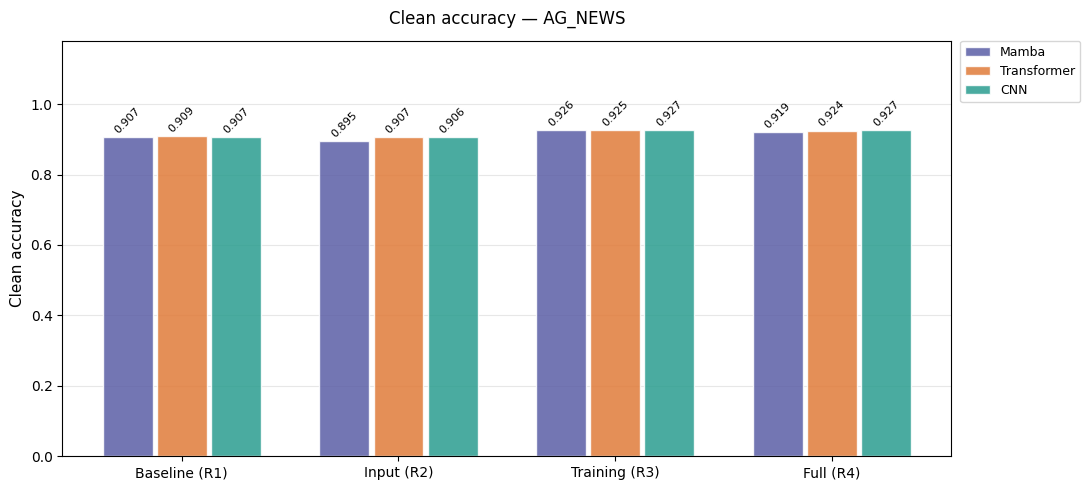

  Сохранено: /kaggle/working/plots/ag-news/2_adv_accuracy.png


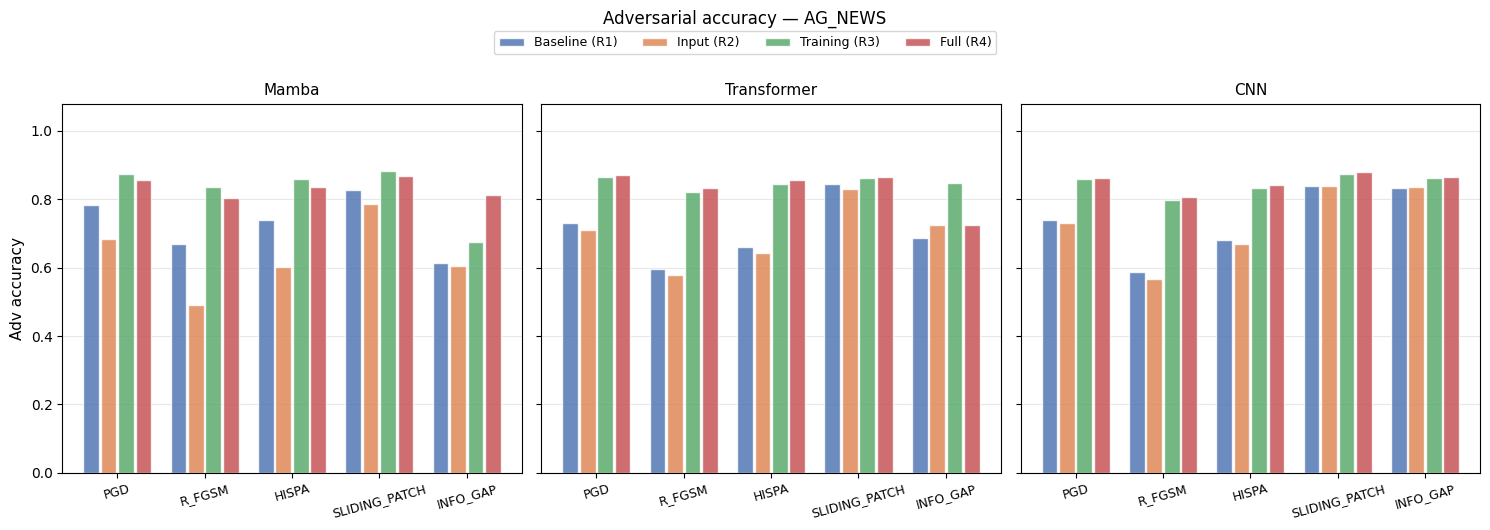

  Сохранено: /kaggle/working/plots/ag-news/3_training_curves.png


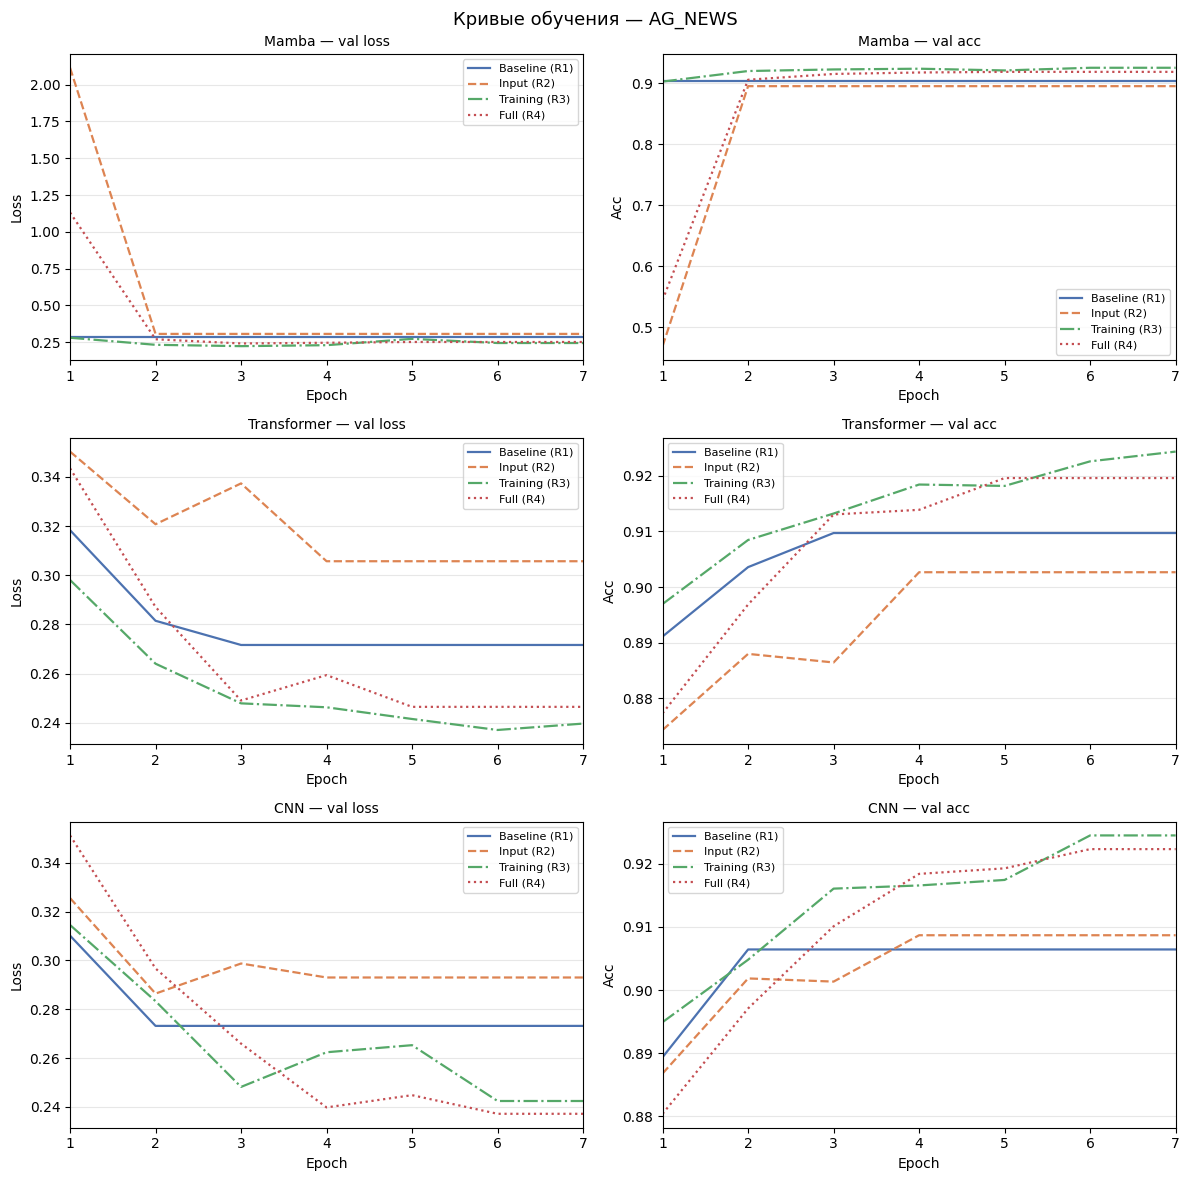

  Сохранено: /kaggle/working/plots/ag-news/4_robustness_gap.png


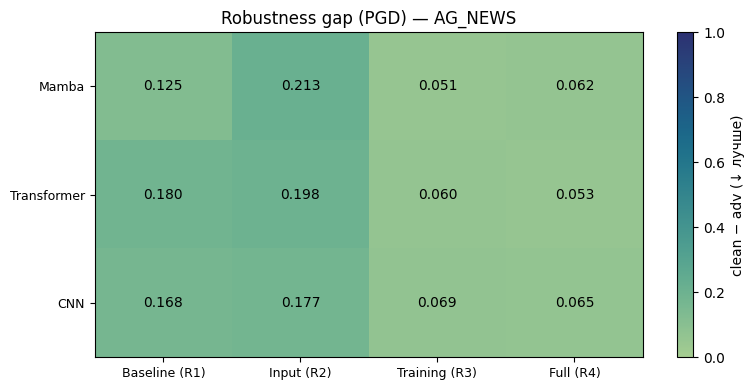

  Сохранено: /kaggle/working/plots/ag-news/5_state_drift.png


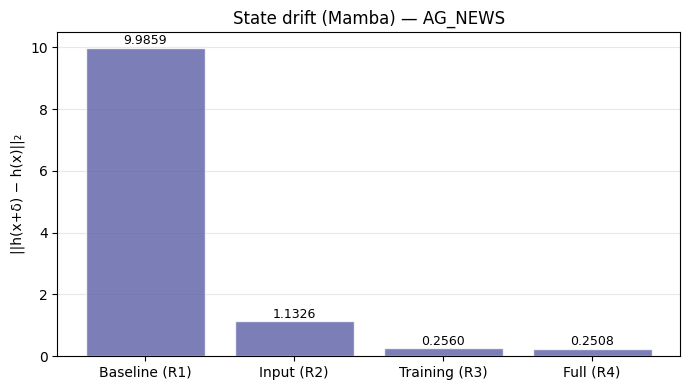

  Сохранено: /kaggle/working/plots/ag-news/table_ag_news.csv
  Сохранено: /kaggle/working/plots/ag-news/table_ag_news.png


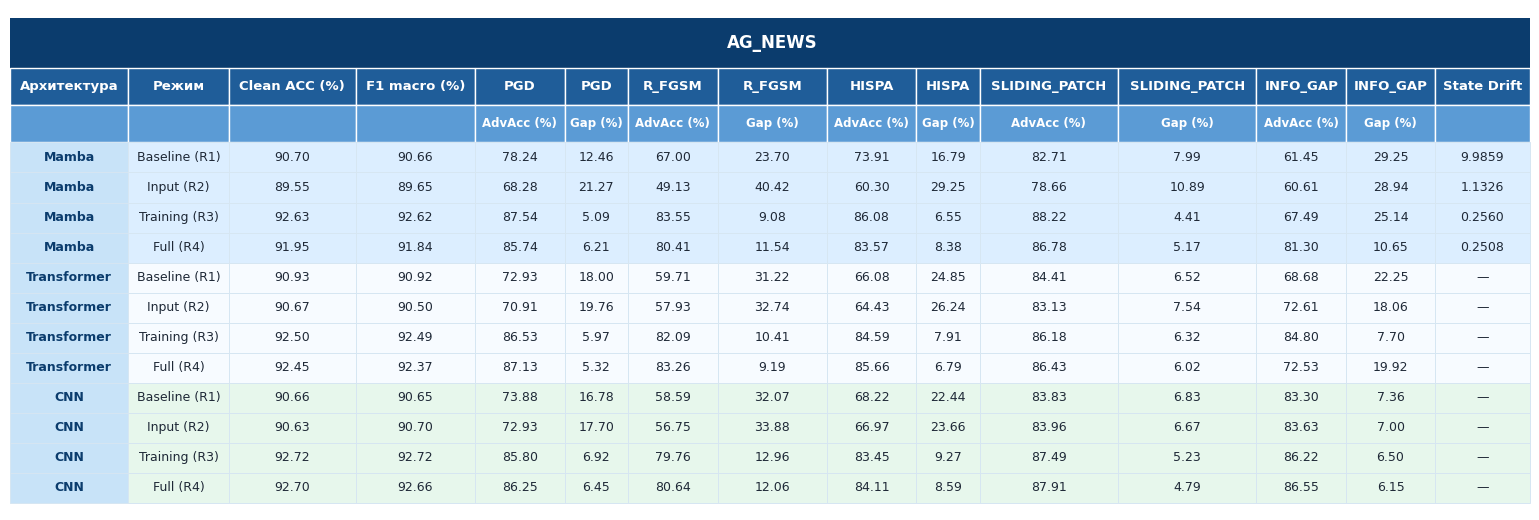

In [84]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import zipfile
from pathlib import Path
from IPython.display import FileLink, display

RESULTS_FOLDER = '/kaggle/input/datasets/ekaterinatol/ag-news-res'
SAVE_DIR       = '/kaggle/working/plots/ag-news'

Path(SAVE_DIR).mkdir(parents=True, exist_ok=True)

REGIME_ORDER  = ['baseline', 'input', 'training', 'full']
ARCH_ORDER    = ['mamba', 'transformer', 'cnn']
REGIME_LABELS = {'baseline': 'Baseline (R1)', 'input': 'Input (R2)',
                 'training': 'Training (R3)', 'full': 'Full (R4)'}
ARCH_LABELS   = {'mamba': 'Mamba', 'transformer': 'Transformer', 'cnn': 'CNN'}
ARCH_COLORS   = {'mamba': '#5B5EA6', 'transformer': '#E07B39', 'cnn': '#2A9D8F'}
REGIME_COLORS = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
REGIME_STYLES = {'baseline': ('-', '#4C72B0'), 'input': ('--', '#DD8452'),
                 'training': ('-.', '#55A868'), 'full': (':', '#C44E52')}

def save(fig, name):
    path = f'{SAVE_DIR}/{name}.png'
    fig.savefig(path, dpi=150, bbox_inches='tight')
    print(f'  Сохранено: {path}')

root    = Path(RESULTS_FOLDER)
dataset = root.name.replace('-', '_').replace('_res', '').upper()
results = {}

for regime in REGIME_ORDER:
    p = root / regime
    if not p.exists():
        continue
    results[regime] = {}
    for f in p.glob('*.pt'):
        arch = next((a for a in ARCH_ORDER if f.stem.lower().startswith(a)), None)
        if arch is None:
            continue
        try:
            ckpt = torch.load(f, map_location='cpu')
            s = ckpt.get('training_summary', {})
            s['_history'] = ckpt.get('history', {})
            results[regime][arch] = s
            print(f'  ✓ {regime}/{f.name}')
        except Exception as e:
            print(f'  ✗ {f.name}: {e}')

regimes = [r for r in REGIME_ORDER if r in results]
print(f'\nЗагружено режимов: {regimes}')

if not regimes:
    raise RuntimeError(f'Не найдено данных в {root.resolve()}')

def tr(regime, arch):
    return results.get(regime, {}).get(arch, {}).get('test_results', {})

attacks = []
for r in regimes:
    for a in ARCH_ORDER:
        t = tr(r, a)
        candidate = [k for k in t if k not in ('clean', 'state_drift')]
        if candidate:
            attacks = candidate
            break
    if attacks:
        break
print(f'Атаки: {attacks}')

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(regimes))
w = 0.25
for i, arch in enumerate(ARCH_ORDER):
    vals = [tr(r, arch).get('clean', np.nan) for r in regimes]
    bars = ax.bar(x + (i - 1) * w, vals, w - 0.02,
                  label=ARCH_LABELS[arch], color=ARCH_COLORS[arch],
                  alpha=0.85, edgecolor='white')
    for b, v in zip(bars, vals):
        if not np.isnan(v):
            ax.text(b.get_x() + b.get_width() / 2, v + 0.005,
                    f'{v:.3f}', ha='center', va='bottom', fontsize=8, rotation=45)
ax.set_xticks(x)
ax.set_xticklabels([REGIME_LABELS[r] for r in regimes], fontsize=10)
ax.set_ylim(0, 1.18)
ax.set_ylabel('Clean accuracy', fontsize=11)
ax.set_title(f'Clean accuracy — {dataset}', fontsize=12, pad=12)
ax.legend(fontsize=9, loc='upper left', bbox_to_anchor=(1.01, 1),
          borderaxespad=0, frameon=True)
ax.yaxis.grid(True, alpha=0.3)
ax.set_axisbelow(True)
plt.tight_layout()
save(fig, '1_clean_accuracy')
plt.show()

if not attacks:
    print('⚠ Атаки не найдены — пропускаем график 2')
else:
    fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
    x = np.arange(len(attacks))
    w = 0.8 / len(regimes)
    for ax, arch in zip(axes, ARCH_ORDER):
        for j, regime in enumerate(regimes):
            vals = [tr(regime, arch).get(atk, np.nan) for atk in attacks]
            offset = (j - len(regimes) / 2 + 0.5) * w
            ax.bar(x + offset, vals, w - 0.02,
                   label=REGIME_LABELS[regime], color=REGIME_COLORS[j],
                   alpha=0.82, edgecolor='white')
        ax.set_title(ARCH_LABELS[arch], fontsize=11)
        ax.set_xticks(x)
        ax.set_xticklabels([a.upper() for a in attacks], rotation=15, fontsize=9)
        ax.set_ylim(0, 1.08)
        ax.yaxis.grid(True, alpha=0.3)
        ax.set_axisbelow(True)
        if ax == axes[0]:
            ax.set_ylabel('Adv accuracy', fontsize=11)
    handles, labels = axes[-1].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', ncol=len(regimes),
               bbox_to_anchor=(0.5, 1.02), fontsize=9)
    fig.suptitle(f'Adversarial accuracy — {dataset}', fontsize=12, y=1.05)
    plt.tight_layout()
    save(fig, '2_adv_accuracy')
    plt.show()

fig, axes = plt.subplots(3, 2, figsize=(12, 12))

max_epochs = 1
for regime in regimes:
    for arch in ARCH_ORDER:
        hist = results[regime].get(arch, {}).get('_history', {})
        for metric in ['val_loss', 'val_acc']:
            if hist.get(metric):
                max_epochs = max(max_epochs, len(hist[metric]))

for row, arch in enumerate(ARCH_ORDER):
    for col, metric in enumerate(['val_loss', 'val_acc']):
        ax = axes[row, col]
        for regime in regimes:
            hist = results[regime].get(arch, {}).get('_history', {})
            if not hist.get(metric):
                continue
            vals = hist[metric]
            if len(vals) < max_epochs:
                vals = vals + [vals[-1]] * (max_epochs - len(vals))
            ls, color = REGIME_STYLES[regime]
            ax.plot(range(1, max_epochs + 1), vals,
                    ls=ls, color=color, label=REGIME_LABELS[regime], lw=1.6)
        ax.set_title(f'{ARCH_LABELS[arch]} — {metric.replace("_", " ")}', fontsize=10)
        ax.set_xlabel('Epoch')
        ax.set_ylabel(metric.split('_')[1].capitalize())
        ax.set_xlim(1, max_epochs)
        ax.legend(fontsize=8)
        ax.yaxis.grid(True, alpha=0.3)
        ax.set_axisbelow(True)

fig.suptitle(f'Кривые обучения — {dataset}', fontsize=13)
plt.tight_layout()
save(fig, '3_training_curves')
plt.show()

primary = attacks[0] if attacks else None
if primary:
    matrix = np.full((3, len(regimes)), np.nan)
    for j, regime in enumerate(regimes):
        for i, arch in enumerate(ARCH_ORDER):
            t = tr(regime, arch)
            c, a = t.get('clean', np.nan), t.get(primary, np.nan)
            if not (np.isnan(c) or np.isnan(a)):
                matrix[i, j] = c - a
    fig, ax = plt.subplots(figsize=(8, 4))
    im = ax.imshow(matrix, cmap='crest', vmin=0, vmax=1, aspect='auto')
    ax.set_xticks(range(len(regimes)))
    ax.set_yticks(range(3))
    ax.set_xticklabels([REGIME_LABELS[r] for r in regimes], fontsize=9)
    ax.set_yticklabels([ARCH_LABELS[a] for a in ARCH_ORDER], fontsize=9)
    for i in range(3):
        for j in range(len(regimes)):
            v = matrix[i, j]
            if not np.isnan(v):
                ax.text(j, i, f'{v:.3f}', ha='center', va='center', fontsize=10)
    plt.colorbar(im, ax=ax, label='clean − adv (↓ лучше)')
    ax.set_title(f'Robustness gap ({primary.upper()}) — {dataset}', fontsize=12)
    plt.tight_layout()
    save(fig, '4_robustness_gap')
    plt.show()

drifts = [(REGIME_LABELS[r], tr(r, 'mamba').get('state_drift'))
          for r in regimes if tr(r, 'mamba').get('state_drift') is not None]
if drifts:
    labs, vals = zip(*drifts)
    fig, ax = plt.subplots(figsize=(7, 4))
    bars = ax.bar(labs, vals, color='#5B5EA6', alpha=0.8, edgecolor='white')
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width() / 2, v + 0.01,
                f'{v:.4f}', ha='center', va='bottom', fontsize=9)
    ax.set_ylabel('||h(x+δ) − h(x)||₂', fontsize=10)
    ax.set_title(f'State drift (Mamba) — {dataset}', fontsize=12)
    ax.yaxis.grid(True, alpha=0.3)
    ax.set_axisbelow(True)
    plt.tight_layout()
    save(fig, '5_state_drift')
    plt.show()
else:
    print('State drift не найден')

import json

with open('/kaggle/working/f1_results.json') as f:
    f1_data = json.load(f)

rows = []
for arch in ARCH_ORDER:
    for regime in REGIME_ORDER:
        if regime not in results or arch not in results[regime]:
            continue
        t = tr(regime, arch)
        if not t:
            continue
        clean   = t.get('clean', np.nan)
        ds_lower = dataset.lower()

        f1_val = f1_data.get(ds_lower, {}).get(regime, {}).get(arch, None)
        f1_str = f'{f1_val * 100:.2f}' if f1_val is not None else '—'

        row = {
            ('', 'Архитектура'):   ARCH_LABELS[arch],
            ('', 'Режим'):         REGIME_LABELS[regime],
            ('', 'Clean ACC (%)'): f'{clean * 100:.2f}' if not np.isnan(clean) else '—',
            ('', 'F1 macro (%)'):  f1_str,
        }
        for atk in attacks:
            adv = t.get(atk, np.nan)
            gap = (clean - adv) if (not np.isnan(clean) and not np.isnan(adv)) else np.nan
            row[(atk.upper(), 'AdvAcc (%)')] = f'{adv * 100:.2f}' if not np.isnan(adv) else '—'
            row[(atk.upper(), 'Gap (%)')]    = f'{gap * 100:.2f}' if not np.isnan(gap) else '—'
        sd = t.get('state_drift', None)
        row[('', 'State Drift')] = f'{sd:.4f}' if sd is not None else '—'
        rows.append(row)

col_tuples = (
    [('', 'Архитектура'), ('', 'Режим'), ('', 'Clean ACC (%)'), ('', 'F1 macro (%)')] +
    [(atk.upper(), sub) for atk in attacks for sub in ['AdvAcc (%)', 'Gap (%)']] +
    [('', 'State Drift')]
)
df = pd.DataFrame(rows, columns=pd.MultiIndex.from_tuples(col_tuples))

styled = (
    df.style
    .set_caption(f'Сводная таблица результатов — {dataset}')
    .set_table_styles([
        {'selector': 'caption',
         'props': [('font-size', '14px'), ('font-weight', 'bold'), ('padding', '8px 0')]},
        {'selector': 'th',
         'props': [('background-color', '#e8f4fb'), ('font-size', '11px'),
                   ('text-align', 'center'), ('padding', '4px 8px'),
                   ('border', '1px solid #ddd')]},
        {'selector': 'td',
         'props': [('font-size', '11px'), ('text-align', 'center'),
                   ('padding', '3px 8px'), ('border', '1px solid #eee')]},
    ])
    .hide(axis='index')
)
display(styled)

csv_path = f'{SAVE_DIR}/table_{dataset.lower()}.csv'
df.to_csv(csv_path)
print(f'  Сохранено: {csv_path}')

n_cols = len(col_tuples)
n_rows = len(rows)


C_TITLE   = "#0B3C6D"

C_HEADER0 = "#1F5D99"
C_HEADER1 = "#5B9BD5"

C_TEXT    = "#1F2937"
C_GRID    = "#D6E6F2"

C_MAMBA   = "#DCEEFF"
C_TRANS   = "#F7FBFF"
C_CNN     = "#E7F7EC"

C_ARCHCOL = "#C8E3F8"
C_ALT     = "#F8FBFE"

arch_colors_bg = {
    "Mamba": C_MAMBA,
    "Transformer": C_TRANS,
    "CNN": C_CNN,
}

DPI = 300

PAGE_W_IN = 12.5
ROW_H_IN = 0.32

n_total_rows = n_rows + 3

fig_h_in = max(
    4.5,
    n_total_rows * ROW_H_IN + 0.5
)

fig, ax = plt.subplots(
    figsize=(PAGE_W_IN, fig_h_in)
)

ax.axis("off")
fig.patch.set_facecolor("white")


header1 = []
header2 = []

for lvl0, lvl1 in col_tuples:
    header1.append(lvl0 if lvl0 else lvl1)
    header2.append(lvl1 if lvl0 else "")

title_row = [""] * n_cols
title_row[n_cols // 2] = dataset.upper()

cell_text = (
    [title_row] +
    [header1] +
    [header2] +
    [list(r.values()) for r in rows]
)


tbl = ax.table(
    cellText=cell_text,
    cellLoc="center",
    loc="center"
)

tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.auto_set_column_width(col=list(range(n_cols)))

TITLE_H = 0.10
HEADER_H = 0.075
DATA_H = 0.060

for j in range(n_cols):

    tbl[0, j].set_height(TITLE_H)
    tbl[1, j].set_height(HEADER_H)
    tbl[2, j].set_height(HEADER_H)

    for i in range(n_rows):
        tbl[i + 3, j].set_height(DATA_H)


for j in range(n_cols):

    cell = tbl[0, j]

    cell.set_facecolor(C_TITLE)
    cell.set_edgecolor(C_TITLE)
    cell.set_linewidth(0)

    if j == n_cols // 2:
        cell.set_text_props(
            color="white",
            fontsize=12,
            fontweight="bold"
        )
    else:
        cell.get_text().set_text("")


for j in range(n_cols):

    cell = tbl[1, j]

    cell.set_facecolor(C_HEADER0)
    cell.set_edgecolor("white")
    cell.set_linewidth(1.0)

    cell.set_text_props(
        color="white",
        fontsize=9.5,
        fontweight="bold"
    )

for j in range(n_cols):

    cell = tbl[2, j]

    cell.set_facecolor(C_HEADER1)
    cell.set_edgecolor("white")
    cell.set_linewidth(1.0)

    cell.set_text_props(
        color="white",
        fontsize=8.5,
        fontweight="bold"
    )


for i, row in enumerate(rows):

    arch = row[('', 'Архитектура')]

    bg = arch_colors_bg.get(
        arch,
        C_ALT
    )

    for j in range(n_cols):

        cell = tbl[i + 3, j]

        cell.set_facecolor(bg)
        cell.set_edgecolor(C_GRID)
        cell.set_linewidth(0.7)

        cell.set_text_props(
            color=C_TEXT,
            fontsize=9
        )


for i in range(n_rows):

    cell = tbl[i + 3, 0]

    cell.set_facecolor(C_ARCHCOL)

    cell.set_text_props(
        color="#0B3C6D",
        fontsize=9,
        fontweight="bold"
    )


for i, row in enumerate(rows):

    for j, value in enumerate(row.values()):

        txt = str(value)

        if "*" in txt:

            cell = tbl[i + 3, j]

            cell.set_text_props(
                fontweight="bold",
                color="#0B3C6D"
            )


plt.tight_layout()

png_path = f"{SAVE_DIR}/table_{dataset.lower()}.png"

fig.savefig(
    png_path,
    dpi=DPI,
    bbox_inches="tight",
    pad_inches=0.05,
    facecolor="white"
)

print(f"  Сохранено: {png_path}")

plt.show()
plt.close()

In [85]:
import shutil

zip_path = shutil.make_archive("/kaggle/working/plots_archive", "zip", "/kaggle/working/plots")
print(zip_path)

/kaggle/working/plots_archive.zip


Загружено: ['mnist', 'smnist', 'cifar10', 'imdb', 'ag_news', 'speech_commands']
  Сохранено: /kaggle/working/plots/thesis/fig_state_drift.png


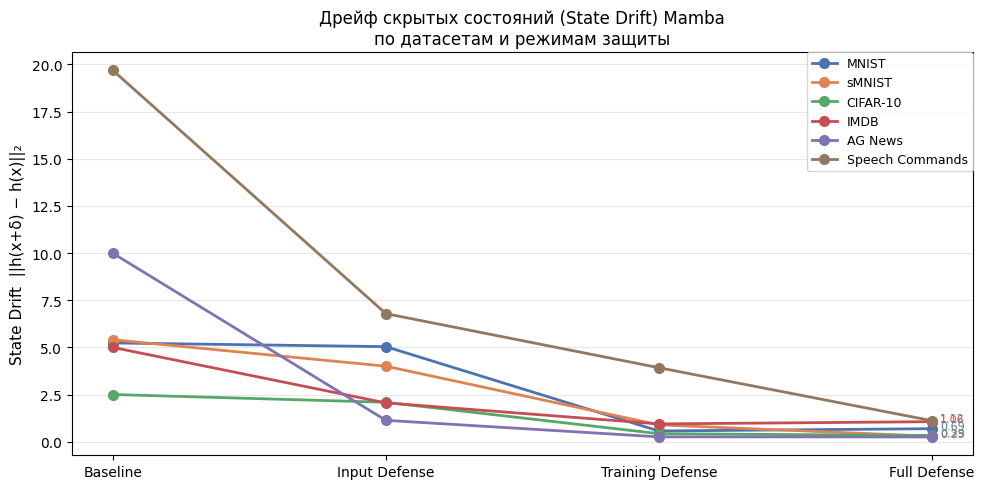

  Сохранено: /kaggle/working/plots/thesis/fig_robustness_gap.png


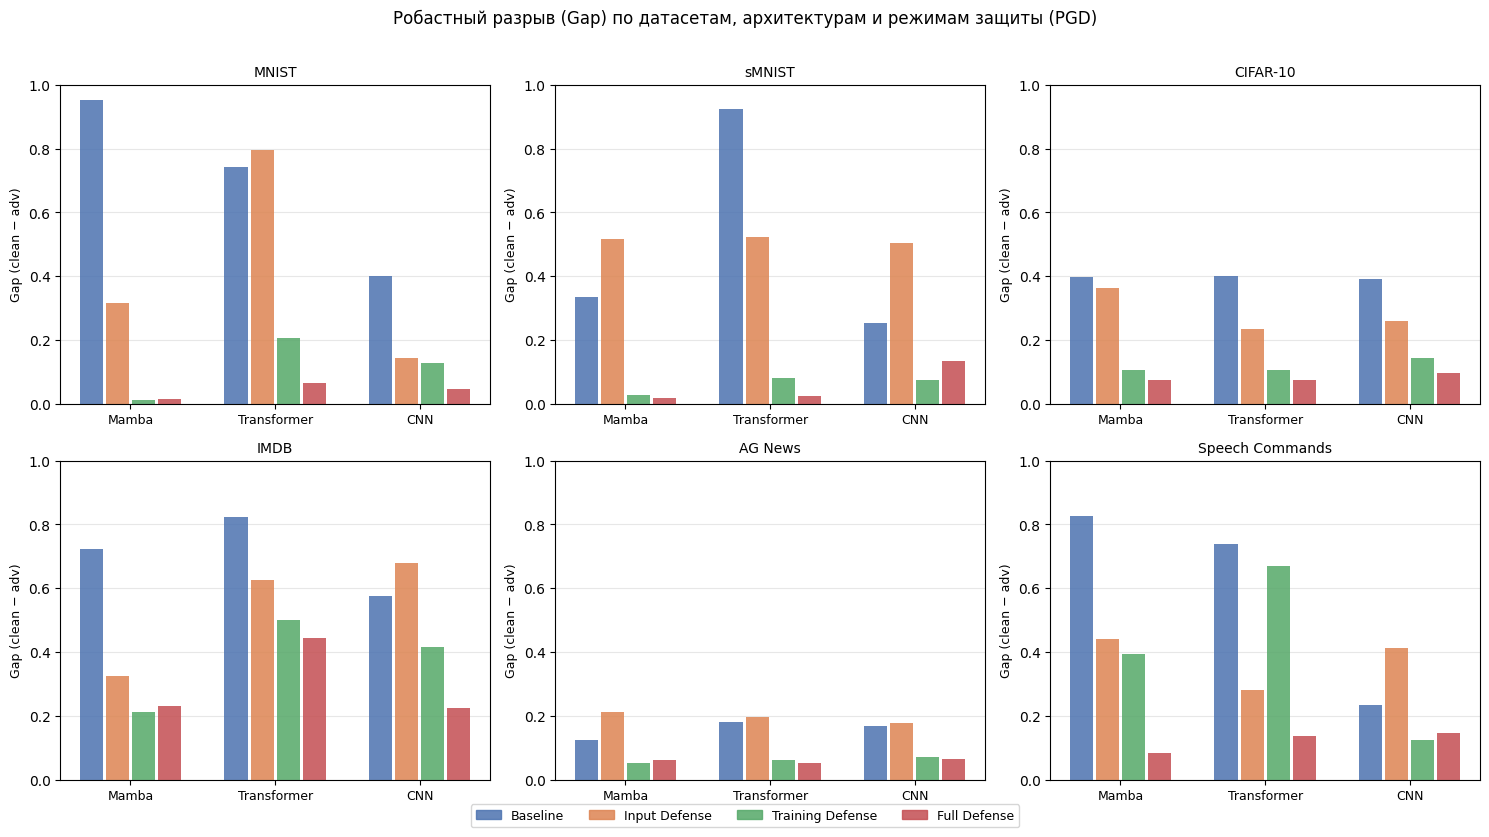

  Сохранено: /kaggle/working/plots/thesis/fig_training_curves.png


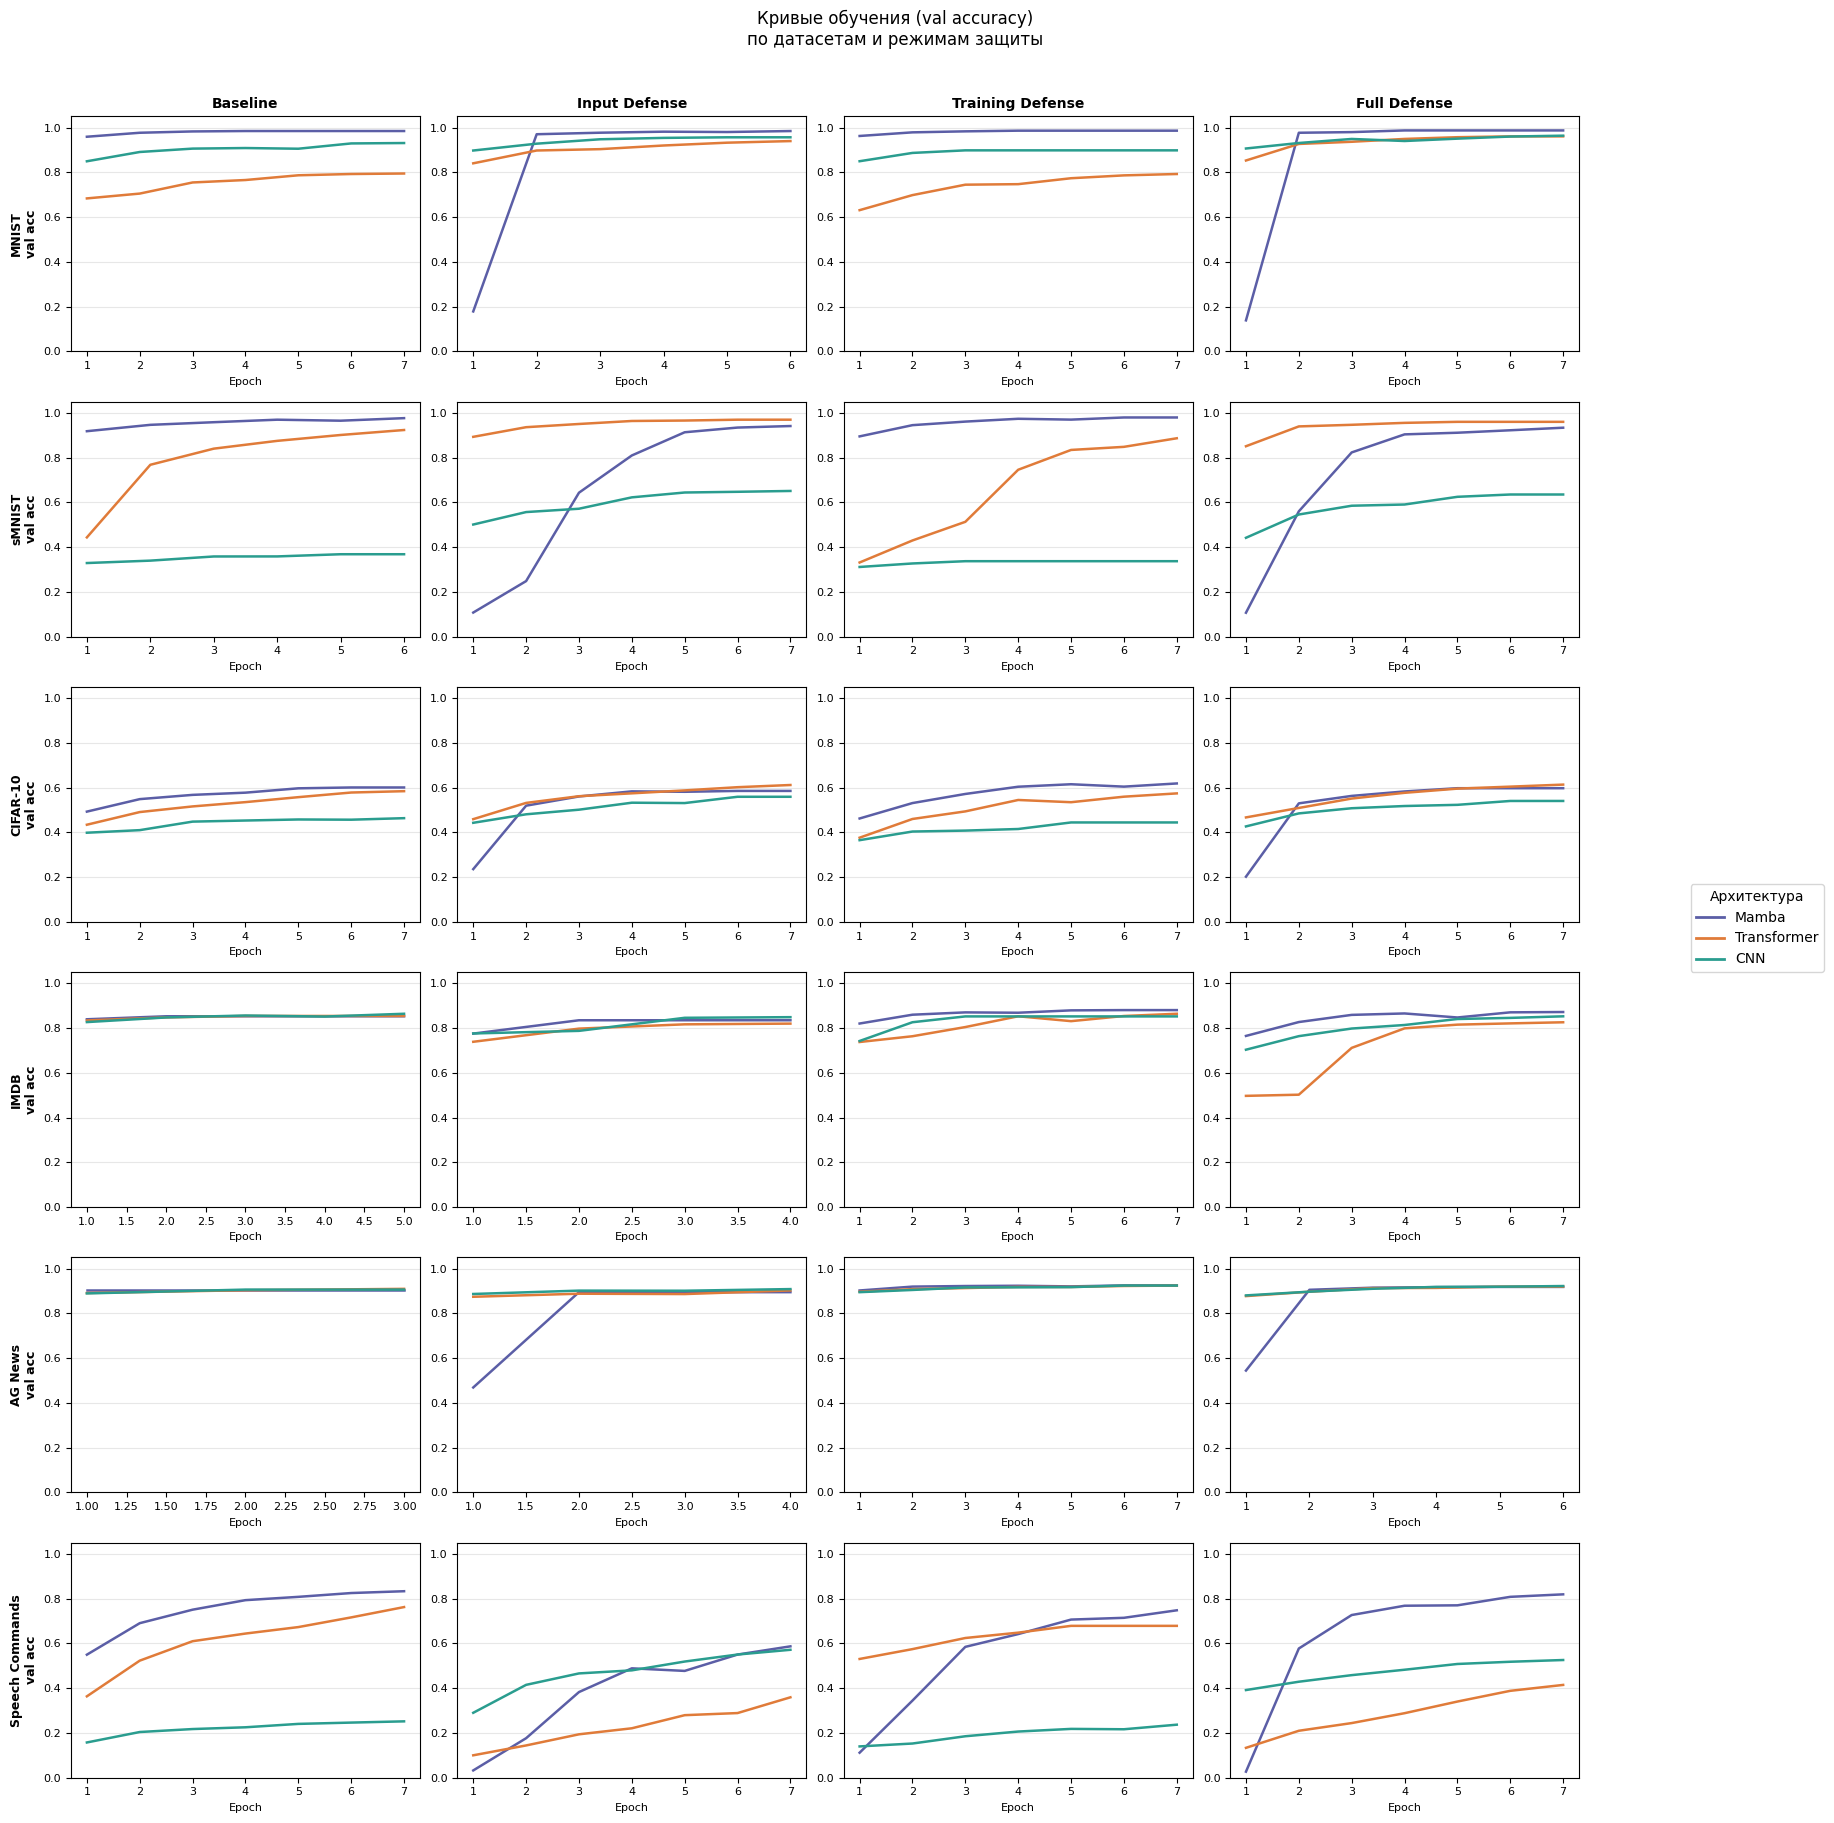

  Сохранено: /kaggle/working/plots/thesis/fig_training_time.png


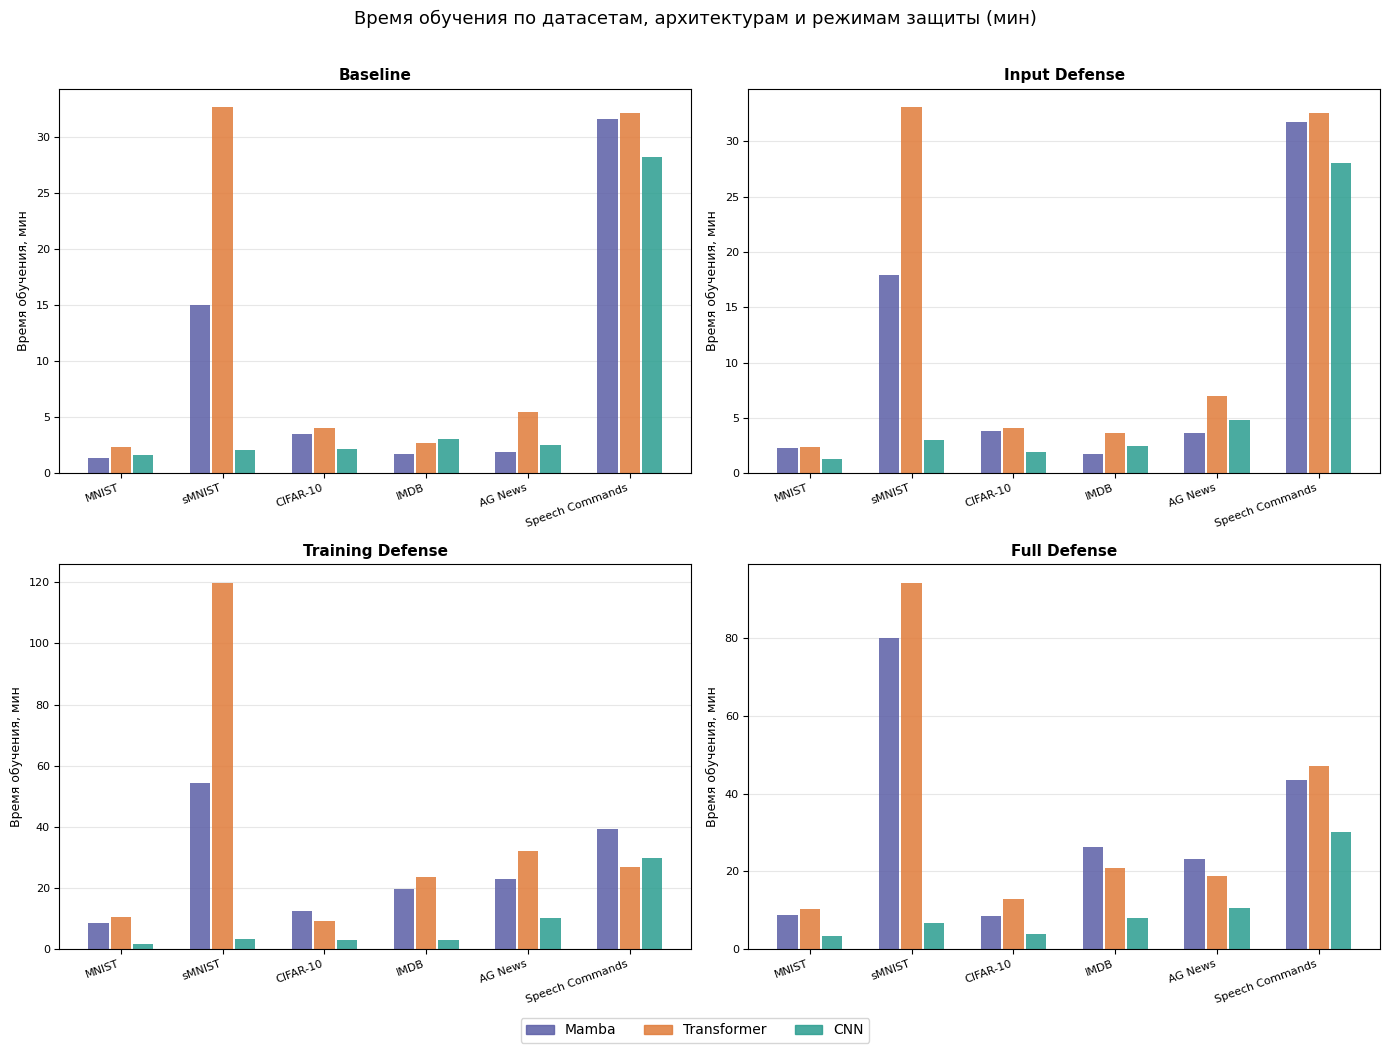

Архив:


/kaggle/working/thesis_figures.zip

In [29]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import zipfile
from pathlib import Path
from IPython.display import FileLink

DATASETS_ROOT = '/kaggle/input/datasets/dmitrytolstov'
SAVE_DIR      = '/kaggle/working/plots/thesis'
Path(SAVE_DIR).mkdir(parents=True, exist_ok=True)

REGIME_ORDER  = ['baseline', 'input', 'training', 'full']
ARCH_ORDER    = ['mamba', 'transformer', 'cnn']
REGIME_LABELS = {'baseline': 'Baseline', 'input': 'Input Defense',
                 'training': 'Training Defense', 'full': 'Full Defense'}
ARCH_LABELS   = {'mamba': 'Mamba', 'transformer': 'Transformer', 'cnn': 'CNN'}
ARCH_COLORS   = {'mamba': '#5B5EA6', 'transformer': '#E07B39', 'cnn': '#2A9D8F'}
DS_ORDER  = ['mnist', 'smnist', 'cifar10', 'imdb', 'ag_news', 'speech_commands']
DS_LABELS = {'mnist': 'MNIST', 'smnist': 'sMNIST', 'cifar10': 'CIFAR-10',
             'imdb': 'IMDB', 'ag_news': 'AG News', 'speech_commands': 'Speech Commands'}
DS_COLORS = {'mnist': '#4C72B0', 'smnist': '#DD8452', 'cifar10': '#55A868',
             'imdb': '#C44E52', 'ag_news': '#8172B2', 'speech_commands': '#937860'}
REGIME_COLORS = {'baseline': '#4C72B0', 'input': '#DD8452',
                 'training': '#55A868', 'full': '#C44E52'}

def save(fig, name):
    path = f'{SAVE_DIR}/{name}.png'
    fig.savefig(path, dpi=150, bbox_inches='tight')
    print(f'  Сохранено: {path}')

all_data = {}
for ds_folder in Path(DATASETS_ROOT).iterdir():
    if not ds_folder.is_dir():
        continue
    ds_name = ds_folder.name.replace('-res', '').replace('-', '_')
    all_data[ds_name] = {}
    for regime in REGIME_ORDER:
        regime_path = ds_folder / regime
        if not regime_path.exists():
            continue
        all_data[ds_name][regime] = {}
        for pt in regime_path.glob('*.pt'):
            arch = next((a for a in ARCH_ORDER if pt.stem.lower().startswith(a)), None)
            if arch is None:
                continue
            try:
                ckpt = torch.load(pt, map_location='cpu')
                s = ckpt.get('training_summary', {})
                s['_history'] = ckpt.get('history', {})
                all_data[ds_name][regime][arch] = s
            except:
                pass

print('Загружено:', [d for d in DS_ORDER if d in all_data])

def get_tr(ds, regime, arch):
    return all_data.get(ds, {}).get(regime, {}).get(arch, {}).get('test_results', {})

attacks = []
for ds in DS_ORDER:
    for regime in REGIME_ORDER:
        for arch in ARCH_ORDER:
            t = get_tr(ds, regime, arch)
            cand = [k for k in t if k not in ('clean', 'state_drift')]
            if cand:
                attacks = cand
                break
        if attacks: break
    if attacks: break
primary_attack = attacks[0] if attacks else 'pgd'

datasets_present = [d for d in DS_ORDER if d in all_data]

fig, ax = plt.subplots(figsize=(10, 5))

for ds in datasets_present:
    vals, x_idx = [], []
    for i, regime in enumerate(REGIME_ORDER):
        sd = get_tr(ds, regime, 'mamba').get('state_drift', None)
        if sd is not None:
            vals.append(sd)
            x_idx.append(i)
    if len(vals) >= 2:
        ax.plot(x_idx, vals, marker='o', linewidth=2, markersize=7,
                color=DS_COLORS.get(ds, 'gray'), label=DS_LABELS.get(ds, ds))
        ax.annotate(f'{vals[-1]:.2f}', (x_idx[-1], vals[-1]),
                    textcoords='offset points', xytext=(6, 0),
                    fontsize=8, color=DS_COLORS.get(ds, 'gray'))

ax.set_xticks(range(len(REGIME_ORDER)))
ax.set_xticklabels([REGIME_LABELS[r] for r in REGIME_ORDER], fontsize=10)
ax.set_ylabel('State Drift  ||h(x+δ) − h(x)||₂', fontsize=11)
ax.set_title('Дрейф скрытых состояний (State Drift) Mamba\n'
             'по датасетам и режимам защиты', fontsize=12)
ax.legend(fontsize=9, loc='upper right', borderaxespad=0)
ax.yaxis.grid(True, alpha=0.3)
ax.set_axisbelow(True)
plt.tight_layout()
save(fig, 'fig_state_drift')
plt.show()

n_cols = 3
n_rows = (len(datasets_present) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols,
                          figsize=(5 * n_cols, 4 * n_rows), sharey=False)
axes = axes.flatten()
w = 0.18
x = np.arange(len(ARCH_ORDER))

for plot_idx, ds in enumerate(datasets_present):
    ax = axes[plot_idx]
    for j, regime in enumerate(REGIME_ORDER):
        vals = []
        for arch in ARCH_ORDER:
            t = get_tr(ds, regime, arch)
            clean = t.get('clean', np.nan)
            adv   = t.get(primary_attack, np.nan)
            gap   = clean - adv if not (np.isnan(clean) or np.isnan(adv)) else np.nan
            vals.append(gap)
        offset = (j - len(REGIME_ORDER) / 2 + 0.5) * w
        ax.bar(x + offset, vals, w - 0.02,
               label=REGIME_LABELS[regime],
               color=REGIME_COLORS[regime], alpha=0.85)
    ax.set_title(DS_LABELS.get(ds, ds), fontsize=10)
    ax.set_xticks(x)
    ax.set_xticklabels([ARCH_LABELS[a] for a in ARCH_ORDER], fontsize=9)
    ax.set_ylim(0, 1)
    ax.set_ylabel('Gap (clean − adv)', fontsize=9)
    ax.yaxis.grid(True, alpha=0.3)
    ax.set_axisbelow(True)

for i in range(len(datasets_present), len(axes)):
    axes[i].set_visible(False)

handles = [plt.Rectangle((0, 0), 1, 1, color=REGIME_COLORS[r], alpha=0.85)
           for r in REGIME_ORDER]
fig.legend(handles, [REGIME_LABELS[r] for r in REGIME_ORDER],
           loc='lower center', ncol=4, fontsize=9, bbox_to_anchor=(0.5, -0.02))
fig.suptitle(f'Робастный разрыв (Gap) по датасетам, архитектурам '
             f'и режимам защиты ({primary_attack.upper()})',
             fontsize=12, y=1.01)
plt.tight_layout()
save(fig, 'fig_robustness_gap')
plt.show()

n_rows = len(datasets_present)
n_cols = len(REGIME_ORDER)
fig, axes = plt.subplots(n_rows, n_cols,
                          figsize=(4.5 * n_cols, 3 * n_rows), sharey=False)

for row, ds in enumerate(datasets_present):
    for col, regime in enumerate(REGIME_ORDER):
        ax = axes[row, col]

        max_ep = 1
        for arch in ARCH_ORDER:
            h = all_data[ds].get(regime, {}).get(arch, {}).get('_history', {})
            if h.get('val_acc'):
                max_ep = max(max_ep, len(h['val_acc']))

        for arch in ARCH_ORDER:
            h = all_data[ds].get(regime, {}).get(arch, {}).get('_history', {})
            if not h.get('val_acc'):
                continue
            vals = h['val_acc']
            if len(vals) < max_ep:
                vals = vals + [vals[-1]] * (max_ep - len(vals))
            ax.plot(range(1, max_ep + 1), vals,
                    color=ARCH_COLORS[arch], linewidth=1.8,
                    label=ARCH_LABELS[arch])

        if row == 0:
            ax.set_title(REGIME_LABELS[regime], fontsize=10, fontweight='bold', pad=6)
        if col == 0:
            ax.set_ylabel(DS_LABELS.get(ds, ds) + '\nval acc', fontsize=9, fontweight='bold')
        ax.set_xlabel('Epoch', fontsize=8)
        ax.set_ylim(0, 1.05)
        ax.yaxis.grid(True, alpha=0.3)
        ax.set_axisbelow(True)
        ax.tick_params(labelsize=8)

legend_handles = [
    mlines.Line2D([], [], color=ARCH_COLORS[arch], linewidth=2,
                  label=ARCH_LABELS[arch])
    for arch in ARCH_ORDER
]
fig.legend(handles=legend_handles, loc='center right',
           bbox_to_anchor=(1.02, 0.5), fontsize=10,
           frameon=True, title='Архитектура', title_fontsize=10)
fig.suptitle('Кривые обучения (val accuracy)\nпо датасетам и режимам защиты',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.subplots_adjust(right=0.88)
save(fig, 'fig_training_curves')
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharey=False)
axes = axes.flatten()

w = 0.22
x = np.arange(len(datasets_present))

for idx, regime in enumerate(REGIME_ORDER):
    ax = axes[idx]

    for j, arch in enumerate(ARCH_ORDER):
        vals = []
        for ds in datasets_present:
            summary = all_data.get(ds, {}).get(regime, {}).get(arch, {})
            t = summary.get('training_time_sec', None)
            vals.append(t / 60 if t is not None else np.nan)

        offset = (j - len(ARCH_ORDER) / 2 + 0.5) * w
        ax.bar(x + offset, vals, w - 0.02,
               label=ARCH_LABELS[arch],
               color=ARCH_COLORS[arch], alpha=0.85)

    ax.set_title(REGIME_LABELS[regime], fontsize=11, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels([DS_LABELS.get(d, d) for d in datasets_present],
                        fontsize=9, rotation=20, ha='right')
    ax.set_ylabel('Время обучения, мин', fontsize=9)
    ax.yaxis.grid(True, alpha=0.3)
    ax.set_axisbelow(True)
    ax.tick_params(labelsize=8)

handles = [plt.Rectangle((0, 0), 1, 1, color=ARCH_COLORS[a], alpha=0.85)
           for a in ARCH_ORDER]
fig.legend(handles, [ARCH_LABELS[a] for a in ARCH_ORDER],
           loc='lower center', ncol=3, fontsize=10,
           bbox_to_anchor=(0.5, -0.03))
fig.suptitle('Время обучения по датасетам, архитектурам и режимам защиты (мин)',
             fontsize=13, y=1.01)
plt.tight_layout()
save(fig, 'fig_training_time')
plt.show()
zip_path = '/kaggle/working/thesis_figures.zip'
with zipfile.ZipFile(zip_path, 'w') as zf:
    for f in Path(SAVE_DIR).glob('*.png'):
        zf.write(f, f.name)
print('Архив:')
FileLink(zip_path)

In [35]:
import json
import numpy as np
import pandas as pd
from openpyxl import Workbook
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils import get_column_letter
from pathlib import Path
from IPython.display import FileLink

XLSX_PATH = '/kaggle/working/results_all_datasets.xlsx'

with open('/kaggle/input/datasets/dmitrytolstov/f1-score/f1_results.json') as f:
    f1_data = json.load(f)

HDR1_FILL  = PatternFill('solid', start_color='4A90B8')
HDR2_FILL  = PatternFill('solid', start_color='7AB8C8')
ARCH_FILLS = {
    'Mamba':       PatternFill('solid', start_color='E8F4FB'),
    'Transformer': PatternFill('solid', start_color='E4F5F0'),
    'CNN':         PatternFill('solid', start_color='E8F5E8'),
}
WHITE_FONT  = Font(name='Arial', bold=True, color='FFFFFF', size=10)
BOLD_FONT   = Font(name='Arial', bold=True, size=10)
NORMAL_FONT = Font(name='Arial', size=10)
CENTER      = Alignment(horizontal='center', vertical='center', wrap_text=True)
thin        = Side(style='thin', color='CCCCCC')
BORDER      = Border(left=thin, right=thin, top=thin, bottom=thin)

REGIME_ORDER  = ['baseline', 'input', 'training', 'full']
ARCH_ORDER    = ['mamba', 'transformer', 'cnn']
REGIME_LABELS = {'baseline': 'Baseline (R1)', 'input': 'Input (R2)',
                 'training': 'Training (R3)', 'full': 'Full (R4)'}
ARCH_LABELS   = {'mamba': 'Mamba', 'transformer': 'Transformer', 'cnn': 'CNN'}
DS_LABELS     = {'mnist': 'MNIST', 'smnist': 'sMNIST', 'cifar10': 'CIFAR-10',
                 'imdb': 'IMDB', 'ag_news': 'AG News',
                 'speech_commands': 'Speech Commands'}
DS_ORDER = ['mnist', 'smnist', 'cifar10', 'imdb', 'ag_news', 'speech_commands']

def get_tr(ds, regime, arch):
    return all_data.get(ds, {}).get(regime, {}).get(arch, {}).get('test_results', {})

def fmt(v, pct=True):
    if v is None or (isinstance(v, float) and np.isnan(v)):
        return '—'
    return f'{v * 100:.2f}' if pct else f'{v:.4f}'

def get_attacks(ds):
    for regime in REGIME_ORDER:
        for arch in ARCH_ORDER:
            t = get_tr(ds, regime, arch)
            cand = [k for k in t if k not in ('clean', 'state_drift')]
            if cand:
                return cand
    return []

def build_rows(ds, attacks):
    rows = []
    for arch in ARCH_ORDER:
        for regime in REGIME_ORDER:
            if regime not in all_data.get(ds, {}):
                continue
            t = get_tr(ds, regime, arch)
            if not t:
                continue
            clean = t.get('clean', np.nan)
            f1    = f1_data.get(ds, {}).get(regime, {}).get(arch, None)
            row   = [ARCH_LABELS[arch], REGIME_LABELS[regime],
                     fmt(clean), fmt(f1)]
            for atk in attacks:
                adv = t.get(atk, np.nan)
                gap = clean - adv if not (np.isnan(clean) or np.isnan(adv)) else np.nan
                row += [fmt(adv), fmt(gap)]
            sd = t.get('state_drift', None)
            row.append(fmt(sd, pct=False) if sd is not None else '—')
            rows.append(row)
    return rows

def write_sheet(ws, ds):
    attacks  = get_attacks(ds)
    base_hdrs = ['Архитектура', 'Режим', 'Clean ACC (%)', 'F1 macro (%)']
    atk_hdrs  = [(atk.upper(), 'AdvAcc (%)', 'Gap (%)') for atk in attacks]

    ws['A1'] = DS_LABELS.get(ds, ds)
    ws['A1'].font      = Font(name='Arial', bold=True, size=13)
    ws['A1'].alignment = CENTER

    row1 = 3
    col  = 1
    for h in base_hdrs:
        c = ws.cell(row1, col, h)
        c.fill = HDR1_FILL; c.font = WHITE_FONT
        c.alignment = CENTER; c.border = BORDER
        ws.merge_cells(start_row=row1, start_column=col,
                       end_row=row1+1, end_column=col)
        col += 1

    for atk, a_lbl, g_lbl in atk_hdrs:
        c = ws.cell(row1, col, atk)
        c.fill = HDR1_FILL; c.font = WHITE_FONT
        c.alignment = CENTER; c.border = BORDER
        ws.merge_cells(start_row=row1, start_column=col,
                       end_row=row1, end_column=col+1)
        col += 2

    c = ws.cell(row1, col, 'State Drift')
    c.fill = HDR1_FILL; c.font = WHITE_FONT
    c.alignment = CENTER; c.border = BORDER
    ws.merge_cells(start_row=row1, start_column=col,
                   end_row=row1+1, end_column=col)

    row2 = row1 + 1
    col  = len(base_hdrs) + 1
    for atk, a_lbl, g_lbl in atk_hdrs:
        for lbl in [a_lbl, g_lbl]:
            c = ws.cell(row2, col, lbl)
            c.fill = HDR2_FILL; c.font = WHITE_FONT
            c.alignment = CENTER; c.border = BORDER
            col += 1

    for r in build_rows(ds, attacks):
        ws.append(r)
        rn   = ws.max_row
        arch = r[0]
        fill = ARCH_FILLS.get(arch, PatternFill())
        for c in range(1, len(r) + 1):
            cell = ws.cell(rn, c)
            cell.fill      = fill
            cell.font      = NORMAL_FONT
            cell.alignment = CENTER
            cell.border    = BORDER

    widths = [16, 18, 14, 14] + [13, 10] * len(attacks) + [12]
    for i, w in enumerate(widths, 1):
        ws.column_dimensions[get_column_letter(i)].width = w

    ws.row_dimensions[row1].height = 22
    ws.row_dimensions[row2].height = 22
    ws.freeze_panes = f'A{row2+1}'

wb = Workbook()
wb.remove(wb.active)

for ds in DS_ORDER:
    if ds not in all_data:
        continue
    ws = wb.create_sheet(title=DS_LABELS.get(ds, ds))
    write_sheet(ws, ds)

wb.save(XLSX_PATH)
print(f'✓ Сохранено: {XLSX_PATH}')
FileLink(XLSX_PATH)

✓ Сохранено: /kaggle/working/results_all_datasets.xlsx


/kaggle/working/results_all_datasets.xlsx